# Preparation for model error analysis

### Import necessary libraries

In [3]:
import os
# Set the environment variable
os.environ['STPSF_PATH'] = os.path.abspath("/npool/nvme/yuchialin/JWST/stpsf_data")
os.environ['WEBBPSF_EXT_PATH'] = "/npool/nvme/yuchialin/JWST/webbpsf_ext_data"
os.environ['PYSYN_CDBS'] = "/npool/nvme/yuchialin/JWST/webbpsf_ext_data/cdbs"
os.environ['CRDS_PATH'] = "/npool/nvme/yuchialin/JWST/crds_cache"
os.environ['CRDS_SERVER_URL'] = "https://jwst-crds.stsci.edu"

# Verify the variable is set
print("STPSF_PATH:", os.environ['STPSF_PATH'])
print("WEBBPSF_EXT_PATH:", os.environ['WEBBPSF_EXT_PATH'])
print("PYSYN_CDBS:", os.environ['PYSYN_CDBS'])
print("CRDS_PATH:", os.environ['CRDS_PATH'])

STPSF_PATH: /npool/nvme/yuchialin/JWST/stpsf_data
WEBBPSF_EXT_PATH: /npool/nvme/yuchialin/JWST/webbpsf_ext_data
PYSYN_CDBS: /npool/nvme/yuchialin/JWST/webbpsf_ext_data/cdbs
CRDS_PATH: /npool/nvme/yuchialin/JWST/crds_cache


In [4]:
# Imports
from IPython.display import display, HTML

def setup_display(width=95, fontsize=16):
    """
    Sets window width and markdown fontsize for Jupyter notebook. Width is % of window.
    """
    display(HTML("<style>.container { width:"+str(width)+"% !important; }</style>"))
    display(HTML("<style>.rendered_html { font-size: "+str(fontsize)+"px; }</style>"))
    return None

def source(fn):
    import inspect
    print(inspect.getsource(fn))
    return None

import numpy as np
import glob
import winnie
from winnie.plot import animate_quick_implot, quick_implot, mpl, plt
from spaceKLIP import database
import webbpsf
import astropy.units as u

plt.style.use('winnie.winnie_mplstyle') # Comment this out or replace it if you prefer a different plot style

setup_display()

### Import TW Hya properties

In [5]:
# Prep the SpaceRDI object:
#https://simbad.u-strasbg.fr/simbad/sim-basic?Ident=TW+Hya&submit=SIMBAD+search
#approximately 16.63 milliarcseconds (mas)
#Distance (parsecs) = 1000 / 16.63 ≈ 60.14 parsecs
distance = 60.14 # Distance to your target in parsecs

base_dir = 'data_twhya_winnie/'
input_dir = f'{base_dir}padded/'
data_ext = 'calints'
fitsfiles = np.sort(glob.glob(f'{input_dir}*{data_ext}.fits')) # Populate a file list

# Initialize the spaceKLIP database
Database = database.Database(base_dir)
Database.verbose = False
Database.read_jwst_s012_data(datapaths=fitsfiles)

# Create the SpaceRDI object we'll use to carry out RDI
wdb = winnie.SpaceRDI(Database, output_subdir='WinnieRDI', overwrite=True, verbose=True, pad_data='auto')

In [6]:
# TW Hya stellar spectrum from VOTable
import webbpsf_ext
from astropy.table import Table
star_vot = Table.read("fitted_two_component_TWHya.vot")
wave_data = star_vot['wavelength'].value
flux_data = star_vot['sed_flux'].value
wave_units = star_vot['wavelength'].unit
flux_units = star_vot['sed_flux'].unit
print(f"Wave units: {wave_units}, Flux units: {flux_units}")
spec_synphot = webbpsf_ext.synphot_ext.ArraySpectrum(
    wave=wave_data,
    flux=flux_data,
    waveunits='micron',   # 
    fluxunits='Jy'      # 'flam' is erg/s/cm^2/A. Adjust to 'Jy', 'photlam', etc. based on your VOTable
)

Wave units: micron, Flux units: Jy


In [7]:
# Check the Flux Density at a specific filter
import webbpsf_ext

# Create synphot spectrum from BOSZ grid (Bohlin et al 2017, Mészáros et al. 2024, https://archive.stsci.edu/hlsp/bosz)
# In this case, normalized a ~M0V star to 2MASS K'-Band of 7.3 mags
# Stellar properties (Teff=3800K, log_g=4.2) are from Sokal et al (2018, ApJ, 853, 120)
#bp_k = webbpsf_ext.bp_2mass('k')
#sp = webbpsf_ext.stellar_spectrum('M0V', 7.3, 'vegamag', bp_k, Teff=3800, log_g=4.2, metallicity=0.0)

# You can create arbitrary synphot spectrum from arrays like so:
# sp = webbpsf_ext.synphot_ext.ArraySpectrum(wave=np.array([...]), flux=np.array([...]), wave_unit='angstrom', flux_unit='flam')
# wave_unit can be 'angstrom', 'um', 'nm', etc.
# flux_unit can be 'Jy', 'flam' (erg/s/cm^2/Angstrom), 'photlam' (photons/s/cm^2/Angstrom), etc

# Obtain magnitude values in NIRCam filters
bp_list = ['F200W', 'F356W', 'F444W']
for filt in bp_list:
    bp = webbpsf_ext.nircam_filter(filt, pupil='CIRCLYOT', mask='MASK335R', module='A')
    obs = webbpsf_ext.synphot_ext.Observation(spec_synphot, bp, binset=bp.waveset)
    print(f"{filt} Flux Density: {obs.effstim('Jy'):.3f} Jy")

#wdb.prepare_convolution(spec_synphot, fov_pixels=201, osamp=2, grid_kwargs=dict(nr=12, ntheta=4), recalc_psf_grid=True)
wdb.prepare_convolution(spec_synphot, fov_pixels=201, osamp=2, grid_kwargs=dict(nr=12, ntheta=4))

F200W Flux Density: 0.823 Jy
F356W Flux Density: 0.351 Jy
F444W Flux Density: 0.236 Jy


### HPFRDI JWST NIRCam Data of TW Hya 

In [8]:
# The first time loading each concatenation will take ~5-10 minutes for generating the PSF grid. Reloading later, it should be much quicker.
wdb.load_concat(0)

JWST_NIRCAM_NRCA2_F200W_MASKRND_MASK335R_SUB320A335R
Science data:   2 exposures of shape (650,650)
Reference data: 241 exposures of shape (650,650)

RDI Settings:
Mode: RDI (Winnie)
Extension for output files: 'rdi_psfsub'
1 optimization zone(s)
1 subtraction zone(s)
Setting up sim to match data_twhya_winnie/padded/jw01179005001_03107_00001_nrca2_calints.fits

MAST OPD query around UTC: 2024-02-14T10:22:56.420
                        MJD: 60354.432597453706

OPD immediately preceding the given datetime:
	URI:	 mast:JWST/product/O2024021301-NRCA3_FP1-1.fits
	Date (MJD):	 60353.2554
	Delta time:	 -1.1772 days

OPD immediately following the given datetime:
	URI:	 mast:JWST/product/O2024021601-NRCA3_FP1-1.fits
	Date (MJD):	 60355.7958
	Delta time:	 1.3632 days
User requested choosing OPD time closest in time to 2024-02-14T10:22:56.420, which is O2024021301-NRCA3_FP1-1.fits, delta time -1.177 days
Importing and format-converting OPD from /npool/nvme/yuchialin/JWST/stpsf_data/MAST_JWST_WSS_

In [9]:
# Run a HPFRDI reduction with default settings.
wdb.hpfrdi_presets()
rdi_reduc = wdb.run_rdi()

JWST_NIRCAM_NRCA2_F200W_MASKRND_MASK335R_SUB320A335R
Science data:   2 exposures of shape (650,650)
Reference data: 241 exposures of shape (650,650)

RDI Settings:
Mode: HPFRDI (Winnie)
'opt_smoothing_fn': <function high_pass_filter_sequence at 0x7e2beef36520>
'opt_smoothing_kwargs': {'filtersize': 1.0994602853484432}
Extension for output files: 'hpfrdi_psfsub'
1 optimization zone(s)
1 subtraction zone(s)


# TW Hya Model Build and Error Analysis

### Nircam coronagraph IWA

In [10]:
import os
# Set the environment variable
os.environ['STPSF_PATH'] = os.path.abspath("/npool/nvme/yuchialin/JWST/stpsf_data")
os.environ['WEBBPSF_EXT_PATH'] = "/npool/nvme/yuchialin/JWST/webbpsf_ext_data"
os.environ['PYSYN_CDBS'] = "/npool/nvme/yuchialin/JWST/webbpsf_ext_data/cdbs"
os.environ['CRDS_PATH'] = "/npool/nvme/yuchialin/JWST/crds_cache"
os.environ['CRDS_SERVER_URL'] = "https://jwst-crds.stsci.edu"

# Verify the variable is set
print("STPSF_PATH:", os.environ['STPSF_PATH'])
print("WEBBPSF_EXT_PATH:", os.environ['WEBBPSF_EXT_PATH'])
print("PYSYN_CDBS:", os.environ['PYSYN_CDBS'])
print("CRDS_PATH:", os.environ['CRDS_PATH'])

STPSF_PATH: /npool/nvme/yuchialin/JWST/stpsf_data
WEBBPSF_EXT_PATH: /npool/nvme/yuchialin/JWST/webbpsf_ext_data
PYSYN_CDBS: /npool/nvme/yuchialin/JWST/webbpsf_ext_data/cdbs
CRDS_PATH: /npool/nvme/yuchialin/JWST/crds_cache


In [11]:
import webbpsf_ext
nrc = webbpsf_ext.NIRCam_ext(filter='F200W', image_mask='MASK335R', pupil_mask='CIRCLYOT')
coron_mask = nrc.gen_mask_image(nd_squares=False, pixelscale=nrc.pixelscale)

In [12]:
import numpy as np
# IWA in pixels
max_thoughput = np.max(coron_mask)
iwa_pixels = np.where(coron_mask <= 0.5 * max_thoughput)
iwa_pixels_num = len(iwa_pixels[0])
iwa_radius_pixels = np.sqrt(iwa_pixels_num / np.pi)
print(f"IWA radius: {iwa_radius_pixels:.2f} pixels for MASK335R with F200W filter")

IWA radius: 20.78 pixels for MASK335R with F200W filter


In [13]:
# convert IWA in pixels, 22, 97 pixels to AU for reference (the latter two are used in geometry fitting)
pix_size_in_arcsec = wdb.pxscale.to('arcsec/pixel').value
pix_size_in_au = winnie.utils.ang_size_to_proj_sep(pix_size_in_arcsec, distance).value

r_au_iwa = iwa_radius_pixels * pix_size_in_au
r_au_22 = 22 * pix_size_in_au
r_au_97 = 97 * pix_size_in_au
print(f"IWA radius: {r_au_iwa:.2f} AU")
print(f"22 pixels corresponds to {r_au_22:.2f} AU")
print(f"97 pixels corresponds to {r_au_97:.2f} AU")

IWA radius: 38.34 AU
22 pixels corresponds to 40.60 AU
97 pixels corresponds to 179.00 AU


### GRaTer disk model

In [14]:
# Disk modeling functions and imports
from winnie.utils import px_size_to_ang_size, ang_size_to_proj_sep, median_filter_sequence
import vip_hci as vip
from vip_hci.fm import ScatteredLightDisk, Phase_function
from astropy import convolution
from IPython.display import clear_output

def grater_2hg_disk_model(r0, h0, ain, aout, pa, incl, g1, g2, wg1,
                          e=0., omega=0., gamma=2., beta=1., xdo=0, ydo=0,
                          cent=np.array([160.,160.]), distance=10., nx=320, ny=320,
                          pxscale=0.063*u.arcsec/u.pixel, accuracy=None, rmax_accuracy=None,
                          halfNbSlices=25, polar=False, flux_max=None):
    """
    A simple ring-like disk morphology based on Augereau et al. (1999) and assuming a linear combo of two H-G SPFs as the scattering phase function.

    r0: fiducial radius in au
    h0: technically h0/r0 — the ratio of scale height to fiducial radius at the fiducial radius
    ain: radial density power law exponent interior to r0
    aout: radial density power law exponent exterior to r0
    pa: disk position angle in degrees
    incl: disk inclination in degrees
    g1: 1st Henyey-Greenstein asymmetry parameter
    g2: 2nd Henyey-Greenstein asymmetry parameter
    wg1: Weight for the SPF term with asymmetry parameter g1 (value in range 0-1); wg2 is 1-wg1
    e: eccentricity
    omega: argument of pericenter in degrees
    gamma: vertical density exponent (gamma = 2 for gaussian)
    beta: disk radial flaring exponent (beta = 1 for linear)

    cent: the pixel position for the center of the disk (generally the location of the star in the data)
    distance: distance to the target in parsecs
    nx: number of x-axis pixels for the image
    ny: number of y-axis pixels for the image
    pxscale: the pixel scale for the data; either a float (must be arcsec/pixel) or astropy units (any units that can be cast to arcsec/pixel)
    accuracy: the numerical accuracy for the model; pixels with density below this value will be set to zero
    rmax_accuracy: if accuracy is None, the model's accuracy is set such that non-zero values are achieved to this separation (in au)
    halfNbSlices: the number of planar slices to compute above and below the disk midplane
    polar: if True, a simple bell-shaped polarization curve is used to generate a polarized intensity image
    flux_max: if not None, normalize the model image so that this is the maximum value.
    """

    def dont_actually_check_inclination(*args, **kwargs):
        """
        VIP's ScatteredLightDisk will normally decrease disk inclination if too high.
        This will cause issues for optimization, so we'd rather live with the artifacts / etc.
        Instead, we just tell VIP that the incl is good whenever it checks.
        We accept *args and **kwargs so it safely replaces the class method.
        """
        return None

    if accuracy is None:
        if rmax_accuracy is None:
            im_corner_dists = np.hypot(*(np.array([[0, 0], [0, ny-1], [nx-1, 0], [nx-1, ny-1]])-cent).T)
            rmax_accuracy = ang_size_to_proj_sep(px_size_to_ang_size(np.max(im_corner_dists), pxscale), distance).value
        accuracy = (rmax_accuracy/r0)**(aout)

    spf = {'name':'DoubleHG', 'g': [g1, g2], 'weight': wg1, 'polar': polar}
    dens = {'name': '2PowerLaws', 'ain': ain, 'aout': aout, 'a': r0, 'ksi0':h0*r0,
            'e': e, 'gamma': gamma, 'beta': beta, 'accuracy': accuracy}

    vip_disk = ScatteredLightDisk(nx=nx, ny=ny, distance=distance,
                                  itilt=incl, pxInArcsec=(pxscale << u.arcsec/u.pixel).value,
                                  pa=pa-180., omega=omega, xdo=xdo, ydo=ydo,
                                  density_dico=dens, spf_dico=spf, flux_max=flux_max,
                                  xs=cent[0], ys=cent[1])

    vip_disk.dust_density.accuracy = accuracy
    vip_disk.dust_density.dust_distribution_calc.rmax = vip_disk.dust_density.dust_distribution_calc.a*accuracy**(1/vip_disk.dust_density.dust_distribution_calc.aout)
    
    # Override check_inclination bounding to avoid breaking optimization
    vip_disk.check_inclination = dont_actually_check_inclination.__get__(vip_disk, ScatteredLightDisk)
    
    disk = vip_disk.compute_scattered_light(halfNbSlices=halfNbSlices)

    # For disks with material coincident with the stellar position along the line of sight, VIP returns an image with a plus-sign shaped region of zeros at the star's position
    # The below is a quick work-around to correct this. Very likely makes zero difference following PSF-convolution
    if cent[0]%1 == 0:
        jvals = (np.array([-1,0,1])+cent[0]).astype(int)
    else:
        jvals = np.array([np.floor(cent[0]), np.ceil(cent[0])]).astype(int)
        
    if cent[1]%1 == 0:
        ivals = (np.array([-1,0,1])+cent[1]).astype(int)
    else:
        ivals = np.array([np.floor(cent[1]), np.ceil(cent[1])]).astype(int)
        
    for j in jvals:
        disk[int(cent[1]),j] = np.nan
    for i in ivals:
        disk[i,int(cent[0])] = np.nan
        
    disk = convolution.interpolate_replace_nans(disk, np.ones((3,3)))
    return disk

### Three-Ring Disk Model (without error modeling and bifurcation)
Now, we included the stellar light contribution in the model and test how well the deconvolution process can recover the input model parameters.

In [15]:
# best 4644 | r01=16.11, r02=51.88, r03=112.82, flux1=1915.32, flux3=9.44, flux2=105.12
h0, ain, aout, g1, g2, wg1 = 0.035, 5, -5, 0.85, -0.2, 0.75
r0_vals = [16.11, 51.88, 112.82]
flux_vals = [1915.32, 105.12, 9.44]
pa_model = 0
incl_model = 0

# generate the raw model for the best-fit parameters
best_raw_model = np.zeros([650, 650])  # Start with an empty model
for i in range(3):
    best_raw_model += grater_2hg_disk_model(
        r0_vals[i],
        h0,
        ain,
        aout,
        pa_model,
        incl_model,
        g1,
        g2,
        wg1,
        cent=wdb.c_star,
        distance=distance,
        nx=wdb.nx,
        ny=wdb.ny,
        pxscale=wdb.pxscale,
        flux_max=flux_vals[i],
    )

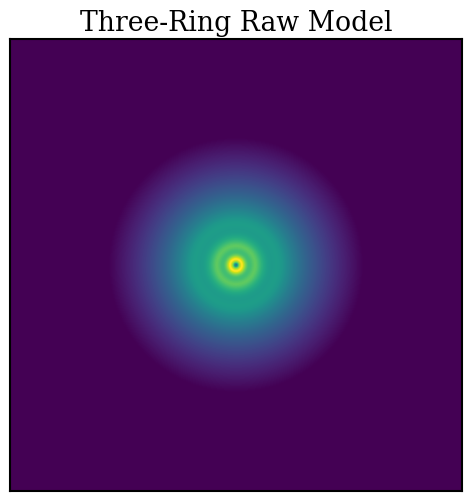

In [16]:
fig, ax = quick_implot(best_raw_model, norm=mpl.colors.LogNorm, norm_kwargs=dict(clip=True), clim='0.00001*99.99%, 99.99%', show=False)
ax.set_title("Three-Ring Raw Model")
plt.show()
plt.close()

In [17]:
# star brightness in the central pixel in MJy/sr
pixel_size = wdb.pxscale*u.pixel
pixel_size_sr = (pixel_size.to(u.rad))**2
print(f"Pixel size in steradians: {pixel_size_sr:.3e}")

# star brightness in Jy with given distance and stellar spectrum (see Photometry.ipynb)
# 0.82327 Jy for F200W;0.35116 Jy for F356W; 0.23643 Jy for F444W 
star_brightness_jy = 0.82327 * u.Jy
print(f"Star brightness in Jy: {star_brightness_jy:.3e}")

# Convert star brightness to MJy/sr
model_central_brightness_mjysr = (star_brightness_jy / pixel_size_sr).to(u.MJy/u.sr)
print(f"Central pixel brightness in the model in MJy/sr: {model_central_brightness_mjysr:.3e}")

# Add star brightness to the model, if the star's location is integral, add the value to the stellar pixel; if not, the star's brightness should be added across 4 closest pixels
model_central_brightness = model_central_brightness_mjysr.value
if wdb.c_star[0]%1 == 0 and wdb.c_star[1]%1 == 0:
    best_raw_model[int(wdb.c_star[1]), int(wdb.c_star[0])] += model_central_brightness
else:
    jvals = int(np.floor(wdb.c_star[0])), int(np.ceil(wdb.c_star[0]))
    ivals = int(np.floor(wdb.c_star[1])), int(np.ceil(wdb.c_star[1]))
    for j in jvals:
        for i in ivals:
            # Calculate the fraction of the star's brightness that should be added to this pixel based on the distance from the star's exact location
            j_fraction = 1 - abs(wdb.c_star[0] - j)
            i_fraction = 1 - abs(wdb.c_star[1] - i)
            fraction = j_fraction * i_fraction
            print(f"Adding {fraction:.2f} of the star's brightness to pixel ({i}, {j})")
            best_raw_model[i, j] += model_central_brightness * fraction

Pixel size in steradians: 2.213e-14 rad2
Star brightness in Jy: 8.233e-01 Jy
Central pixel brightness in the model in MJy/sr: 3.720e+07 MJy / sr
Adding 0.25 of the star's brightness to pixel (324, 324)
Adding 0.25 of the star's brightness to pixel (325, 324)
Adding 0.25 of the star's brightness to pixel (324, 325)
Adding 0.25 of the star's brightness to pixel (325, 325)


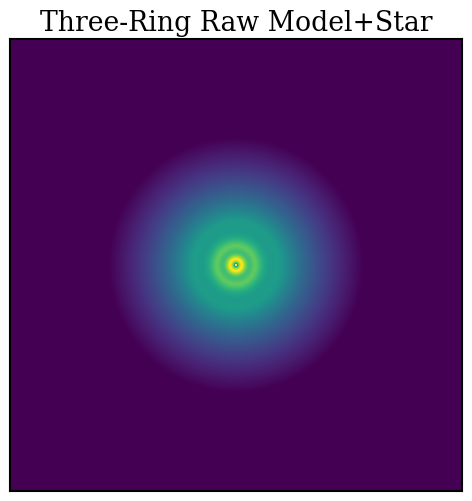

In [18]:
fig, ax = quick_implot(best_raw_model, norm=mpl.colors.LogNorm, norm_kwargs=dict(clip=True), clim='0.00001*99.99%, 99.99%', show=False)
ax.set_title("Three-Ring Raw Model+Star")
plt.show()
plt.close()

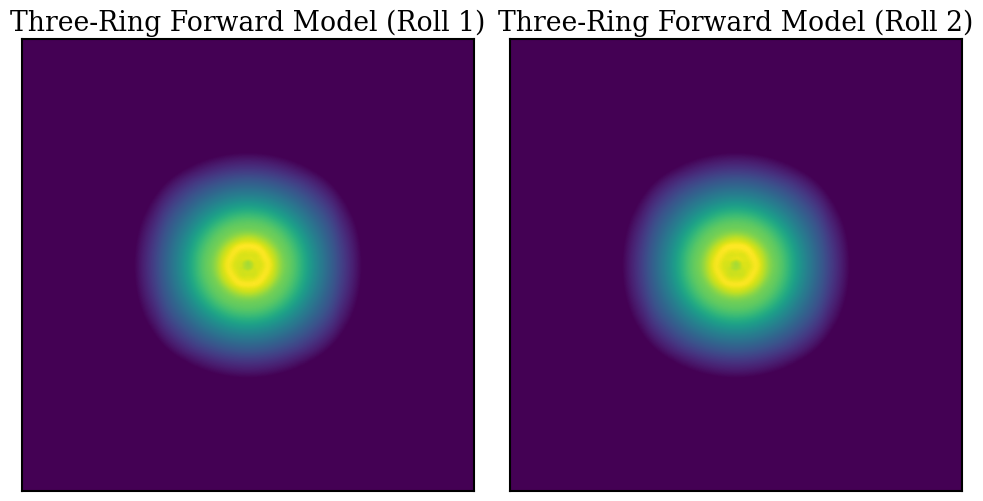

In [19]:
# forward model
forward_best_model = wdb.convolver.convolve_model(best_raw_model, wdb.pxscale, wdb.c_star)
fig, axes = quick_implot(forward_best_model, norm=mpl.colors.LogNorm, norm_kwargs=dict(clip=True), clim='0.001*99.99%, 99.99%', show=False)

# Iterate over the returned axes if there are multiple rolls
for i, ax in enumerate(axes):
    ax.set_title(f"Three-Ring Forward Model (Roll {i+1})")
    
plt.show()

JWST_NIRCAM_NRCA2_F200W_MASKRND_MASK335R_SUB320A335R
Science data:   2 exposures of shape (650,650)
Reference data: 241 exposures of shape (650,650)

RDI Settings:
Mode: HPFRDI (Winnie)
'opt_smoothing_fn': <function high_pass_filter_sequence at 0x7e2beef36520>
'opt_smoothing_kwargs': {'filtersize': 1.0994602853484432}
Extension for output files: 'hpfrdi_psfsub'
1 optimization zone(s)
1 subtraction zone(s)


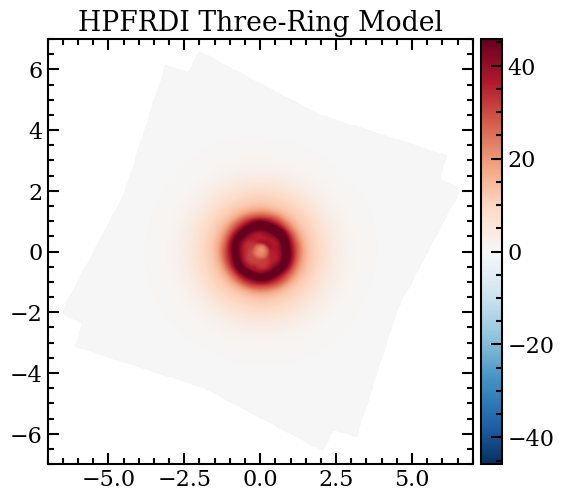

In [20]:
# HPFRDI reduction with the best-fit model
wdb.set_circumstellar_model(model_cube=forward_best_model)
wdb.hpfrdi_presets()
hpfrdi_model = wdb.run_rdi(forward_model=True)

# show only the HPFRDI results for the best-fit model
fig, ax, cbar = quick_implot(
    hpfrdi_model.im,
    cmap="RdBu_r",
    clim_perc=99,
    show=False,
    cbar=True,
    cbar_kwargs=dict(pad=0.015),
    panelsize=(6, 5),
    extent=rdi_reduc.extent,
    lims=[-7, 7],
    show_ticks=True,
)
ax.set_title("HPFRDI Three-Ring Model")
plt.show()


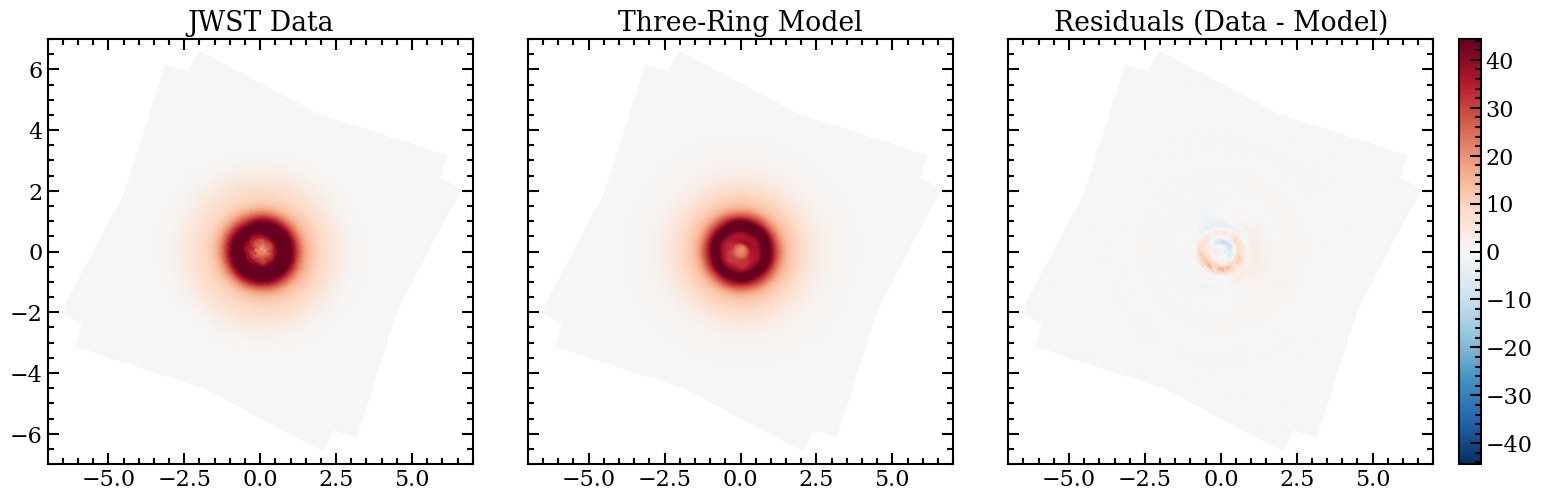

In [21]:
fig, axes, cbar = quick_implot(
    [rdi_reduc.im, hpfrdi_model.im, rdi_reduc.im - hpfrdi_model.im],
    cmap="RdBu_r",
    clim_perc=99,
    show=False,
    cbar=True,
    cbar_kwargs=dict(pad=0.015),
    panelsize=(6, 5),
    extent=rdi_reduc.extent,
    lims=[-7, 7],
    show_ticks=True,
)
for ax, title in zip(axes, ["JWST Data", "Three-Ring Model", "Residuals (Data - Model)"]):
    ax.set_title(title)
plt.show()

Deconvolving Model RDI with 1000 iterations...


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

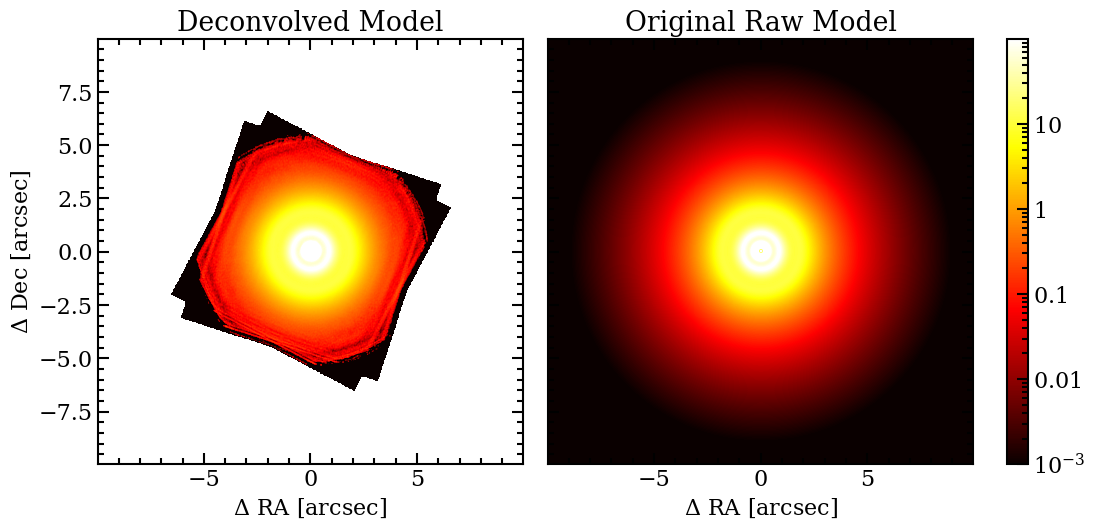

In [22]:
num_iter = 1000 

# Setup intermediate return iterations tracking
return_iters = np.concatenate([np.arange(1, 10), np.arange(10, num_iter + 1, 10)])

# recreate the exclude mask to prevent central artifacts from dominating
excl_mask = winnie.utils.px_size_to_ang_size(
    winnie.utils.dist_to_pt(wdb.c_star, wdb.nx, wdb.ny),
    wdb.pxscale
).value > 7

# 1. Deconvolve the Forward Modeled RDI image (hpfrdi_model)
print(f"Deconvolving Model RDI with {num_iter} iterations...")
manual_eps = 0.05 * np.nanmedian(np.abs(hpfrdi_model.rolls - np.nanmedian(hpfrdi_model.rolls)))
deconv_fm_results = wdb.run_deconvolution(
    reduc_in=hpfrdi_model, 
    num_iter=num_iter, 
    epsilon=manual_eps, 
    return_iters=return_iters,
    excl_mask_in=excl_mask,
    init_from_reduc=True,
    save_products=True, 
    show_progress=True
)
# Extract the final deconvolved forward-modeled image
deconv_fm_im = deconv_fm_results[0].im

# 2. Plot and Compare: Deconvolved Model vs Original Raw Model
fig, axes, cbar = quick_implot(
    [deconv_fm_im, best_raw_model], 
    cmap='hot', 
    clim='0.00001*99.5%, 99.5%',
    norm=mpl.colors.LogNorm,
    norm_kwargs=dict(clip=True),
    show=False,
    cbar=True,
    cbar_kwargs=dict(pad=0.03), 
    panelsize=(6, 5), 
    extent=rdi_reduc.extent, 
    show_ticks=True
)

labels = ['Deconvolved Model', 'Original Raw Model']
for i, ax in enumerate(axes):
    ax.set_title(labels[i])
    ax.set_xlabel(r'$\Delta$ RA [arcsec]')
    if i == 0:
        ax.set_ylabel(r'$\Delta$ Dec [arcsec]')

plt.show()

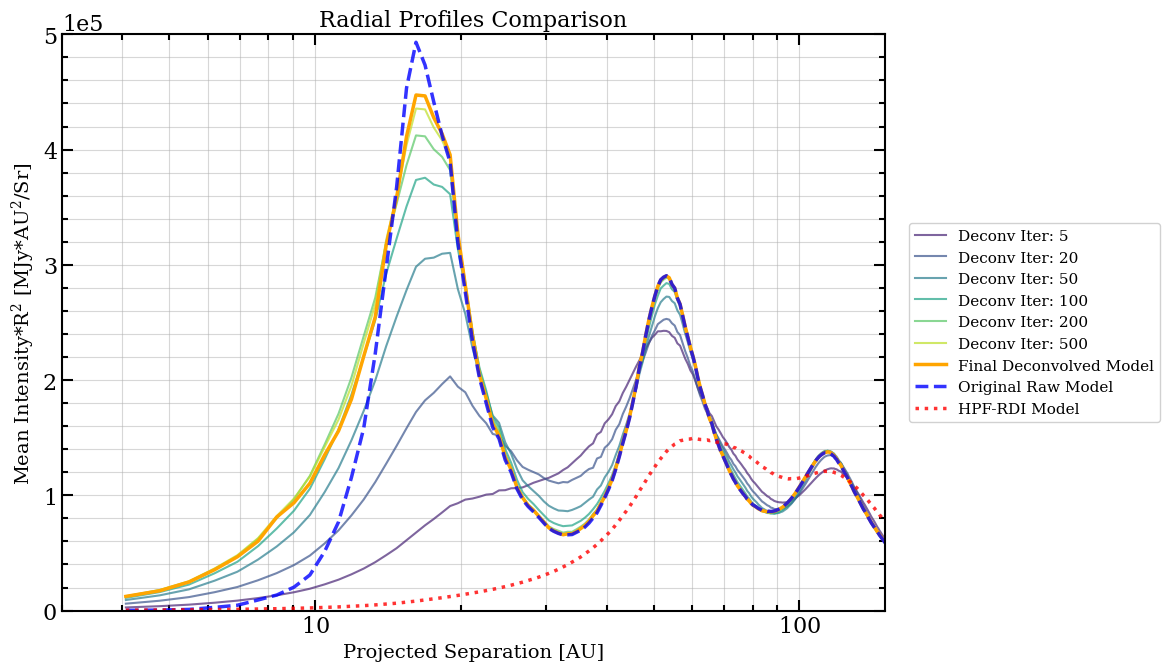

In [23]:
# Calculate radial profiles
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import winnie.utils

def simple_radial_profile(image, center, r_bins_pix):
    """
    Computes azimuthally-averaged radial profile.
    """
    y, x = np.indices(image.shape)
    r_pix = np.hypot(x - center[0], y - center[1])
    
    profile = np.zeros(len(r_bins_pix) - 1)
    for i in range(len(profile)):
        mask = (r_pix >= r_bins_pix[i]) & (r_pix < r_bins_pix[i+1])
        if np.any(mask):
            profile[i] = np.nanmean(image[mask])
        else:
            profile[i] = np.nan
    return profile

# Convert r_bins from AU to pixels to use on the images directly
r_bins_au = np.linspace(3, 500, 700)

# The size of a single pixel in AU for calculating bin edges
# Extracting the raw `.value` strips the '1/pix' unit so winnie handles it cleanly 
pix_size_in_arcsec = wdb.pxscale.to('arcsec/pixel').value
pix_size_in_au = winnie.utils.ang_size_to_proj_sep(pix_size_in_arcsec, distance).value
r_bins_pix = r_bins_au / pix_size_in_au

# Calculate the centers of the bins in AU for plotting the x-axis
r_centers_au = (r_bins_au[:-1] + r_bins_au[1:]) / 2.
r_squared_au = r_centers_au**2

# Generate base profiles
profile_hpfrdi_model = simple_radial_profile(hpfrdi_model.im, wdb.c_star, r_bins_pix)
profile_deconv = simple_radial_profile(deconv_fm_im, wdb.c_star, r_bins_pix)
profile_raw_model = simple_radial_profile(best_raw_model, wdb.c_star, r_bins_pix)

# Setup figure
plt.figure(figsize=(12, 7)) # slightly wider to fit legend outside

# Plot intermediate radial profiles from deconvolution
target_iters = [5, 20, 50, 100, 200, 500]  # Shared from your previous block
intermediate_cube = deconv_fm_results[1]
colors = cm.viridis(np.linspace(0.1, 0.9, len(target_iters)))

for i, target in enumerate(target_iters):
    # Find the closest iteration match
    idx = np.argmin(np.abs(np.array(return_iters) - target))
    closest_iter = return_iters[idx]
    
    current_im = intermediate_cube[idx]
    if current_im.ndim == 3:
        current_im = np.nanmean(current_im, axis=0)
        
    # Generate profile for this iteration
    prof = simple_radial_profile(current_im, wdb.c_star, r_bins_pix)
    
    # Plot intermediate profile
    plt.plot(r_centers_au, prof * r_squared_au, 
             color=colors[i], linewidth=1.5, alpha=0.7, 
             label=f'Deconv Iter: {closest_iter}')

# Plot final models
plt.plot(r_centers_au, profile_deconv*r_squared_au, label='Final Deconvolved Model', color='orange', linewidth=2.5, alpha=1.0)
plt.plot(r_centers_au, profile_raw_model*r_squared_au, label='Original Raw Model', color='blue', linestyle='--', linewidth=2.5, alpha=0.8)
plt.plot(r_centers_au, profile_hpfrdi_model*r_squared_au, label='HPF-RDI Model', color='red', linestyle=':', linewidth=2.5, alpha=0.8)

plt.xlabel('Projected Separation [AU]', fontsize=14)
plt.ylabel(r'Mean Intensity*$R^2$ [MJy*$AU^2$/Sr]', fontsize=14)
plt.title('Radial Profiles Comparison', fontsize=16)

# Make legend more prominent and position outside plot box
plt.legend(fontsize=11, loc='center left', bbox_to_anchor=(1.02, 0.5), framealpha=0.9)

plt.xlim(3, 150)
plt.ylim(0, 5e5)  # Adjusted for better visibility of features
plt.xscale('log') # Log scale often helps if the range of separations is large

# Make y axis ticks in scientific notation for clarity
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

# Improve grid lines for easier reading
plt.grid(True, which="both", ls="-", alpha=0.5)

plt.tight_layout()
plt.show()

Optimal iteration found: 630 (Mean Fractional Error: 0.004290665564231)


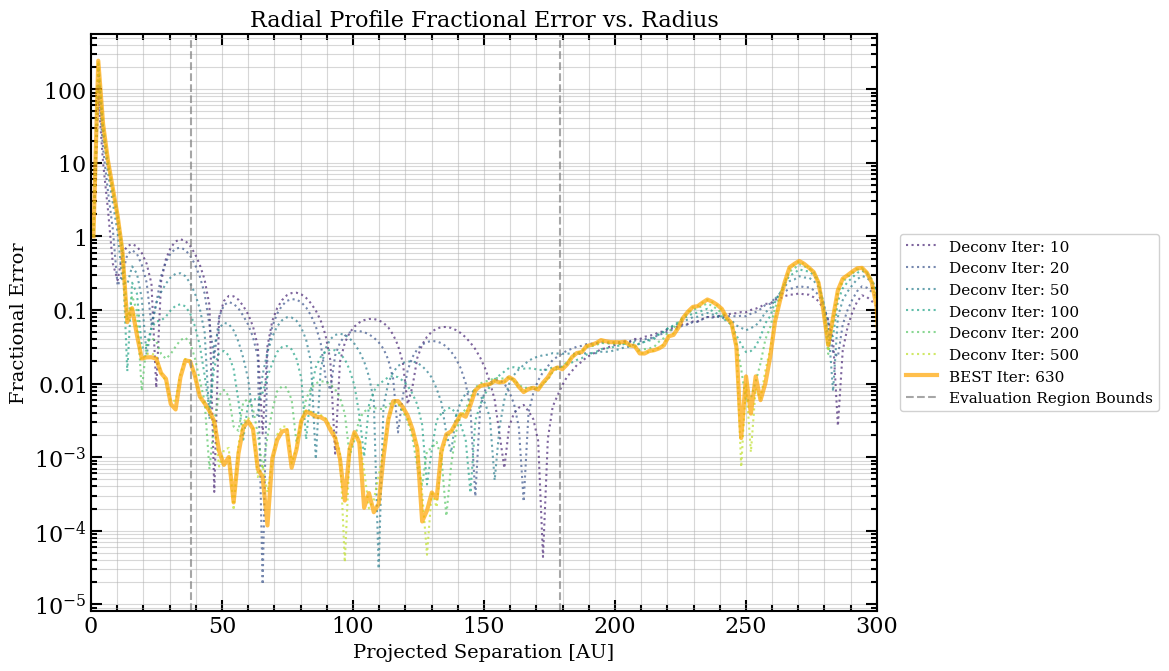

In [24]:
# Calculate radial profiles
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import winnie.utils

def convert_radial_profile(image, r_pix, r_bins_pix):
    """
    Computes azimuthally-averaged radial profile.
    Inputs:
    - image: 2D array of the image to profile
    - r_pix: 2D array of pixel radii from the star center (same shape as image)
    - r_bins_pix: 1D array of bin edges in pixels
    Output:
    - profile: 1D array of mean values in each radial bin
    """
    flat_img = image.ravel()
    flat_r = r_pix.ravel()
    
    # Handle NaNs in the image before binning
    nan_mask = np.isnan(flat_img)
    if np.any(nan_mask):
        flat_img = flat_img[~nan_mask]
        flat_r = flat_r[~nan_mask]
        
    # Map pixel radii to bin indices: bins[i-1] <= x < bins[i]
    bin_assignments = np.digitize(flat_r, r_bins_pix) - 1
    
    # Keep only the assignments that fall within our valid bin ranges
    valid = (bin_assignments >= 0) & (bin_assignments < len(r_bins_pix) - 1)
    flat_img = flat_img[valid]
    bin_assignments = bin_assignments[valid]
    
    # Calculate sums and counts per bin using bincount
    bin_sums = np.bincount(bin_assignments, weights=flat_img, minlength=len(r_bins_pix) - 1)
    bin_counts = np.bincount(bin_assignments, minlength=len(r_bins_pix) - 1)
    
    # Compute mean safely avoiding divide-by-zero warnings
    with np.errstate(divide='ignore', invalid='ignore'):
        profile = bin_sums / bin_counts
    profile[bin_counts == 0] = np.nan
    
    return profile

# Convert r_bins from pixels to AU for plotting the x-axis
r_bins_pix = np.arange(best_raw_model.shape[0]//2+1) # divide the image into annuli of 1 pixel width
pix_size_in_arcsec = wdb.pxscale.to('arcsec/pixel').value
pix_size_in_au = winnie.utils.ang_size_to_proj_sep(pix_size_in_arcsec, distance).value
r_centers_pix = (r_bins_pix[:-1] + r_bins_pix[1:]) / 2.
r_centers_au = r_centers_pix * pix_size_in_au

# =====================================================================
# PRE-COMPUTE COORDINATE GRID ONCE
# =====================================================================
y, x = np.indices(best_raw_model.shape)
r_pix = np.hypot(x - wdb.c_star[0], y - wdb.c_star[1])

# Generate base raw model profile using the new fast function
profile_raw_model = convert_radial_profile(best_raw_model, r_pix, r_bins_pix)

# =====================================================================
# Evaluate ALL iterations and CACHE profiles for plotting
# =====================================================================
intermediate_cube = deconv_fm_results[1]
mean_fractional_errors = []
all_profiles = []  # Cache to store profiles and avoid recalculating for plots

# Define a radial mask to ignore the inner working angle and extreme outer empty space.
r_min_au = r_au_iwa  
r_max_au = 178.88
eval_mask = (r_centers_au > r_min_au) & (r_centers_au < r_max_au) 

for idx, iter_num in enumerate(return_iters):
    current_im = intermediate_cube[idx]
    if current_im.ndim == 3:
        current_im = np.nanmean(current_im, axis=0)
        
    # Calculate profile using the fast method
    prof = convert_radial_profile(current_im, r_pix, r_bins_pix)
    all_profiles.append(prof)
    
    # Calculate Fractional Error
    error_prof = np.abs(prof - profile_raw_model) / (np.abs(profile_raw_model) + 1e-12)
    
    # Calculate the mean fractional error ONLY across the valid disk region
    global_error = np.nanmean(error_prof[eval_mask])
    mean_fractional_errors.append(global_error)

mean_fractional_errors = np.array(mean_fractional_errors)

# Find the best iteration index
best_idx = np.nanargmin(mean_fractional_errors)
best_iter = return_iters[best_idx]
best_error = mean_fractional_errors[best_idx]

print(f"Optimal iteration found: {best_iter} (Mean Fractional Error: {best_error:.15f})")

# =====================================================================
# Plotting
# =====================================================================
plt.figure(figsize=(12, 7)) 

target_iters = [10, 20, 50, 100, 200, 500]
colors = cm.viridis(np.linspace(0.1, 0.9, len(target_iters)))

# Plot intermediate radial error profiles from cache
for i, target in enumerate(target_iters):
    idx = np.argmin(np.abs(np.array(return_iters) - target))
    closest_iter = return_iters[idx]
    
    # Zero computation here—just pulling data out of our cache list
    prof = all_profiles[idx]
    error_prof = np.abs(prof - profile_raw_model) / (np.abs(profile_raw_model) + 1e-12)
    
    plt.plot(r_centers_au, error_prof, color=colors[i], linewidth=1.5, alpha=0.7, linestyle=':', label=f'Deconv Iter: {closest_iter}')

# Plot the BEST iteration distinctly from cache
best_prof = all_profiles[best_idx]
best_error_prof = np.abs(best_prof - profile_raw_model) / (np.abs(profile_raw_model) + 1e-12)

plt.plot(r_centers_au, best_error_prof, color='orange', linewidth=3, alpha=0.7, linestyle='-', label=f'BEST Iter: {best_iter}')

# Mark the evaluation region used for the mean math
plt.axvline(r_min_au, color='gray', linestyle='--', alpha=0.7, label='Evaluation Region Bounds')
plt.axvline(r_max_au, color='gray', linestyle='--', alpha=0.7)

plt.xlabel('Projected Separation [AU]', fontsize=14)
plt.ylabel('Fractional Error', fontsize=14)
plt.title('Radial Profile Fractional Error vs. Radius', fontsize=16)

plt.yscale('log')
plt.legend(fontsize=11, loc='center left', bbox_to_anchor=(1.02, 0.5), framealpha=0.9)
plt.xlim(0, 300)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.tight_layout()
plt.show()

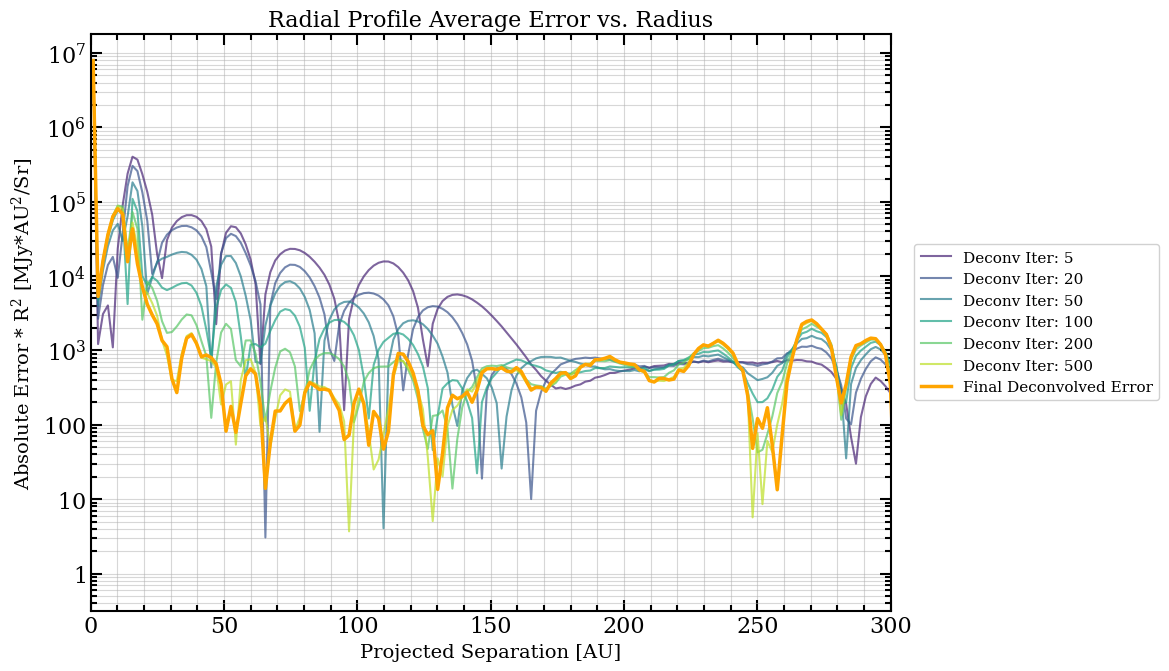

In [25]:
# Calculate radial profiles
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import winnie.utils

def simple_radial_profile(image, center, r_bins_pix):
    """
    Computes azimuthally-averaged radial profile.
    """
    y, x = np.indices(image.shape)
    r_pix = np.hypot(x - center[0], y - center[1])
    
    profile = np.zeros(len(r_bins_pix) - 1)
    for i in range(len(profile)):
        mask = (r_pix >= r_bins_pix[i]) & (r_pix < r_bins_pix[i+1])
        if np.any(mask):
            profile[i] = np.nanmean(image[mask])
        else:
            profile[i] = np.nan
    return profile

# Convert r_bins from pixels to AU for plotting the x-axis
r_bins_pix = np.arange(best_raw_model.shape[0]//2+1) # divide the image into annuli of 1 pixel width
pix_size_in_arcsec = wdb.pxscale.to('arcsec/pixel').value
pix_size_in_au = winnie.utils.ang_size_to_proj_sep(pix_size_in_arcsec, distance).value
r_centers_pix = (r_bins_pix[:-1] + r_bins_pix[1:]) / 2.
r_centers_au = r_centers_pix * pix_size_in_au
r_squared_au = r_centers_au**2

# Generate base profiles
# profile_hpfrdi_model = simple_radial_profile(hpfrdi_model.im, wdb.c_star, r_bins_pix)
profile_deconv = simple_radial_profile(deconv_fm_im, wdb.c_star, r_bins_pix)
profile_raw_model = simple_radial_profile(best_raw_model, wdb.c_star, r_bins_pix)

# Setup figure
plt.figure(figsize=(12, 7)) # slightly wider to fit legend outside

# Plot intermediate radial error profiles from deconvolution
target_iters = [5, 20, 50, 100, 200, 500]  # Shared from your previous block
intermediate_cube = deconv_fm_results[1]
colors = cm.viridis(np.linspace(0.1, 0.9, len(target_iters)))

for i, target in enumerate(target_iters):
    # Find the closest iteration match
    idx = np.argmin(np.abs(np.array(return_iters) - target))
    closest_iter = return_iters[idx]
    
    current_im = intermediate_cube[idx]
    if current_im.ndim == 3:
        current_im = np.nanmean(current_im, axis=0)
        
    # Generate profile for this iteration
    prof = simple_radial_profile(current_im, wdb.c_star, r_bins_pix)
    
    # Calculate absolute error against the original raw model
    error_prof = np.abs(prof - profile_raw_model)
    
    # Plot intermediate error profile
    plt.plot(r_centers_au, error_prof * r_squared_au, 
             color=colors[i], linewidth=1.5, alpha=0.7, 
             label=f'Deconv Iter: {closest_iter}')

# Plot final model error
final_error = np.abs(profile_deconv - profile_raw_model)
plt.plot(r_centers_au, final_error * r_squared_au, label='Final Deconvolved Error', color='orange', linewidth=2.5, alpha=1.0)

plt.xlabel('Projected Separation [AU]', fontsize=14)
plt.ylabel(r'Absolute Error * $R^2$ [MJy*$AU^2$/Sr]', fontsize=14)
plt.title('Radial Profile Average Error vs. Radius', fontsize=16)

# Use logarithmic scale on the y-axis
plt.yscale('log')

# Make legend more prominent and position outside plot box
plt.legend(fontsize=11, loc='center left', bbox_to_anchor=(1.02, 0.5), framealpha=0.9)

plt.xlim(0, 300)
# plt.ylim() can be adjusted manually here if needed for log scale (e.g., plt.ylim(1e2, 1e6))

# Improve grid lines for easier reading
plt.grid(True, which="both", ls="-", alpha=0.5)

plt.tight_layout()
plt.show()

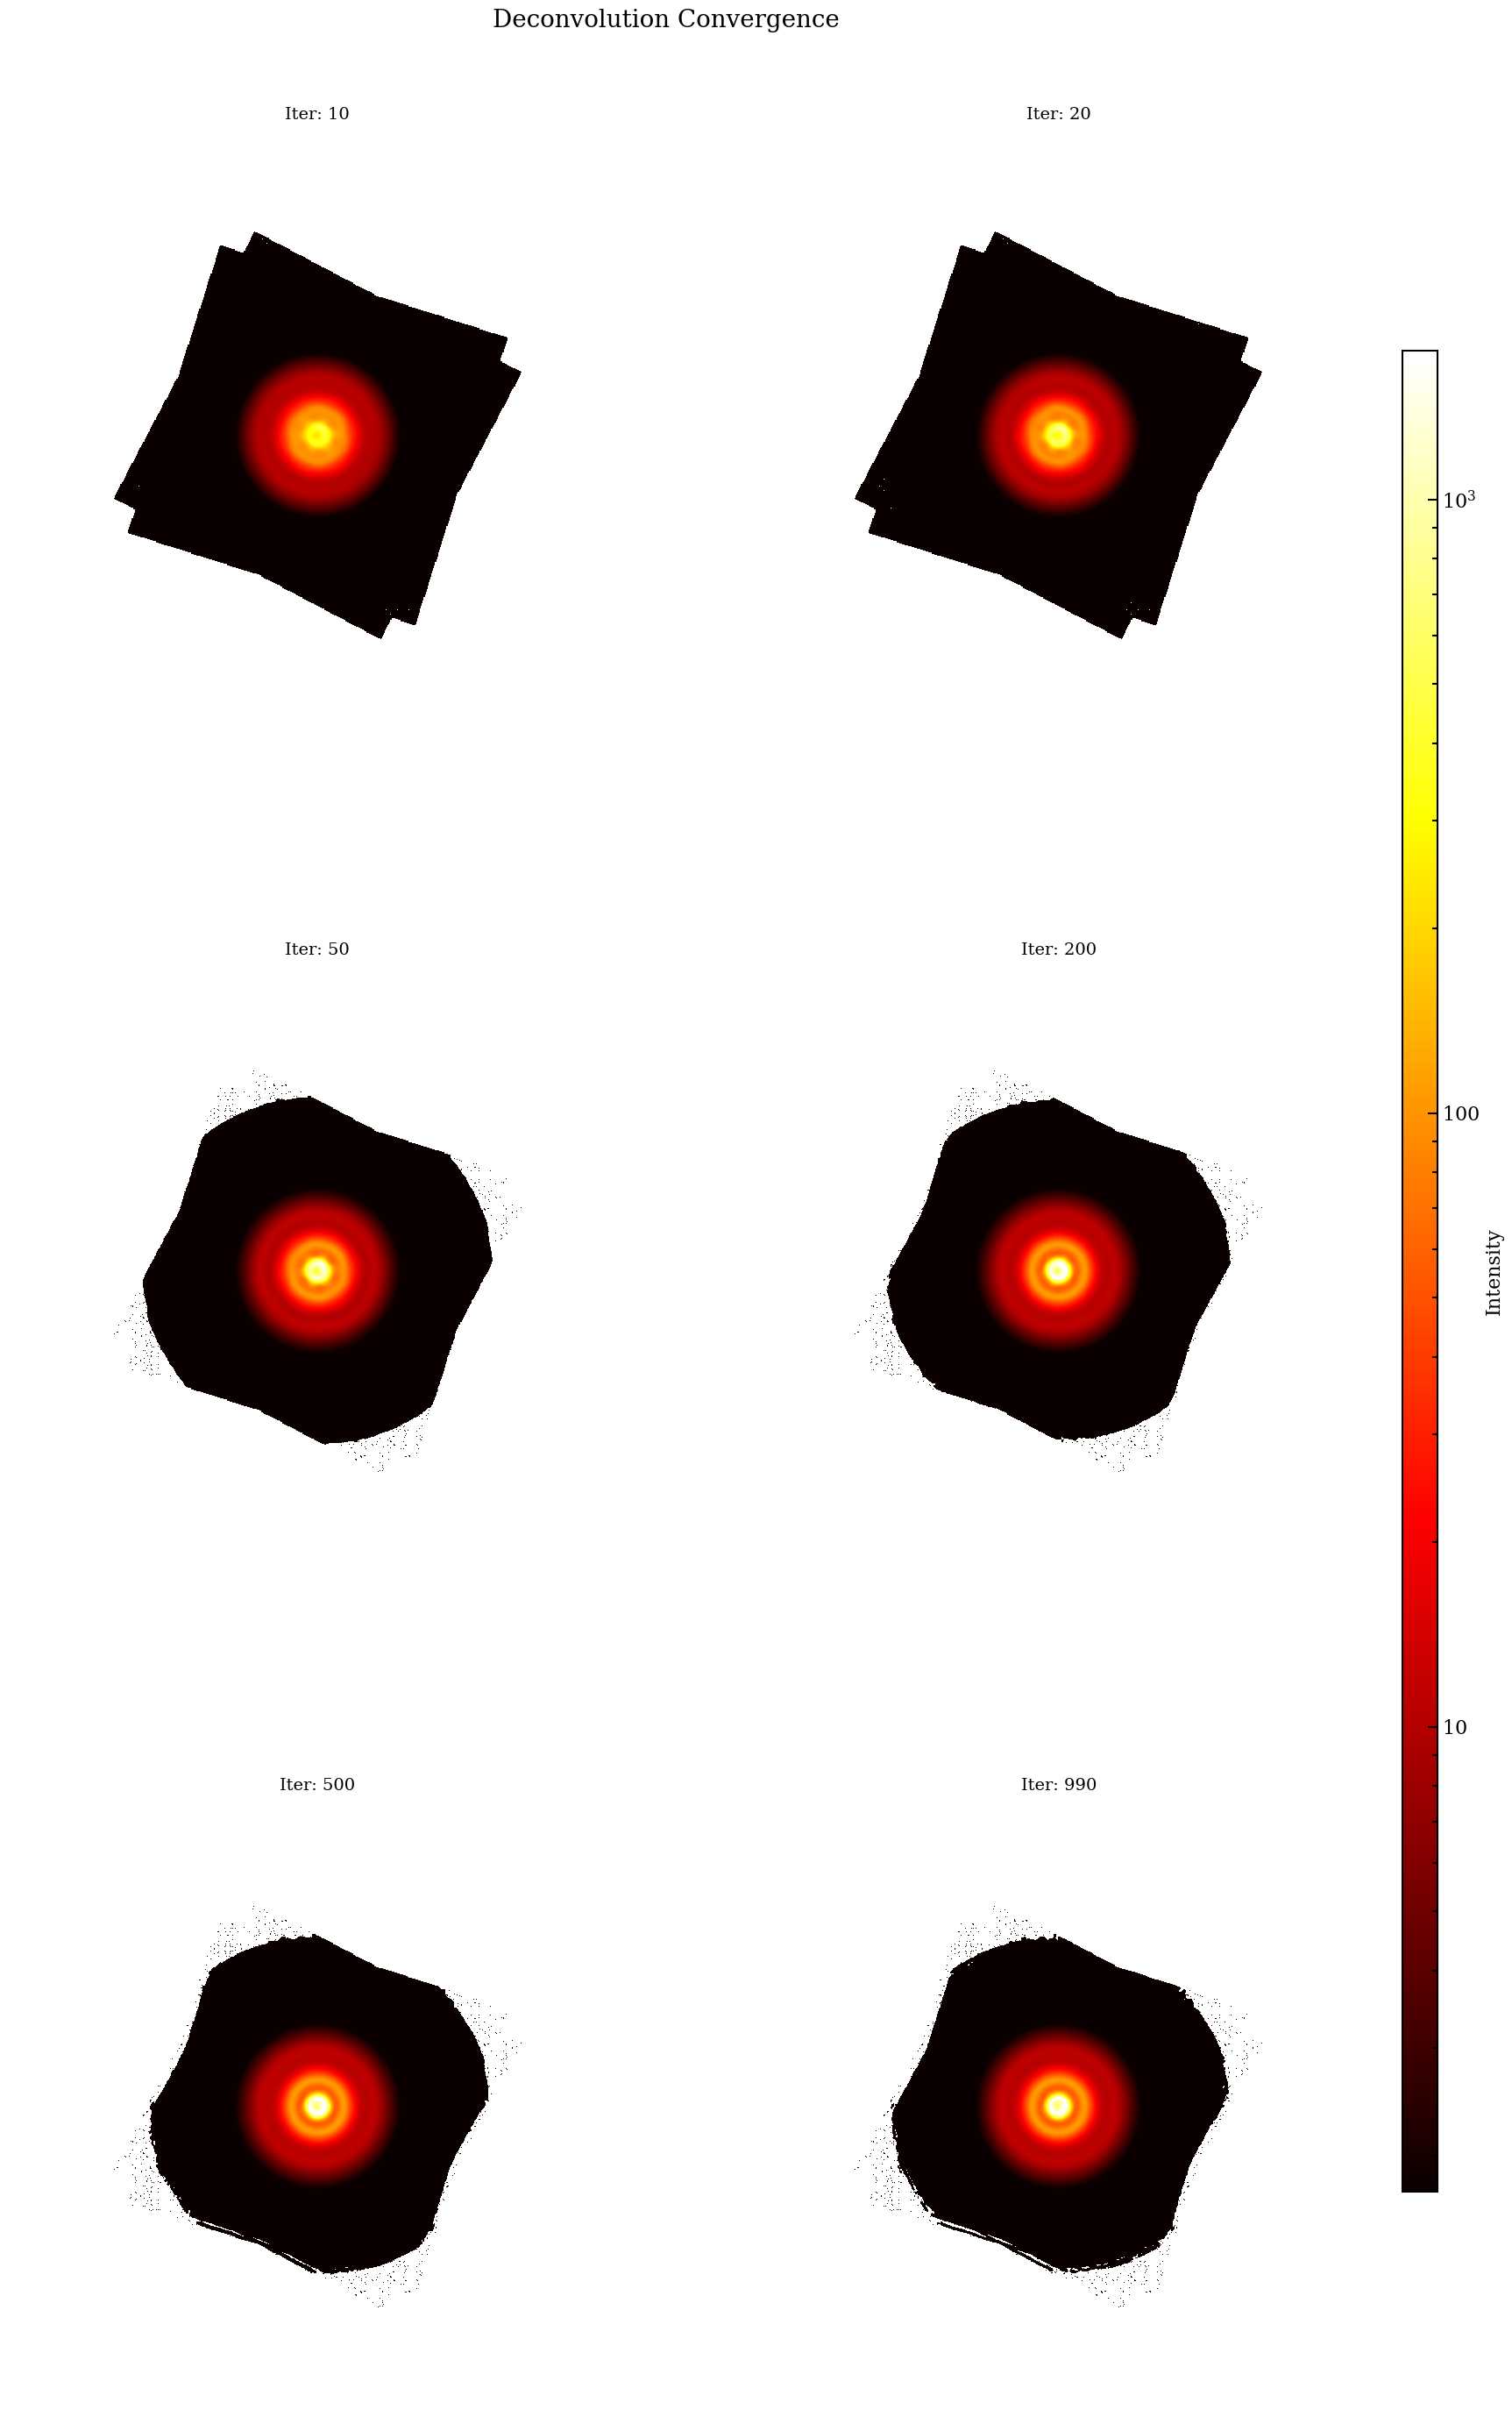

In [26]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# Define the target iterations you want to display (up to 6 for a 3x2 grid)
target_iters = [10, 20, 50, 200, 500, 990]  # Feel free to change these numbers
intermediate_cube = deconv_fm_results[1]

# Pre-gather the images to compute global vmin/vmax
images_to_plot = []
closest_iters = []

for target in target_iters:
    idx = np.argmin(np.abs(np.array(return_iters) - target))
    closest_iters.append(return_iters[idx])
    
    current_im = intermediate_cube[idx]
    if current_im.ndim == 3:
        current_im = np.nanmean(current_im, axis=0)
    images_to_plot.append(current_im)

# Calculate global vmin and vmax for a shared color scale
global_vmax = np.nanpercentile([img for img in images_to_plot], 99.99)
global_vmin = 0.001*global_vmax

fig, axes = plt.subplots(3, 2, figsize=(20, 30))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < len(images_to_plot):
        current_im = images_to_plot[i]
        
        im = ax.imshow(
            current_im, 
            norm=mpl.colors.LogNorm(vmin=global_vmin, vmax=global_vmax), 
            cmap='hot',
            origin='lower'
        )
        ax.set_title(f'Iter: {closest_iters[i]}', fontsize=14)
    
    # Hide axes for all subplots (even the empty ones if target_iters < 6)
    ax.axis('off')

# Add a single shared colorbar for the entire figure
fig.subplots_adjust(bottom=0.05, top=0.95, right=0.9)
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
# The 'im' from the last plotted image is fine to use since they all share the same norm
fig.colorbar(im, cax=cbar_ax, label='Intensity')

plt.suptitle('Deconvolution Convergence', fontsize=20, y=0.98)
plt.show()

The best iteration number is 370 with an MAE of 1.75379e+02


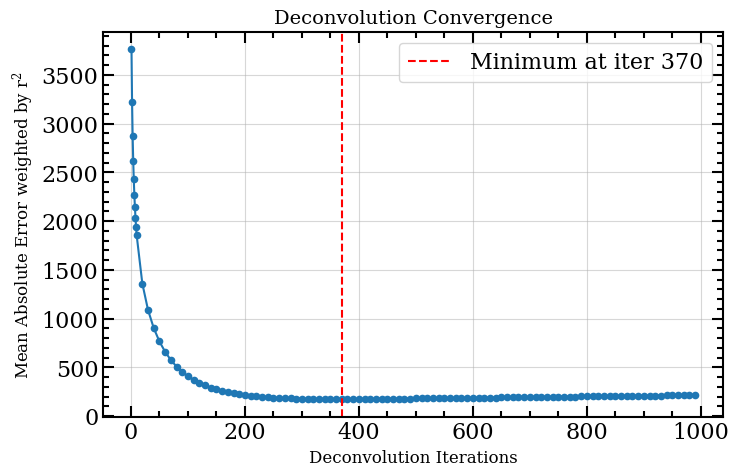

In [27]:
# Consider the best iteration pixel-wise error
import numpy as np
import matplotlib.pyplot as plt

# 1. Define an evaluation mask to focus on the disk region
y, x = np.indices(best_raw_model.shape)
r_pix = np.hypot(x - wdb.c_star[0], y - wdb.c_star[1])
r_au = ang_size_to_proj_sep(px_size_to_ang_size(r_pix, wdb.pxscale), distance).value
eval_mask = (r_au >= r_au_iwa) & (r_au <= 178.88)

# Create an r^2 map in pixels to weight the errors
y_idx, x_idx = np.indices(best_raw_model.shape)
r_pix_sq = (x_idx - wdb.c_star[0])**2 + (y_idx - wdb.c_star[1])**2
errors = []
iterations = return_iters

# The second element contains the numpy array of intermediate images
intermediate_cube = deconv_fm_results[1]

# 2. Iterate through the intermediate results to compute the differences
for i in range(len(iterations)):
    current_im = intermediate_cube[i]
    
    # If the intermediate results returned un-collapsed rolls (e.g. shape (2, 650, 650)), 
    # we need to average them across the first axis to get the 2D combined image.
    if current_im.ndim == 3:
        current_im = np.nanmean(current_im, axis=0)
    
    # Calculate r^2 weighted Mean Absolute Error within the mask
    diff = np.abs(current_im - best_raw_model)
    weighted_sq_err = r_pix_sq * diff
    mae = np.nanmean(weighted_sq_err[eval_mask])
    errors.append(mae)

errors = np.array(errors)

# 3. Find the minimum error
best_idx = np.argmin(errors)
best_iter = iterations[best_idx]
print(f"The best iteration number is {best_iter} with an MAE of {errors[best_idx]:.5e}")

# 4. Plot the error curve to visualize convergence behavior
plt.figure(figsize=(8, 5))
plt.plot(iterations[:-1], errors[:-1], marker='o', markersize=4, linestyle='-')
plt.axvline(best_iter, color='red', linestyle='--', label=f'Minimum at iter {best_iter}')
plt.xlabel("Deconvolution Iterations", fontsize=12)
plt.ylabel(r"Mean Absolute Error weighted by $r^2$", fontsize=12)
plt.title("Deconvolution Convergence", fontsize=14)
#plt.xscale('log') # Log scale often helps if iterations step up exponentially
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

# 5. Extract the formally "best" image
best_deconv_im = intermediate_cube[best_idx]
if best_deconv_im.ndim == 3:
    best_deconv_im = np.nanmean(best_deconv_im, axis=0)

### Added a bifracation structure to the model 
Test the structure can be recovered by the deconvolution process. The bifurcation structure is added as a spiral curve with 2 degrees and a width of 3 AU

In [28]:
# best 4644 | r01=16.11, r02=51.88, r03=112.82, flux1=1915.32, flux3=9.44, flux2=105.12
h0, ain, aout, g1, g2, wg1 = 0.035, 5, -5, 0.85, -0.2, 0.75
r0_vals = [16.11, 51.88, 112.82]
flux_vals = [1915.32, 105.12, 9.44]
pa_model = 0
incl_model = 0

# generate the raw model for the best-fit parameters
best_raw_model = np.zeros([650, 650])  # Start with an empty model
for i in range(3):
    best_raw_model += grater_2hg_disk_model(
        r0_vals[i],
        h0,
        ain,
        aout,
        pa_model,
        incl_model,
        g1,
        g2,
        wg1,
        cent=wdb.c_star,
        distance=distance,
        nx=wdb.nx,
        ny=wdb.ny,
        pxscale=wdb.pxscale,
        flux_max=flux_vals[i],
    )
    
# star brightness in the central pixel in MJy/sr
pixel_size = wdb.pxscale*u.pixel
pixel_size_sr = (pixel_size.to(u.rad))**2
print(f"Pixel size in steradians: {pixel_size_sr:.3e}")

# star brightness in Jy with given distance and stellar spectrum (see Photometry.ipynb)
# 0.82327 Jy for F200W;0.35116 Jy for F356W; 0.23643 Jy for F444W 
star_brightness_jy = 0.82327 * u.Jy
print(f"Star brightness in Jy: {star_brightness_jy:.3e}")

# Convert star brightness to MJy/sr
model_central_brightness_mjysr = (star_brightness_jy / pixel_size_sr).to(u.MJy/u.sr)
print(f"Central pixel brightness in the model in MJy/sr: {model_central_brightness_mjysr:.3e}")

# Add star brightness to the model, if the star's location is integral, add the value to the stellar pixel; if not, the star's brightness should be added across 4 closest pixels
model_central_brightness = model_central_brightness_mjysr.value
if wdb.c_star[0]%1 == 0 and wdb.c_star[1]%1 == 0:
    best_raw_model[int(wdb.c_star[1]), int(wdb.c_star[0])] += model_central_brightness
else:
    jvals = int(np.floor(wdb.c_star[0])), int(np.ceil(wdb.c_star[0]))
    ivals = int(np.floor(wdb.c_star[1])), int(np.ceil(wdb.c_star[1]))
    for j in jvals:
        for i in ivals:
            # Calculate the fraction of the star's brightness that should be added to this pixel based on the distance from the star's exact location
            j_fraction = 1 - abs(wdb.c_star[0] - j)
            i_fraction = 1 - abs(wdb.c_star[1] - i)
            fraction = j_fraction * i_fraction
            print(f"Adding {fraction:.2f} of the star's brightness to pixel ({i}, {j})")
            best_raw_model[i, j] += model_central_brightness * fraction

Pixel size in steradians: 2.213e-14 rad2
Star brightness in Jy: 8.233e-01 Jy
Central pixel brightness in the model in MJy/sr: 3.720e+07 MJy / sr
Adding 0.25 of the star's brightness to pixel (324, 324)
Adding 0.25 of the star's brightness to pixel (325, 324)
Adding 0.25 of the star's brightness to pixel (324, 325)
Adding 0.25 of the star's brightness to pixel (325, 325)


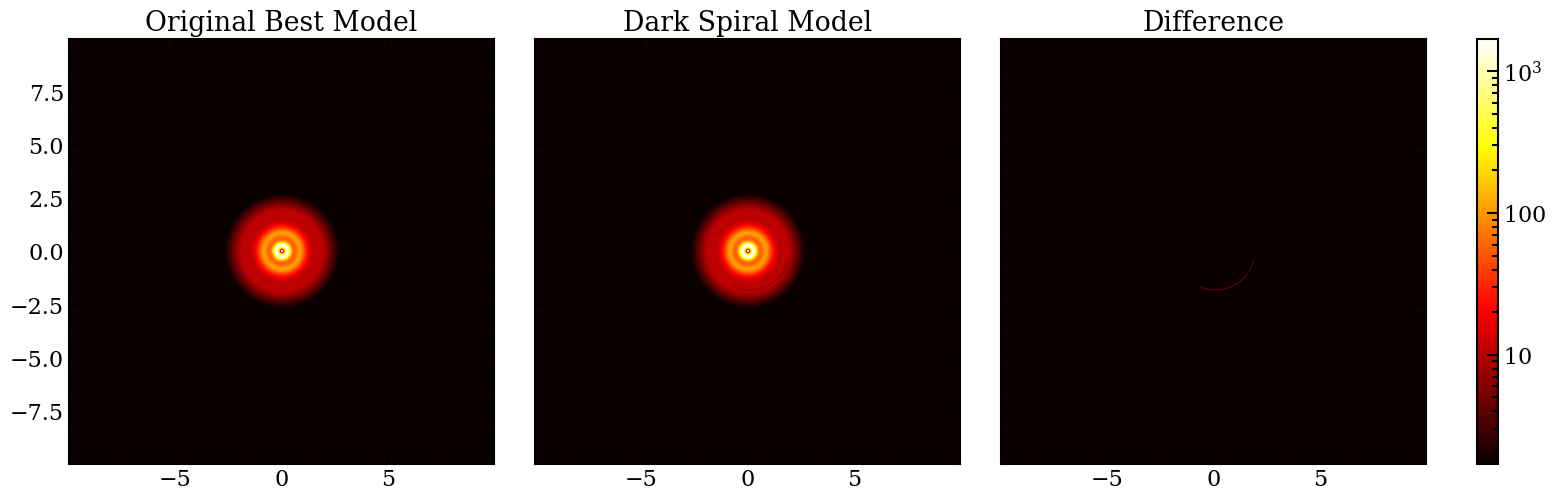

In [29]:
import numpy as np
import winnie.utils
import matplotlib as mpl
import matplotlib.pyplot as plt

# Make a copy of the best raw model to modify
bifurcated_raw_model = best_raw_model.copy()

# Spiral configuration
r_spiral_au = 116.0
pitch_angle_deg = 2.0
width_au = 3.0
darkening_fraction = 0.5 #50% darkening at the spine, tapering off with a Gaussian profile

# 1. Generate the 1D spine of the spiral explicitly bounded in the PA range
theta_spine = np.linspace(np.deg2rad(235), np.deg2rad(360), 1000)
theta_mod = theta_spine - 2 * np.pi
r_spine = r_spiral_au * np.exp(theta_mod * np.tan(np.deg2rad(pitch_angle_deg)))

# Physical coordinates of the isolated spiral spine
spine_x = r_spine * np.cos(theta_spine)
spine_y = r_spine * np.sin(theta_spine)

# 2. Extract physical pixel mapping
ny, nx = bifurcated_raw_model.shape
y, x = np.indices((ny, nx))
dy = y - wdb.c_star[1]
dx = x - wdb.c_star[0]

pix_size_in_arcsec = wdb.pxscale.to('arcsec/pixel').value
pix_size_in_au = winnie.utils.ang_size_to_proj_sep(pix_size_in_arcsec, distance).value

dx_au = dx * pix_size_in_au
dy_au = dy * pix_size_in_au

# 3. Calculate distance AND closest spine index to fade the edges
distances_au = np.zeros((ny, nx))
closest_spine_idx = np.zeros((ny, nx), dtype=int)

for i in range(ny):
    # Retrieve squared distances from row i pixels to all 1000 spiral spine points
    dist_sq = (dx_au[i, :, None] - spine_x[None, :])**2 + (dy_au[i, :, None] - spine_y[None, :])**2
    
    # Store the minimum distance and the index of the closest spine point
    distances_au[i, :] = np.sqrt(np.min(dist_sq, axis=1))
    closest_spine_idx[i, :] = np.argmin(dist_sq, axis=1)

# 4. Generate the continuous dark spiral profile
sigma_au = width_au / 2.355  
radial_profile = np.exp(-0.5 * (distances_au / sigma_au)**2)

# Create a taper along the length of the spine ---
spine_length = len(theta_spine)
taper_fraction = 0.15 # Fade the spiral over the first and last 15% of its length
taper_length = int(spine_length * taper_fraction)

azimuthal_taper = np.ones(spine_length)
# Smoothly fade in (using sine squared for a smooth S-curve)
azimuthal_taper[:taper_length] = np.sin(np.linspace(0, np.pi/2, taper_length))**2
# Smoothly fade out
azimuthal_taper[-taper_length:] = np.cos(np.linspace(0, np.pi/2, taper_length))**2

# Map the 1D taper to the 2D image based on the closest spine point
taper_2d = azimuthal_taper[closest_spine_idx]

# Combine the radial distance profile with the azimuthal boundary taper
spiral_profile = radial_profile * taper_2d

# 5. Apply the subtraction
bifurcated_raw_model -= best_raw_model * spiral_profile * darkening_fraction

# Plot the new model and comparison
fig, axes, cbar = quick_implot(
    [best_raw_model, bifurcated_raw_model, best_raw_model - bifurcated_raw_model], 
    cmap='hot', 
    clim='0.001*99.99%, 99.99%',
    norm=mpl.colors.LogNorm, # Assuming you imported matplotlib as mpl earlier
    norm_kwargs=dict(clip=True),
    show=False, 
    cbar=True, 
    cbar_kwargs=dict(pad=0.03), 
    panelsize=(6, 5), 
    extent=rdi_reduc.extent, 
    show_ticks=True
)

labels = ['Original Best Model', 'Dark Spiral Model', 'Difference']
for i, ax in enumerate(axes):
    ax.set_title(labels[i])
    
plt.show()

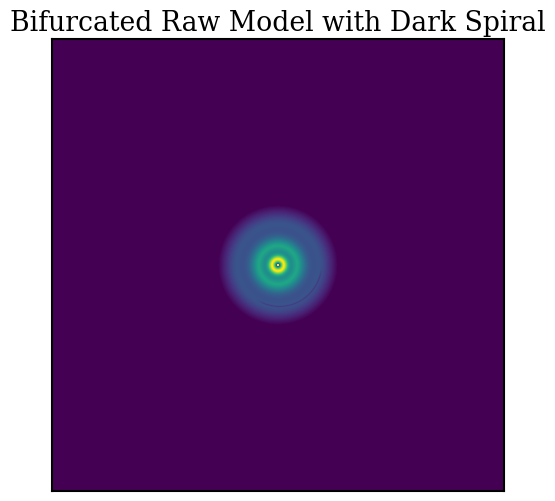

In [30]:
fig, ax = quick_implot(bifurcated_raw_model, norm=mpl.colors.LogNorm, norm_kwargs=dict(clip=True), clim='0.001*99.99%, 99.99%', show=False)
ax.set_title("Bifurcated Raw Model with Dark Spiral")
plt.show()
plt.close()

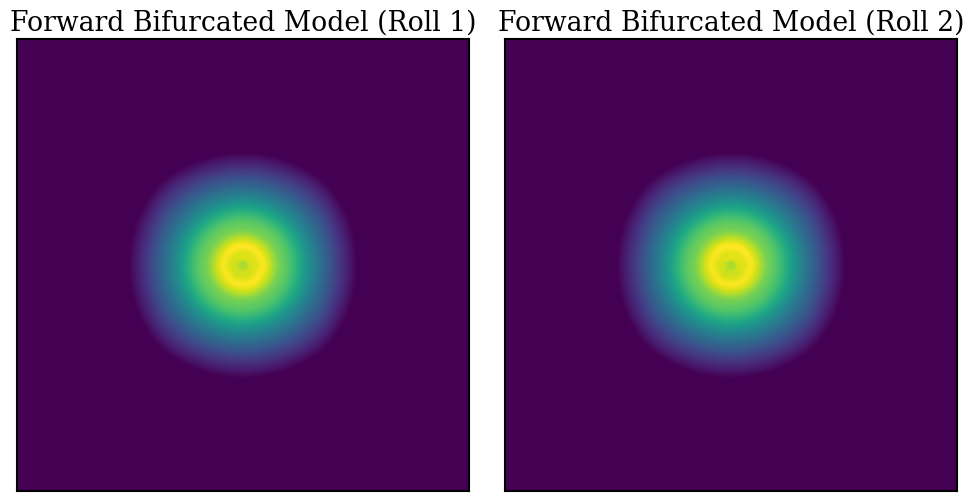

In [31]:
# forward model
forward_bifurcated_model = wdb.convolver.convolve_model(bifurcated_raw_model, wdb.pxscale, wdb.c_star)
fig, axes = quick_implot(forward_bifurcated_model, norm=mpl.colors.LogNorm, norm_kwargs=dict(clip=True), clim='0.001*99.99%, 99.99%', show=False)

# Iterate over the returned axes if there are multiple rolls
for i, ax in enumerate(axes):
    ax.set_title(f"Forward Bifurcated Model (Roll {i+1})")
    
plt.show()

JWST_NIRCAM_NRCA2_F200W_MASKRND_MASK335R_SUB320A335R
Science data:   2 exposures of shape (650,650)
Reference data: 241 exposures of shape (650,650)

RDI Settings:
Mode: HPFRDI (Winnie)
'opt_smoothing_fn': <function high_pass_filter_sequence at 0x7e2beef36520>
'opt_smoothing_kwargs': {'filtersize': 1.0994602853484432}
Extension for output files: 'hpfrdi_psfsub'
1 optimization zone(s)
1 subtraction zone(s)


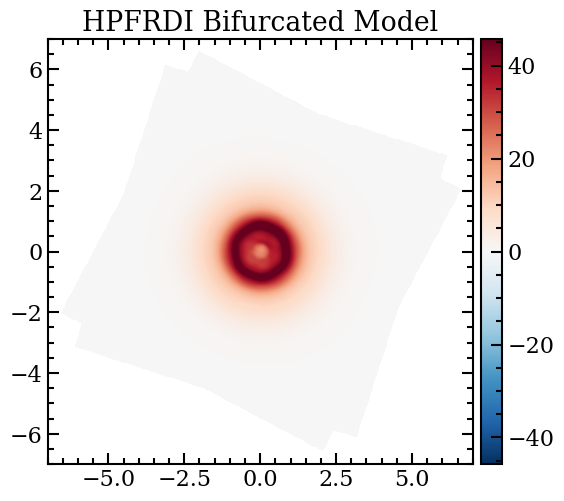

In [32]:
# HPFRDI reduction with the best-fit model
wdb.set_circumstellar_model(model_cube=forward_bifurcated_model)
wdb.hpfrdi_presets()
hpfrdi_bifurcated_model = wdb.run_rdi(forward_model=True)

# show only the HPFRDI results for the best-fit model
fig, ax, cbar = quick_implot(
    hpfrdi_bifurcated_model.im,
    cmap="RdBu_r",
    clim_perc=99,
    show=False,
    cbar=True,
    cbar_kwargs=dict(pad=0.015),
    panelsize=(6, 5),
    extent=rdi_reduc.extent,
    lims=[-7, 7],
    show_ticks=True,
)
ax.set_title("HPFRDI Bifurcated Model")
plt.show()


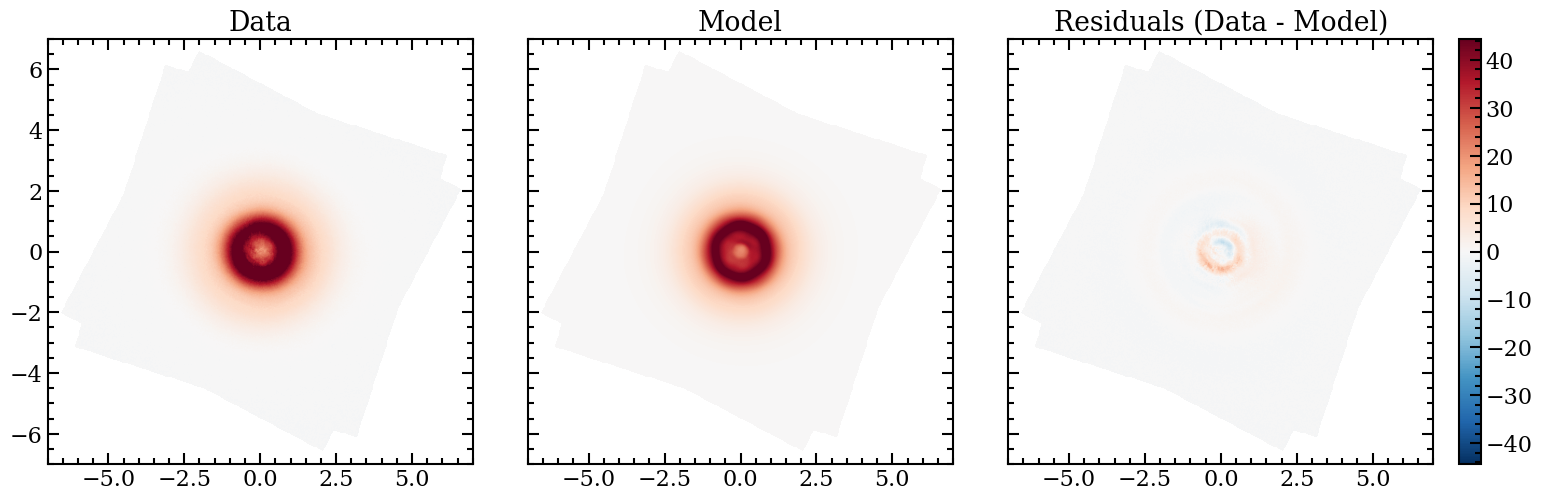

In [33]:
fig, axes, cbar = quick_implot(
    [rdi_reduc.im, hpfrdi_bifurcated_model.im, rdi_reduc.im - hpfrdi_bifurcated_model.im],
    cmap="RdBu_r",
    clim_perc=99,
    show=False,
    cbar=True,
    cbar_kwargs=dict(pad=0.015),
    panelsize=(6, 5),
    extent=rdi_reduc.extent,
    lims=[-7, 7],
    show_ticks=True,
)
for ax, title in zip(axes, ["Data", "Model", "Residuals (Data - Model)"]):
    ax.set_title(title)
plt.show()

Deconvolving Model RDI with 1000 iterations...


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

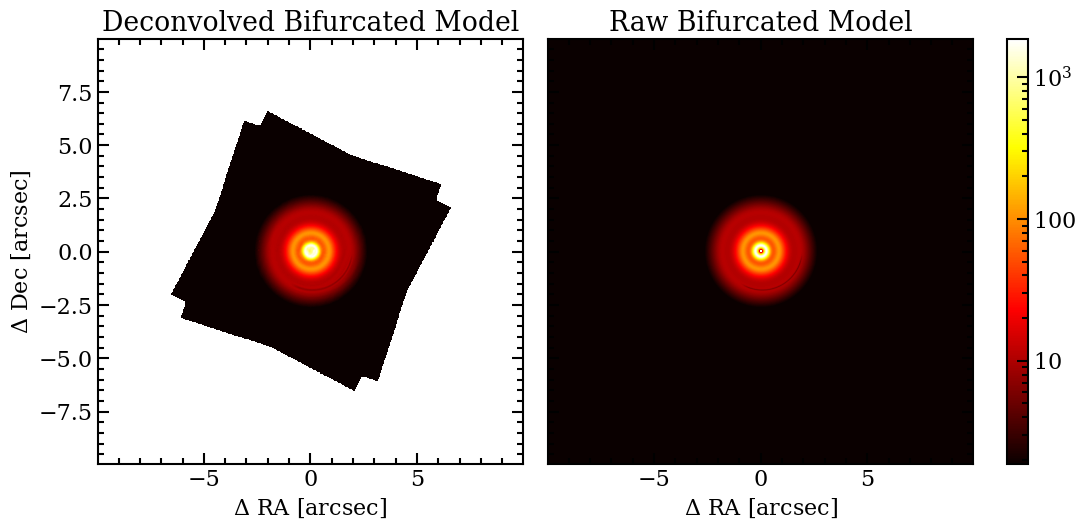

In [34]:

num_iter = 1000 

# Setup intermediate return iterations tracking
return_iters = np.concatenate([np.arange(1, 10), np.arange(10, num_iter + 1, 10)])

# recreate the exclude mask to prevent central artifacts from dominating
excl_mask = winnie.utils.px_size_to_ang_size(
    winnie.utils.dist_to_pt(wdb.c_star, wdb.nx, wdb.ny),
    wdb.pxscale
).value > 7

# 1. Deconvolve the Forward Modeled RDI image (hpfrdi_model)
print(f"Deconvolving Model RDI with {num_iter} iterations...")
manual_eps = 0.05 * np.nanmedian(np.abs(hpfrdi_bifurcated_model.rolls - np.nanmedian(hpfrdi_bifurcated_model.rolls)))
deconv_bifurcated_results = wdb.run_deconvolution(
    reduc_in=hpfrdi_bifurcated_model, 
    num_iter=num_iter, 
    epsilon=manual_eps, 
    return_iters=return_iters,
    excl_mask_in=excl_mask,
    init_from_reduc=True,
    save_products=True, 
    show_progress=True
)
# Extract the final deconvolved forward-modeled image
deconv_bifurcated_model = deconv_bifurcated_results[0].im

# 2. Plot and Compare: Deconvolved Bifurcated Model vs Raw Bifurcated Model
fig, axes, cbar = quick_implot(
    [deconv_bifurcated_model, bifurcated_raw_model],
    cmap='hot', 
    clim='0.001*99.99%, 99.99%',
    norm=mpl.colors.LogNorm,
    norm_kwargs=dict(clip=True),
    show=False, 
    cbar=True, 
    cbar_kwargs=dict(pad=0.03), 
    panelsize=(6, 5), 
    extent=rdi_reduc.extent, 
    show_ticks=True
)

labels = ['Deconvolved Bifurcated Model', 'Raw Bifurcated Model']
for i, ax in enumerate(axes):
    ax.set_title(labels[i])
    ax.set_xlabel(r'$\Delta$ RA [arcsec]')
    if i == 0:
        ax.set_ylabel(r'$\Delta$ Dec [arcsec]')

plt.show()


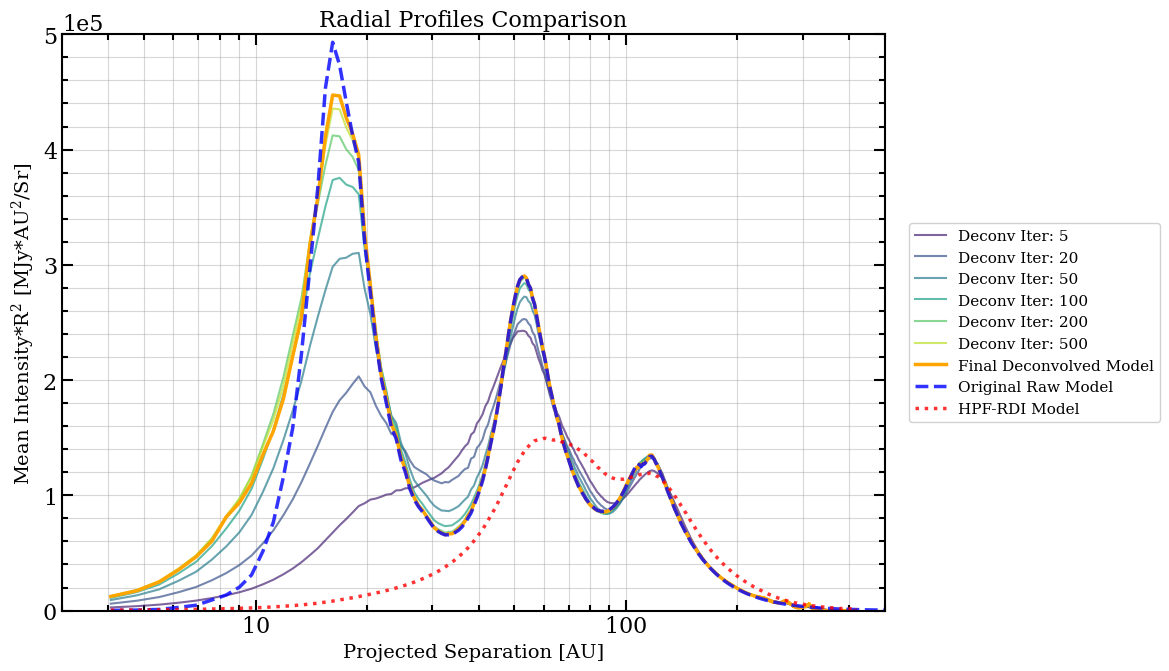

In [35]:
# Calculate radial profiles
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import winnie.utils

def simple_radial_profile(image, center, r_bins_pix):
    """
    Computes azimuthally-averaged radial profile.
    """
    y, x = np.indices(image.shape)
    r_pix = np.hypot(x - center[0], y - center[1])
    
    profile = np.zeros(len(r_bins_pix) - 1)
    for i in range(len(profile)):
        mask = (r_pix >= r_bins_pix[i]) & (r_pix < r_bins_pix[i+1])
        if np.any(mask):
            profile[i] = np.nanmean(image[mask])
        else:
            profile[i] = np.nan
    return profile

# Convert r_bins from AU to pixels to use on the images directly
r_bins_au = np.linspace(3, 500, 700)  

# The size of a single pixel in AU for calculating bin edges
# Extracting the raw `.value` strips the '1/pix' unit so winnie handles it cleanly 
pix_size_in_arcsec = wdb.pxscale.to('arcsec/pixel').value
pix_size_in_au = winnie.utils.ang_size_to_proj_sep(pix_size_in_arcsec, distance).value
r_bins_pix = r_bins_au / pix_size_in_au

# Calculate the centers of the bins in AU for plotting the x-axis
r_centers_au = (r_bins_au[:-1] + r_bins_au[1:]) / 2.
r_squared_au = r_centers_au**2

# Generate base profiles
profile_hpfrdi_model = simple_radial_profile(hpfrdi_bifurcated_model.im, wdb.c_star, r_bins_pix)
profile_deconv_bifurcated = simple_radial_profile(deconv_bifurcated_model, wdb.c_star, r_bins_pix)
profile_raw_model = simple_radial_profile(bifurcated_raw_model, wdb.c_star, r_bins_pix)

# Setup figure
plt.figure(figsize=(12, 7)) # slightly wider to fit legend outside

# Plot intermediate radial profiles from deconvolution
target_iters = [5, 20, 50, 100, 200, 500]  # Shared from your previous block
intermediate_cube = deconv_bifurcated_results[1]
colors = cm.viridis(np.linspace(0.1, 0.9, len(target_iters)))

for i, target in enumerate(target_iters):
    # Find the closest iteration match
    idx = np.argmin(np.abs(np.array(return_iters) - target))
    closest_iter = return_iters[idx]
    
    current_im = intermediate_cube[idx]
    if current_im.ndim == 3:
        current_im = np.nanmean(current_im, axis=0)
        
    # Generate profile for this iteration
    prof = simple_radial_profile(current_im, wdb.c_star, r_bins_pix)
    
    # Plot intermediate profile
    plt.plot(r_centers_au, prof * r_squared_au, 
             color=colors[i], linewidth=1.5, alpha=0.7, 
             label=f'Deconv Iter: {closest_iter}')

# Plot final models
plt.plot(r_centers_au, profile_deconv_bifurcated*r_squared_au, label='Final Deconvolved Model', color='orange', linewidth=2.5, alpha=1.0)
plt.plot(r_centers_au, profile_raw_model*r_squared_au, label='Original Raw Model', color='blue', linestyle='--', linewidth=2.5, alpha=0.8)
plt.plot(r_centers_au, profile_hpfrdi_model*r_squared_au, label='HPF-RDI Model', color='red', linestyle=':', linewidth=2.5, alpha=0.8)

plt.xlabel('Projected Separation [AU]', fontsize=14)
plt.ylabel(r'Mean Intensity*$R^2$ [MJy*$AU^2$/Sr]', fontsize=14)
plt.title('Radial Profiles Comparison', fontsize=16)

# Make legend more prominent and position outside plot box
plt.legend(fontsize=11, loc='center left', bbox_to_anchor=(1.02, 0.5), framealpha=0.9)

plt.xlim(3, 500)
plt.ylim(0, 5e5)  # Adjusted for better visibility of features
plt.xscale('log') # Log scale often helps if the range of separations is large

# Make y axis ticks in scientific notation for clarity
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

# Improve grid lines for easier reading
plt.grid(True, which="both", ls="-", alpha=0.5)

plt.tight_layout()
plt.show()

Optimal iteration found: 990 (Mean Fractional Error: 0.005146127976119)


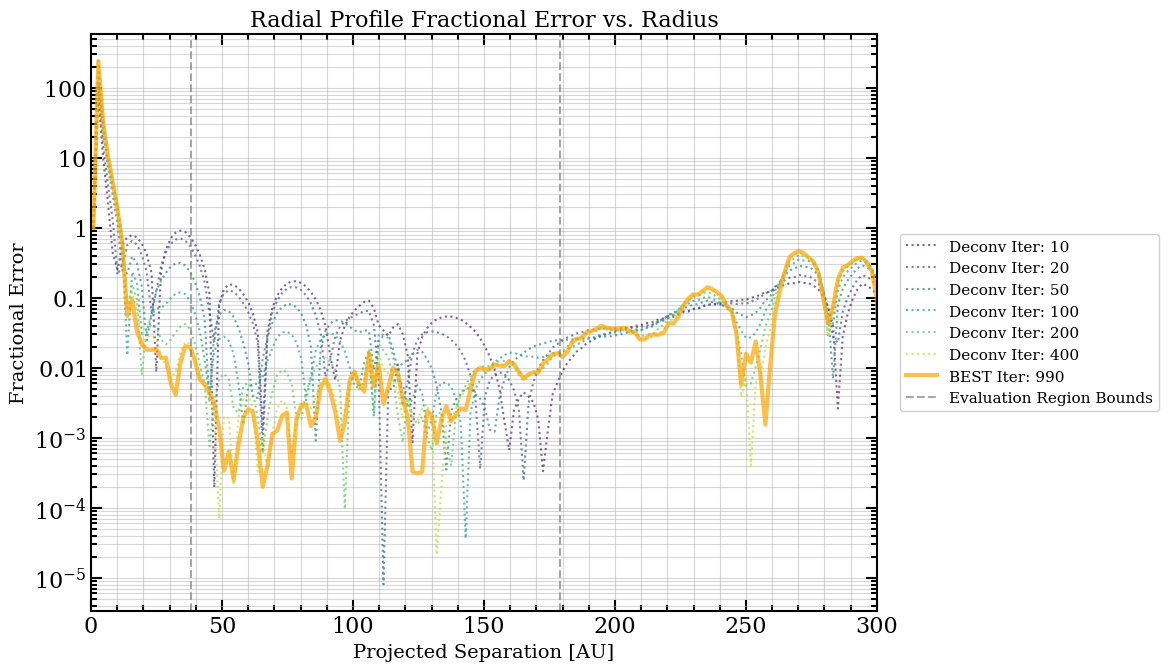

In [36]:
# Calculate radial profiles
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import winnie.utils

def convert_radial_profile(image, r_pix, r_bins_pix):
    """
    Computes azimuthally-averaged radial profile.
    Inputs:
    - image: 2D array of the image to profile
    - r_pix: 2D array of pixel radii from the star center (same shape as image)
    - r_bins_pix: 1D array of bin edges in pixels
    Output:
    - profile: 1D array of mean values in each radial bin
    """
    flat_img = image.ravel()
    flat_r = r_pix.ravel()
    
    # Handle NaNs in the image before binning
    nan_mask = np.isnan(flat_img)
    if np.any(nan_mask):
        flat_img = flat_img[~nan_mask]
        flat_r = flat_r[~nan_mask]
        
    # Map pixel radii to bin indices: bins[i-1] <= x < bins[i]
    bin_assignments = np.digitize(flat_r, r_bins_pix) - 1
    
    # Keep only the assignments that fall within our valid bin ranges
    valid = (bin_assignments >= 0) & (bin_assignments < len(r_bins_pix) - 1)
    flat_img = flat_img[valid]
    bin_assignments = bin_assignments[valid]
    
    # Calculate sums and counts per bin using bincount
    bin_sums = np.bincount(bin_assignments, weights=flat_img, minlength=len(r_bins_pix) - 1)
    bin_counts = np.bincount(bin_assignments, minlength=len(r_bins_pix) - 1)
    
    # Compute mean safely avoiding divide-by-zero warnings
    with np.errstate(divide='ignore', invalid='ignore'):
        profile = bin_sums / bin_counts
    profile[bin_counts == 0] = np.nan
    
    return profile

# Convert r_bins from pixels to AU for plotting the x-axis
r_bins_pix = np.arange(bifurcated_raw_model.shape[0]//2+1) # divide the image into annuli of 1 pixel width
pix_size_in_arcsec = wdb.pxscale.to('arcsec/pixel').value
pix_size_in_au = winnie.utils.ang_size_to_proj_sep(pix_size_in_arcsec, distance).value
r_centers_pix = (r_bins_pix[:-1] + r_bins_pix[1:]) / 2.
r_centers_au = r_centers_pix * pix_size_in_au

# =====================================================================
# PRE-COMPUTE COORDINATE GRID ONCE
# =====================================================================
y, x = np.indices(bifurcated_raw_model.shape)
r_pix = np.hypot(x - wdb.c_star[0], y - wdb.c_star[1])

# Generate base raw model profile using the new fast function
profile_raw_model = convert_radial_profile(bifurcated_raw_model, r_pix, r_bins_pix)

# =====================================================================
# Evaluate ALL iterations and CACHE profiles for plotting
# =====================================================================
intermediate_cube = deconv_bifurcated_results[1]
mean_fractional_errors = []
all_profiles = []  # Cache to store profiles and avoid recalculating for plots

# Define a radial mask to ignore the inner working angle and extreme outer empty space.
r_min_au = r_au_iwa  
r_max_au = 178.88
eval_mask = (r_centers_au > r_min_au) & (r_centers_au < r_max_au) 

for idx, iter_num in enumerate(return_iters):
    current_im = intermediate_cube[idx]
    if current_im.ndim == 3:
        current_im = np.nanmean(current_im, axis=0)
        
    # Calculate profile using the fast method
    prof = convert_radial_profile(current_im, r_pix, r_bins_pix)
    all_profiles.append(prof)
    
    # Calculate Fractional Error
    error_prof = np.abs(prof - profile_raw_model) / (np.abs(profile_raw_model) + 1e-12)
    
    # Calculate the mean fractional error ONLY across the valid disk region
    global_error = np.nanmean(error_prof[eval_mask])
    mean_fractional_errors.append(global_error)

mean_fractional_errors = np.array(mean_fractional_errors)

# Find the best iteration index
best_idx = np.nanargmin(mean_fractional_errors)
best_iter = return_iters[best_idx]
best_error = mean_fractional_errors[best_idx]

print(f"Optimal iteration found: {best_iter} (Mean Fractional Error: {best_error:.15f})")

# =====================================================================
# Plotting
# =====================================================================
plt.figure(figsize=(12, 7)) 

target_iters = [10, 20, 50, 100, 200, 400]
colors = cm.viridis(np.linspace(0.1, 0.9, len(target_iters)))

# Plot intermediate radial error profiles from cache
for i, target in enumerate(target_iters):
    idx = np.argmin(np.abs(np.array(return_iters) - target))
    closest_iter = return_iters[idx]
    
    # Zero computation here—just pulling data out of our cache list
    prof = all_profiles[idx]
    error_prof = np.abs(prof - profile_raw_model) / (np.abs(profile_raw_model) + 1e-12)
    
    plt.plot(r_centers_au, error_prof, color=colors[i], linewidth=1.5, alpha=0.7, linestyle=':', label=f'Deconv Iter: {closest_iter}')

# Plot the BEST iteration distinctly from cache
best_prof = all_profiles[best_idx]
best_error_prof = np.abs(best_prof - profile_raw_model) / (np.abs(profile_raw_model) + 1e-12)

plt.plot(r_centers_au, best_error_prof, color='orange', linewidth=3, alpha=0.7, linestyle='-', label=f'BEST Iter: {best_iter}')

# Mark the evaluation region used for the mean math
plt.axvline(r_min_au, color='gray', linestyle='--', alpha=0.7, label='Evaluation Region Bounds')
plt.axvline(r_max_au, color='gray', linestyle='--', alpha=0.7)

plt.xlabel('Projected Separation [AU]', fontsize=14)
plt.ylabel('Fractional Error', fontsize=14)
plt.title('Radial Profile Fractional Error vs. Radius', fontsize=16)

plt.yscale('log')
plt.legend(fontsize=11, loc='center left', bbox_to_anchor=(1.02, 0.5), framealpha=0.9)
plt.xlim(0, 300)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.tight_layout()
plt.show()

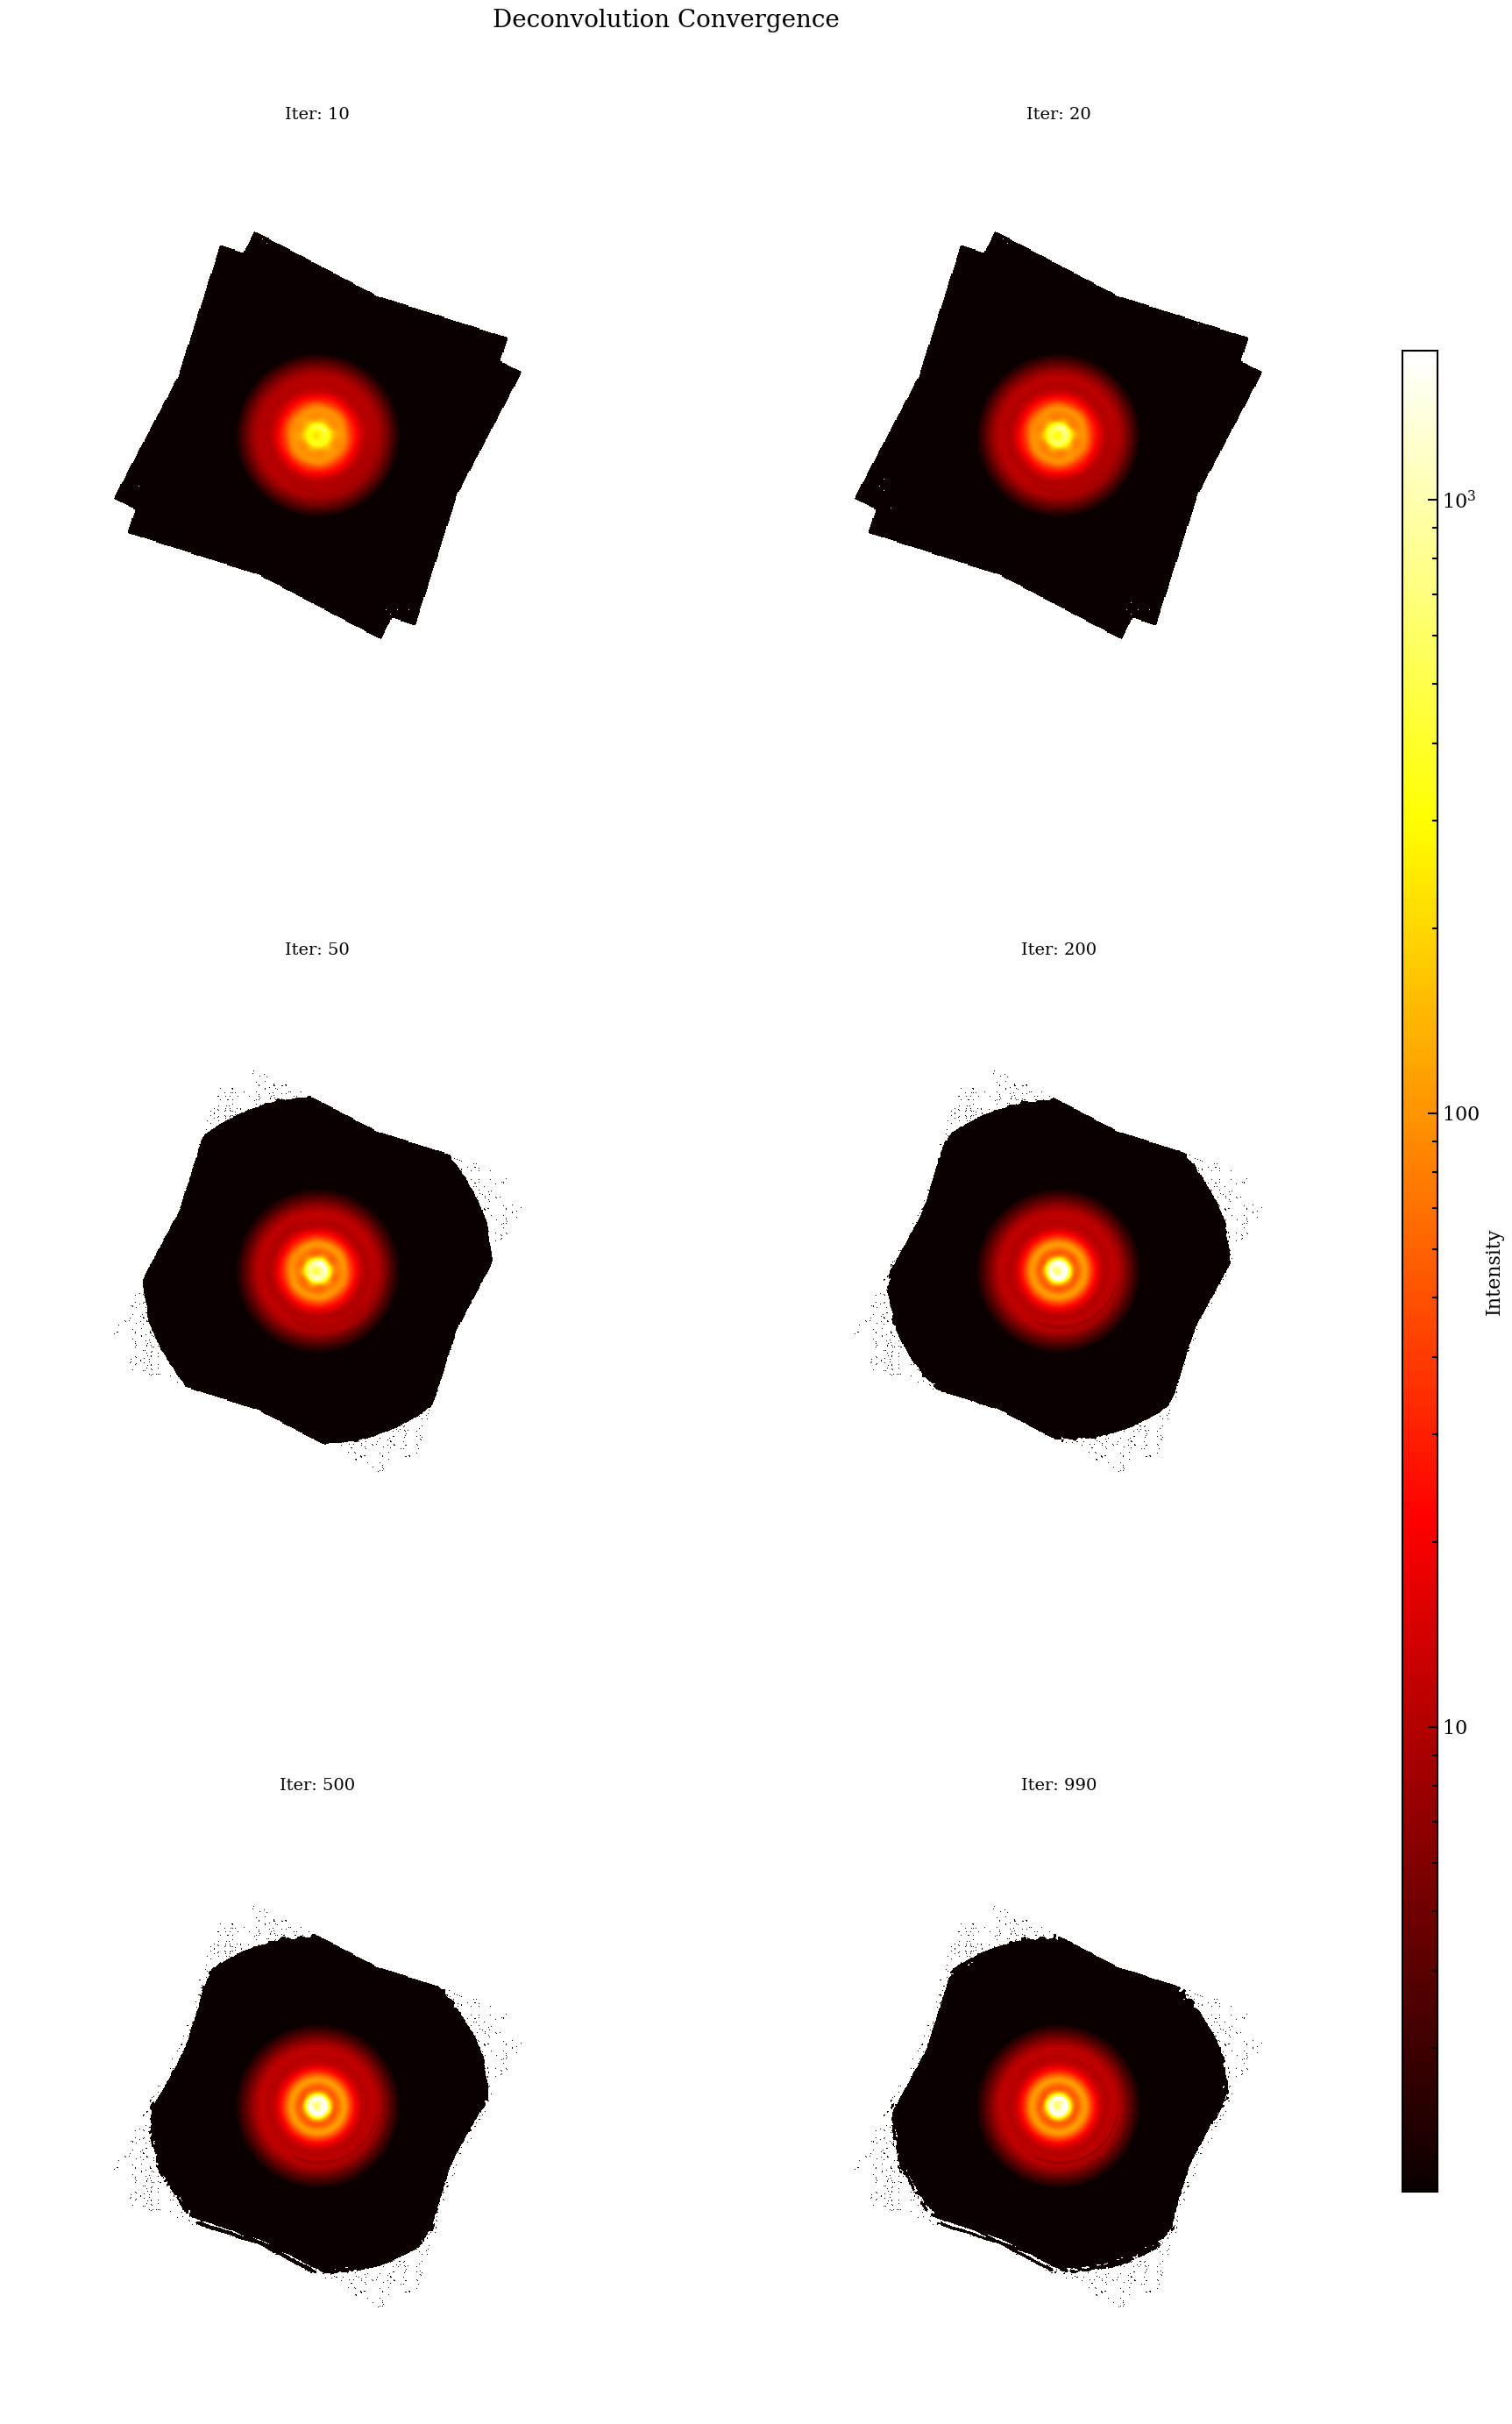

In [37]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# Define the target iterations you want to display (up to 6 for a 3x2 grid)
target_iters = [10, 20, 50, 200, 500, 990]  # Feel free to change these numbers
intermediate_cube = deconv_bifurcated_results[1]

# Pre-gather the images to compute global vmin/vmax
images_to_plot = []
closest_iters = []

for target in target_iters:
    idx = np.argmin(np.abs(np.array(return_iters) - target))
    closest_iters.append(return_iters[idx])
    
    current_im = intermediate_cube[idx]
    if current_im.ndim == 3:
        current_im = np.nanmean(current_im, axis=0)
    images_to_plot.append(current_im)

# Calculate global vmin and vmax for a shared color scale
global_vmax = np.nanpercentile([img for img in images_to_plot], 99.99)
global_vmin = 0.001*global_vmax

fig, axes = plt.subplots(3, 2, figsize=(20, 30))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < len(images_to_plot):
        current_im = images_to_plot[i]
        
        im = ax.imshow(
            current_im, 
            norm=mpl.colors.LogNorm(vmin=global_vmin, vmax=global_vmax), 
            cmap='hot',
            origin='lower'
        )
        ax.set_title(f'Iter: {closest_iters[i]}', fontsize=14)
    
    # Hide axes for all subplots (even the empty ones if target_iters < 6)
    ax.axis('off')

# Add a single shared colorbar for the entire figure
fig.subplots_adjust(bottom=0.05, top=0.95, right=0.9)
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
# The 'im' from the last plotted image is fine to use since they all share the same norm
fig.colorbar(im, cax=cbar_ax, label='Intensity')

plt.suptitle('Deconvolution Convergence', fontsize=20, y=0.98)
plt.show()

The best iteration number is 430 with an MAE of 2.86974e+02


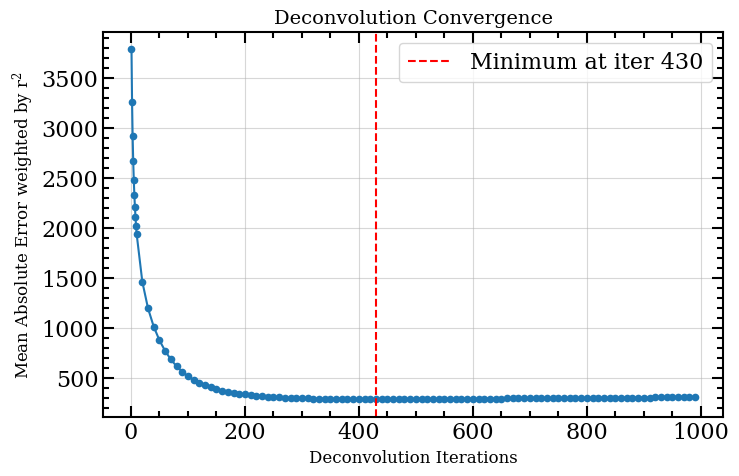

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define an evaluation mask to focus on the disk region
y, x = np.indices(best_raw_model.shape)
r_pix = np.hypot(x - wdb.c_star[0], y - wdb.c_star[1])
r_au = ang_size_to_proj_sep(px_size_to_ang_size(r_pix, wdb.pxscale), distance).value
eval_mask = (r_au >= r_au_iwa) & (r_au <= 178.88)

# Create an r^2 map in pixels to weight the errors
y_idx, x_idx = np.indices(bifurcated_raw_model.shape)
r_pix_sq = (x_idx - wdb.c_star[0])**2 + (y_idx - wdb.c_star[1])**2
errors = []
iterations = return_iters

# The second element contains the numpy array of intermediate images
intermediate_cube = deconv_bifurcated_results[1]

# 2. Iterate through the intermediate results to compute the differences
for i in range(len(iterations)):
    current_im = intermediate_cube[i]
    
    # If the intermediate results returned un-collapsed rolls (e.g. shape (2, 650, 650)), 
    # we need to average them across the first axis to get the 2D combined image.
    if current_im.ndim == 3:
        current_im = np.nanmean(current_im, axis=0)
    
    # Calculate r^2 weighted Mean Absolute Error within the mask
    diff = np.abs(current_im - bifurcated_raw_model)
    weighted_sq_err = r_pix_sq * diff
    mae = np.nanmean(weighted_sq_err[eval_mask])
    errors.append(mae)

errors = np.array(errors)

# 3. Find the minimum error
best_idx = np.argmin(errors)
best_iter = iterations[best_idx]
print(f"The best iteration number is {best_iter} with an MAE of {errors[best_idx]:.5e}")

# 4. Plot the error curve to visualize convergence behavior
plt.figure(figsize=(8, 5))
plt.plot(iterations[:-1], errors[:-1], marker='o', markersize=4, linestyle='-')
plt.axvline(best_iter, color='red', linestyle='--', label=f'Minimum at iter {best_iter}')
plt.xlabel("Deconvolution Iterations", fontsize=12)
plt.ylabel(r"Mean Absolute Error weighted by $r^2$", fontsize=12)
plt.title("Deconvolution Convergence", fontsize=14)
#plt.xscale('log') # Log scale often helps if iterations step up exponentially
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

# 5. Extract the formally "best" image
best_deconv_im = intermediate_cube[best_idx]
if best_deconv_im.ndim == 3:
    best_deconv_im = np.nanmean(best_deconv_im, axis=0)

### Add noise to the three-ring model (without bifurcation structure)
Test if the deconvolution process can still recover the input model.

In [39]:
# best 4644 | r01=16.11, r02=51.88, r03=112.82, flux1=1915.32, flux3=9.44, flux2=105.12
h0, ain, aout, g1, g2, wg1 = 0.035, 5, -5, 0.85, -0.2, 0.75
r0_vals = [16.11, 51.88, 112.82]
flux_vals = [1915.32, 105.12, 9.44]
pa_model = 0
incl_model = 0

# generate the raw model for the best-fit parameters
best_raw_model = np.zeros([650, 650])  # Start with an empty model
for i in range(3):
    best_raw_model += grater_2hg_disk_model(
        r0_vals[i],
        h0,
        ain,
        aout,
        pa_model,
        incl_model,
        g1,
        g2,
        wg1,
        cent=wdb.c_star,
        distance=distance,
        nx=wdb.nx,
        ny=wdb.ny,
        pxscale=wdb.pxscale,
        flux_max=flux_vals[i],
    )
    
# star brightness in the central pixel in MJy/sr
pixel_size = wdb.pxscale*u.pixel
pixel_size_sr = (pixel_size.to(u.rad))**2
print(f"Pixel size in steradians: {pixel_size_sr:.3e}")

# star brightness in Jy with given distance and stellar spectrum (see Photometry.ipynb)
# 0.82327 Jy for F200W;0.35116 Jy for F356W; 0.23643 Jy for F444W 
star_brightness_jy = 0.82327 * u.Jy
print(f"Star brightness in Jy: {star_brightness_jy:.3e}")

# Convert star brightness to MJy/sr
model_central_brightness_mjysr = (star_brightness_jy / pixel_size_sr).to(u.MJy/u.sr)
print(f"Central pixel brightness in the model in MJy/sr: {model_central_brightness_mjysr:.3e}")

# Add star brightness to the model, if the star's location is integral, add the value to the stellar pixel; if not, the star's brightness should be added across 4 closest pixels
model_central_brightness = model_central_brightness_mjysr.value
if wdb.c_star[0]%1 == 0 and wdb.c_star[1]%1 == 0:
    best_raw_model[int(wdb.c_star[1]), int(wdb.c_star[0])] += model_central_brightness
else:
    jvals = int(np.floor(wdb.c_star[0])), int(np.ceil(wdb.c_star[0]))
    ivals = int(np.floor(wdb.c_star[1])), int(np.ceil(wdb.c_star[1]))
    for j in jvals:
        for i in ivals:
            # Calculate the fraction of the star's brightness that should be added to this pixel based on the distance from the star's exact location
            j_fraction = 1 - abs(wdb.c_star[0] - j)
            i_fraction = 1 - abs(wdb.c_star[1] - i)
            fraction = j_fraction * i_fraction
            print(f"Adding {fraction:.2f} of the star's brightness to pixel ({i}, {j})")
            best_raw_model[i, j] += model_central_brightness * fraction

Pixel size in steradians: 2.213e-14 rad2
Star brightness in Jy: 8.233e-01 Jy
Central pixel brightness in the model in MJy/sr: 3.720e+07 MJy / sr
Adding 0.25 of the star's brightness to pixel (324, 324)
Adding 0.25 of the star's brightness to pixel (325, 324)
Adding 0.25 of the star's brightness to pixel (324, 325)
Adding 0.25 of the star's brightness to pixel (325, 325)


Number of non-NaN pixels in the model error cube: 204800


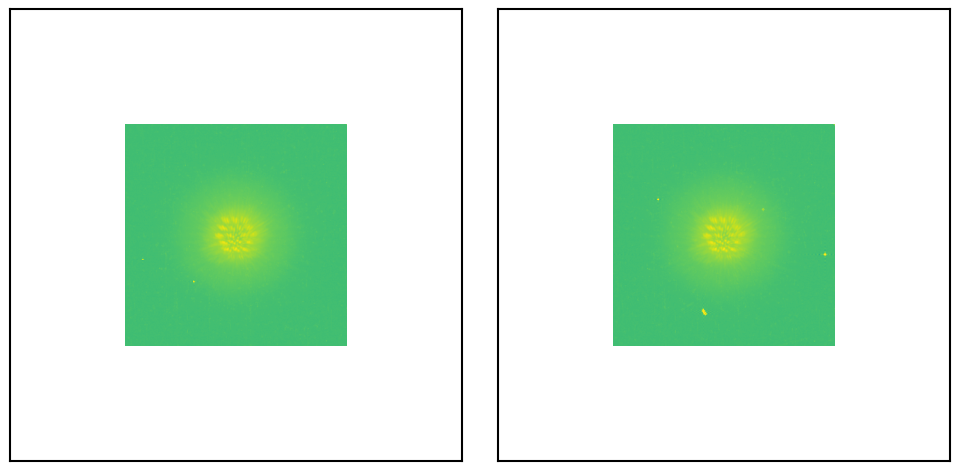

In [40]:
# check not-nan number of pixels in the model error cube
realdata_errs = wdb.errcube_sci
print(f"Number of non-NaN pixels in the model error cube: {np.count_nonzero(~np.isnan(realdata_errs))}")
# plot the error cube to visually confirm it's mostly NaN except for a few pixels
fig, ax = quick_implot(realdata_errs, norm=mpl.colors.LogNorm, norm_kwargs=dict(clip=True), clim='0.001*99.99%, 99.99%', show=False)
plt.show()

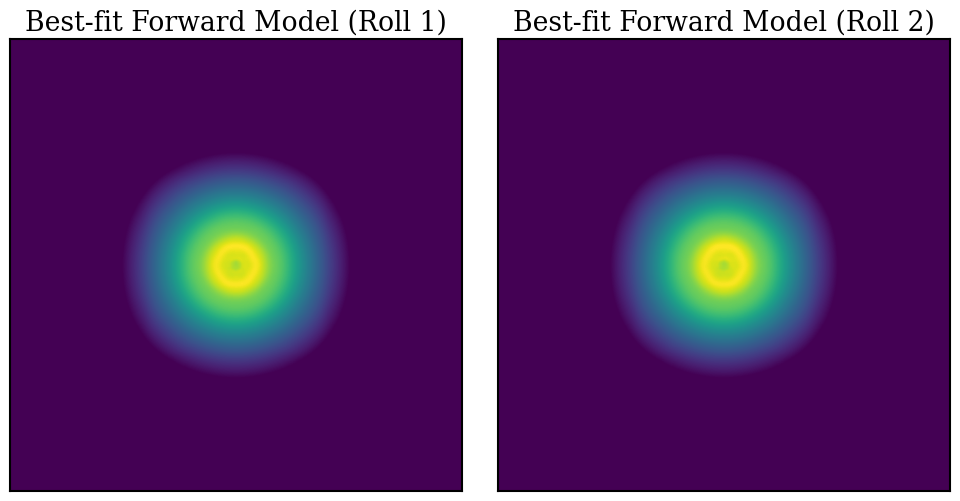

In [41]:
# forward model
forward_best_model = wdb.convolver.convolve_model(best_raw_model, wdb.pxscale, wdb.c_star)
fig, axes = quick_implot(forward_best_model, norm=mpl.colors.LogNorm, norm_kwargs=dict(clip=True), clim='0.001*99.99%, 99.99%', show=False)

# Iterate over the returned axes if there are multiple rolls
for i, ax in enumerate(axes):
    ax.set_title(f"Best-fit Forward Model (Roll {i+1})")
plt.show()

In [42]:
# Add noise to the forward model
rng = np.random.default_rng(39)   # Set seed for reproducibility
rand_errs = rng.normal(scale=wdb.errcube_sci)
forward_best_model_noisy = forward_best_model + rand_errs

JWST_NIRCAM_NRCA2_F200W_MASKRND_MASK335R_SUB320A335R
Science data:   2 exposures of shape (650,650)
Reference data: 241 exposures of shape (650,650)

RDI Settings:
Mode: HPFRDI (Winnie)
'opt_smoothing_fn': <function high_pass_filter_sequence at 0x7e2beef36520>
'opt_smoothing_kwargs': {'filtersize': 1.0994602853484432}
Extension for output files: 'hpfrdi_psfsub'
1 optimization zone(s)
1 subtraction zone(s)


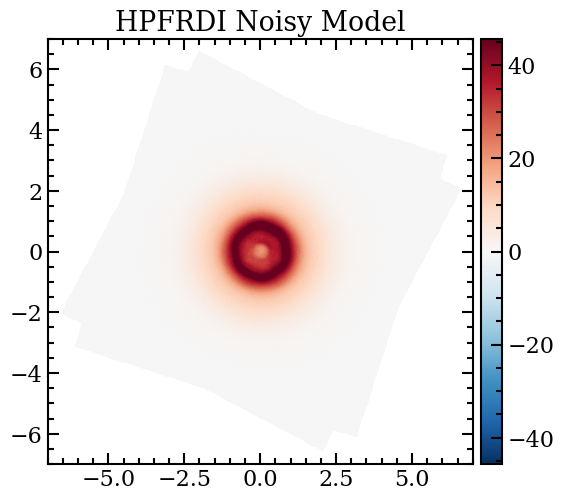

In [43]:
# HPFRDI reduction with the best-fit model
wdb.set_circumstellar_model(model_cube=forward_best_model_noisy)
wdb.hpfrdi_presets()
hpfrdi_model = wdb.run_rdi(forward_model=True)

# show only the HPFRDI results for the best-fit model
fig, ax, cbar = quick_implot(
    hpfrdi_model.im,
    cmap="RdBu_r",
    clim_perc=99,
    show=False,
    cbar=True,
    cbar_kwargs=dict(pad=0.015),
    panelsize=(6, 5),
    extent=rdi_reduc.extent,
    lims=[-7, 7],
    show_ticks=True,
)
ax.set_title("HPFRDI Noisy Model")
plt.show()

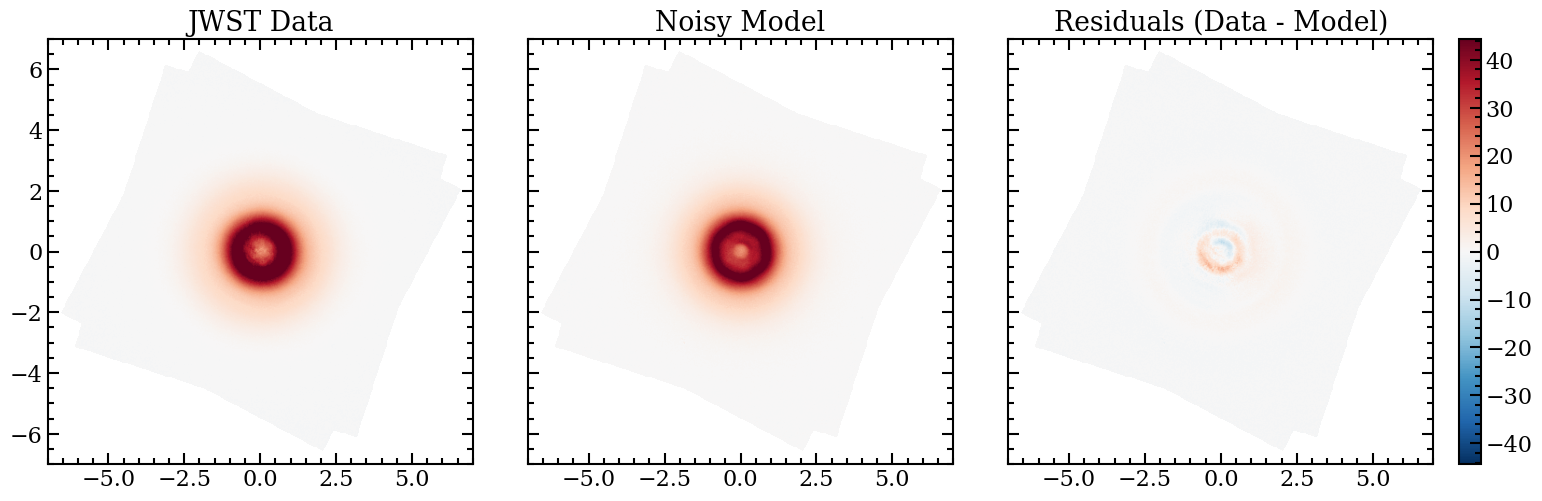

In [44]:
fig, axes, cbar = quick_implot(
    [rdi_reduc.im, hpfrdi_model.im, rdi_reduc.im - hpfrdi_model.im],
    cmap="RdBu_r",
    clim_perc=99,
    show=False,
    cbar=True,
    cbar_kwargs=dict(pad=0.015),
    panelsize=(6, 5),
    extent=rdi_reduc.extent,
    lims=[-7, 7],
    show_ticks=True,
)
for ax, title in zip(axes, ["JWST Data", "Noisy Model", "Residuals (Data - Model)"]):
    ax.set_title(title)
plt.show()

Deconvolving Model RDI with 500 iterations...


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

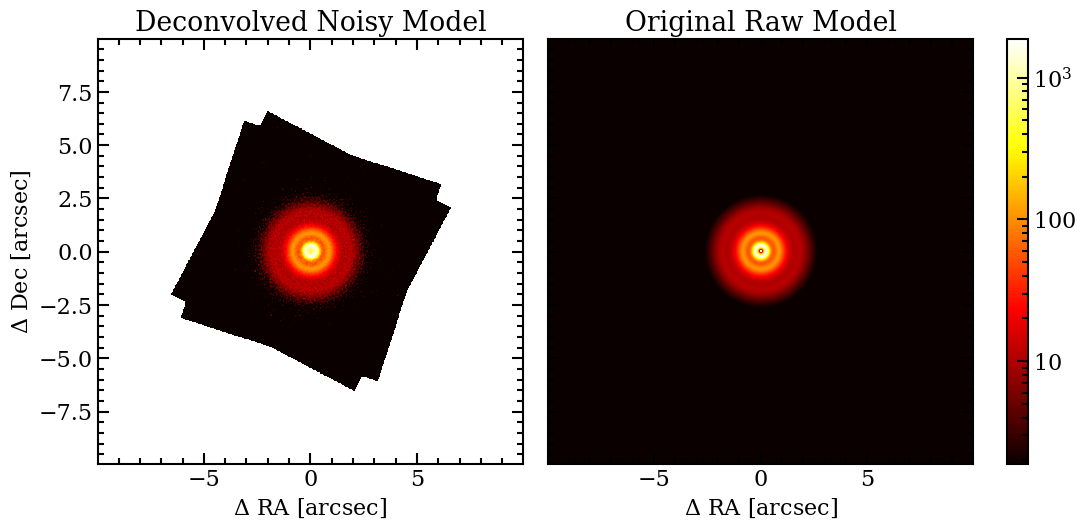

In [45]:
num_iter = 500 

# Setup intermediate return iterations tracking
return_iters = np.concatenate([np.arange(1, 10), np.arange(10, num_iter + 1, 10)])

# recreate the exclude mask to prevent central artifacts from dominating
excl_mask = winnie.utils.px_size_to_ang_size(
    winnie.utils.dist_to_pt(wdb.c_star, wdb.nx, wdb.ny),
    wdb.pxscale
).value > 7

# 1. Deconvolve the Forward Modeled RDI image (hpfrdi_model)
print(f"Deconvolving Model RDI with {num_iter} iterations...")
manual_eps = 0.05 * np.nanmedian(np.abs(hpfrdi_model.rolls - np.nanmedian(hpfrdi_model.rolls)))
deconv_fm_results = wdb.run_deconvolution(
    reduc_in=hpfrdi_model,
    num_iter=num_iter,
    epsilon=manual_eps,
    return_iters=return_iters,
    excl_mask_in=excl_mask,
    init_from_reduc=True,
    save_products=True,
    show_progress=True
)
# Extract the final deconvolved forward-modeled image
deconv_fm_im = deconv_fm_results[0].im

# 2. Plot and Compare: Data vs Deconvolved Model vs Original Raw Model
# Using log scaling and a "hot" colormap common for deconvolution visualizations
fig, axes, cbar = quick_implot(
    [deconv_fm_im, best_raw_model], 
    cmap='hot', 
    clim='0.001*99.99%, 99.99%',
    norm=mpl.colors.LogNorm,
    norm_kwargs=dict(clip=True),
    show=False, 
    cbar=True, 
    cbar_kwargs=dict(pad=0.03), 
    panelsize=(6, 5), 
    extent=rdi_reduc.extent, 
    show_ticks=True
)

labels = ['Deconvolved Noisy Model', 'Original Raw Model']
for i, ax in enumerate(axes):
    ax.set_title(labels[i])
    ax.set_xlabel(r'$\Delta$ RA [arcsec]')
    if i == 0:
        ax.set_ylabel(r'$\Delta$ Dec [arcsec]')

plt.show()

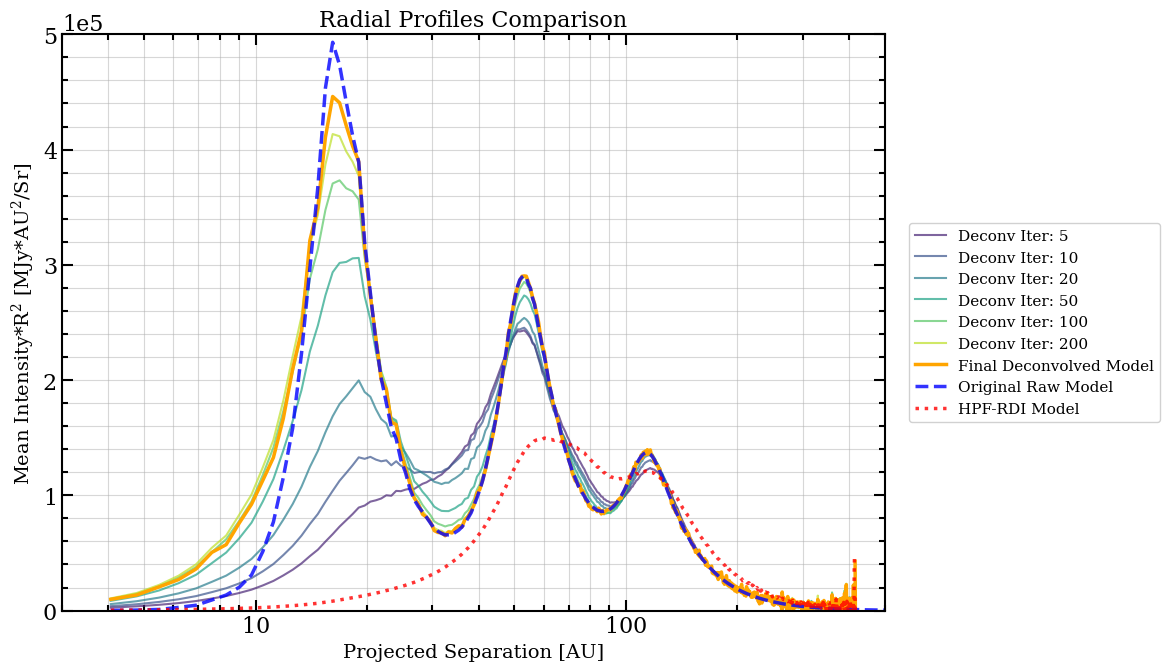

In [46]:
# Calculate radial profiles
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import winnie.utils

def simple_radial_profile(image, center, r_bins_pix):
    """
    Computes azimuthally-averaged radial profile.
    """
    y, x = np.indices(image.shape)
    r_pix = np.hypot(x - center[0], y - center[1])
    
    profile = np.zeros(len(r_bins_pix) - 1)
    for i in range(len(profile)):
        mask = (r_pix >= r_bins_pix[i]) & (r_pix < r_bins_pix[i+1])
        if np.any(mask):
            profile[i] = np.nanmean(image[mask])
        else:
            profile[i] = np.nan
    return profile

# Convert r_bins from AU to pixels to use on the images directly
r_bins_au = np.linspace(3, 500, 700)

# The size of a single pixel in AU for calculating bin edges
# Extracting the raw `.value` strips the '1/pix' unit so winnie handles it cleanly 
pix_size_in_arcsec = wdb.pxscale.to('arcsec/pixel').value
pix_size_in_au = winnie.utils.ang_size_to_proj_sep(pix_size_in_arcsec, distance).value
r_bins_pix = r_bins_au / pix_size_in_au

# Calculate the centers of the bins in AU for plotting the x-axis
r_centers_au = (r_bins_au[:-1] + r_bins_au[1:]) / 2.
r_squared_au = r_centers_au**2

# Generate base profiles
profile_hpfrdi_model = simple_radial_profile(hpfrdi_model.im, wdb.c_star, r_bins_pix)
profile_deconv = simple_radial_profile(deconv_fm_im, wdb.c_star, r_bins_pix)
profile_raw_model = simple_radial_profile(best_raw_model, wdb.c_star, r_bins_pix)

# Setup figure
plt.figure(figsize=(12, 7)) # slightly wider to fit legend outside

# Plot intermediate radial profiles from deconvolution
target_iters = [5, 10, 20, 50, 100, 200]  # Shared from your previous block
intermediate_cube = deconv_fm_results[1]
colors = cm.viridis(np.linspace(0.1, 0.9, len(target_iters)))

for i, target in enumerate(target_iters):
    # Find the closest iteration match
    idx = np.argmin(np.abs(np.array(return_iters) - target))
    closest_iter = return_iters[idx]
    
    current_im = intermediate_cube[idx]
    if current_im.ndim == 3:
        current_im = np.nanmean(current_im, axis=0)
        
    # Generate profile for this iteration
    prof = simple_radial_profile(current_im, wdb.c_star, r_bins_pix)
    
    # Plot intermediate profile
    plt.plot(r_centers_au, prof * r_squared_au, 
             color=colors[i], linewidth=1.5, alpha=0.7, 
             label=f'Deconv Iter: {closest_iter}')

# Plot final models
plt.plot(r_centers_au, profile_deconv*r_squared_au, label='Final Deconvolved Model', color='orange', linewidth=2.5, alpha=1.0)
plt.plot(r_centers_au, profile_raw_model*r_squared_au, label='Original Raw Model', color='blue', linestyle='--', linewidth=2.5, alpha=0.8)
plt.plot(r_centers_au, profile_hpfrdi_model*r_squared_au, label='HPF-RDI Model', color='red', linestyle=':', linewidth=2.5, alpha=0.8)

plt.xlabel('Projected Separation [AU]', fontsize=14)
plt.ylabel(r'Mean Intensity*$R^2$ [MJy*$AU^2$/Sr]', fontsize=14)
plt.title('Radial Profiles Comparison', fontsize=16)

# Make legend more prominent and position outside plot box
plt.legend(fontsize=11, loc='center left', bbox_to_anchor=(1.02, 0.5), framealpha=0.9)

plt.xscale('log')
plt.xlim(3, 500)
plt.ylim(0, 5e5)

# Make y axis ticks in scientific notation for clarity
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

# Improve grid lines for easier reading
plt.grid(True, which="both", ls="-", alpha=0.5)

plt.tight_layout()
plt.show()

Optimal iteration found: 220 (Mean Fractional Error: 0.008223071468199)


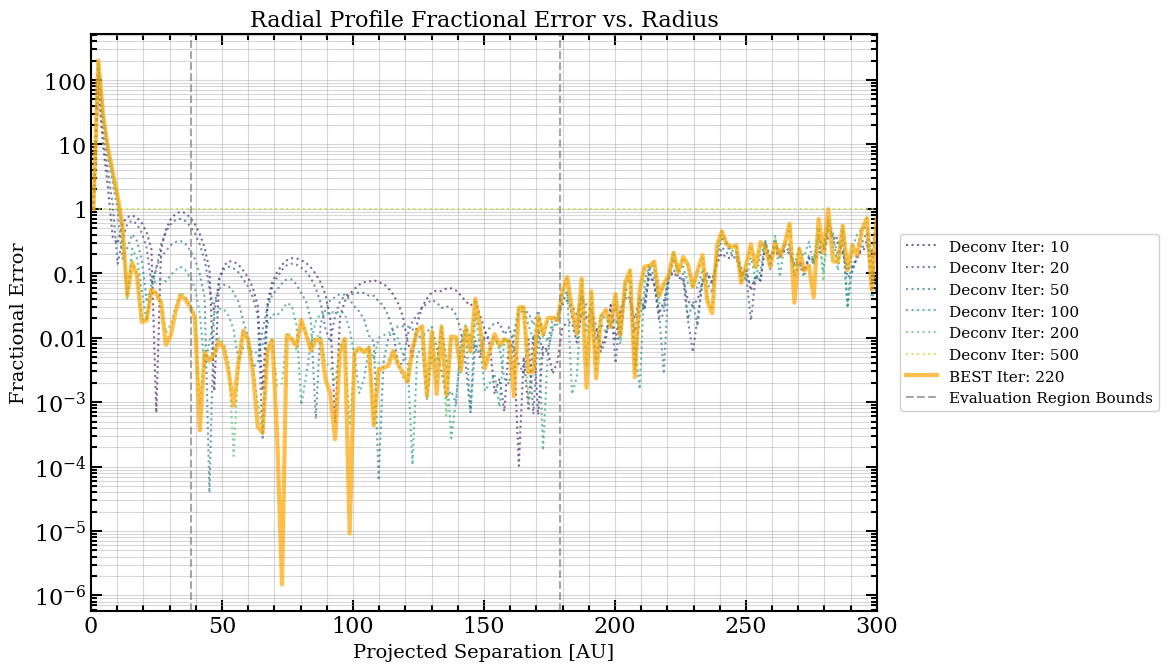

In [47]:
# Calculate radial profiles
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import winnie.utils

def convert_radial_profile(image, r_pix, r_bins_pix):
    """
    Computes azimuthally-averaged radial profile.
    Inputs:
    - image: 2D array of the image to profile
    - r_pix: 2D array of pixel radii from the star center (same shape as image)
    - r_bins_pix: 1D array of bin edges in pixels
    Output:
    - profile: 1D array of mean values in each radial bin
    """
    flat_img = image.ravel()
    flat_r = r_pix.ravel()
    
    # Handle NaNs in the image before binning
    nan_mask = np.isnan(flat_img)
    if np.any(nan_mask):
        flat_img = flat_img[~nan_mask]
        flat_r = flat_r[~nan_mask]
        
    # Map pixel radii to bin indices: bins[i-1] <= x < bins[i]
    bin_assignments = np.digitize(flat_r, r_bins_pix) - 1
    
    # Keep only the assignments that fall within our valid bin ranges
    valid = (bin_assignments >= 0) & (bin_assignments < len(r_bins_pix) - 1)
    flat_img = flat_img[valid]
    bin_assignments = bin_assignments[valid]
    
    # Calculate sums and counts per bin using bincount
    bin_sums = np.bincount(bin_assignments, weights=flat_img, minlength=len(r_bins_pix) - 1)
    bin_counts = np.bincount(bin_assignments, minlength=len(r_bins_pix) - 1)
    
    # Compute mean safely avoiding divide-by-zero warnings
    with np.errstate(divide='ignore', invalid='ignore'):
        profile = bin_sums / bin_counts
    profile[bin_counts == 0] = np.nan
    
    return profile

# Convert r_bins from pixels to AU for plotting the x-axis
r_bins_pix = np.arange(best_raw_model.shape[0]//2+1) # divide the image into annuli of 1 pixel width
pix_size_in_arcsec = wdb.pxscale.to('arcsec/pixel').value
pix_size_in_au = winnie.utils.ang_size_to_proj_sep(pix_size_in_arcsec, distance).value
r_centers_pix = (r_bins_pix[:-1] + r_bins_pix[1:]) / 2.
r_centers_au = r_centers_pix * pix_size_in_au

# =====================================================================
# PRE-COMPUTE COORDINATE GRID ONCE
# =====================================================================
y, x = np.indices(best_raw_model.shape)
r_pix = np.hypot(x - wdb.c_star[0], y - wdb.c_star[1])

# Generate base raw model profile using the new fast function
profile_raw_model = convert_radial_profile(best_raw_model, r_pix, r_bins_pix)

# =====================================================================
# Evaluate ALL iterations and CACHE profiles for plotting
# =====================================================================
intermediate_cube = deconv_fm_results[1]
mean_fractional_errors = []
all_profiles = []  # Cache to store profiles and avoid recalculating for plots

# Define a radial mask to ignore the inner working angle and extreme outer empty space.
r_min_au = r_au_iwa  
r_max_au = 178.88
eval_mask = (r_centers_au > r_min_au) & (r_centers_au < r_max_au) 

for idx, iter_num in enumerate(return_iters):
    current_im = intermediate_cube[idx]
    if current_im.ndim == 3:
        current_im = np.nanmean(current_im, axis=0)
        
    # Calculate profile using the fast method
    prof = convert_radial_profile(current_im, r_pix, r_bins_pix)
    all_profiles.append(prof)
    
    # Calculate Fractional Error
    error_prof = np.abs(prof - profile_raw_model) / (np.abs(profile_raw_model) + 1e-12)
    
    # Calculate the mean fractional error ONLY across the valid disk region
    global_error = np.nanmean(error_prof[eval_mask])
    mean_fractional_errors.append(global_error)

mean_fractional_errors = np.array(mean_fractional_errors)

# Find the best iteration index
best_idx = np.nanargmin(mean_fractional_errors)
best_iter = return_iters[best_idx]
best_error = mean_fractional_errors[best_idx]

print(f"Optimal iteration found: {best_iter} (Mean Fractional Error: {best_error:.15f})")

# =====================================================================
# Plotting
# =====================================================================
plt.figure(figsize=(12, 7)) 

target_iters = [10, 20, 50, 100, 200, 500]
colors = cm.viridis(np.linspace(0.1, 0.9, len(target_iters)))

# Plot intermediate radial error profiles from cache
for i, target in enumerate(target_iters):
    idx = np.argmin(np.abs(np.array(return_iters) - target))
    closest_iter = return_iters[idx]
    
    # Zero computation here—just pulling data out of our cache list
    prof = all_profiles[idx]
    error_prof = np.abs(prof - profile_raw_model) / (np.abs(profile_raw_model) + 1e-12)
    
    plt.plot(r_centers_au, error_prof, color=colors[i], linewidth=1.5, alpha=0.7, linestyle=':', label=f'Deconv Iter: {closest_iter}')

# Plot the BEST iteration distinctly from cache
best_prof = all_profiles[best_idx]
best_error_prof = np.abs(best_prof - profile_raw_model) / (np.abs(profile_raw_model) + 1e-12)

plt.plot(r_centers_au, best_error_prof, color='orange', linewidth=3, alpha=0.7, linestyle='-', label=f'BEST Iter: {best_iter}')

# Mark the evaluation region used for the mean math
plt.axvline(r_min_au, color='gray', linestyle='--', alpha=0.7, label='Evaluation Region Bounds')
plt.axvline(r_max_au, color='gray', linestyle='--', alpha=0.7)

plt.xlabel('Projected Separation [AU]', fontsize=14)
plt.ylabel('Fractional Error', fontsize=14)
plt.title('Radial Profile Fractional Error vs. Radius', fontsize=16)

plt.yscale('log')
plt.legend(fontsize=11, loc='center left', bbox_to_anchor=(1.02, 0.5), framealpha=0.9)
plt.xlim(0, 300)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.tight_layout()
plt.show()

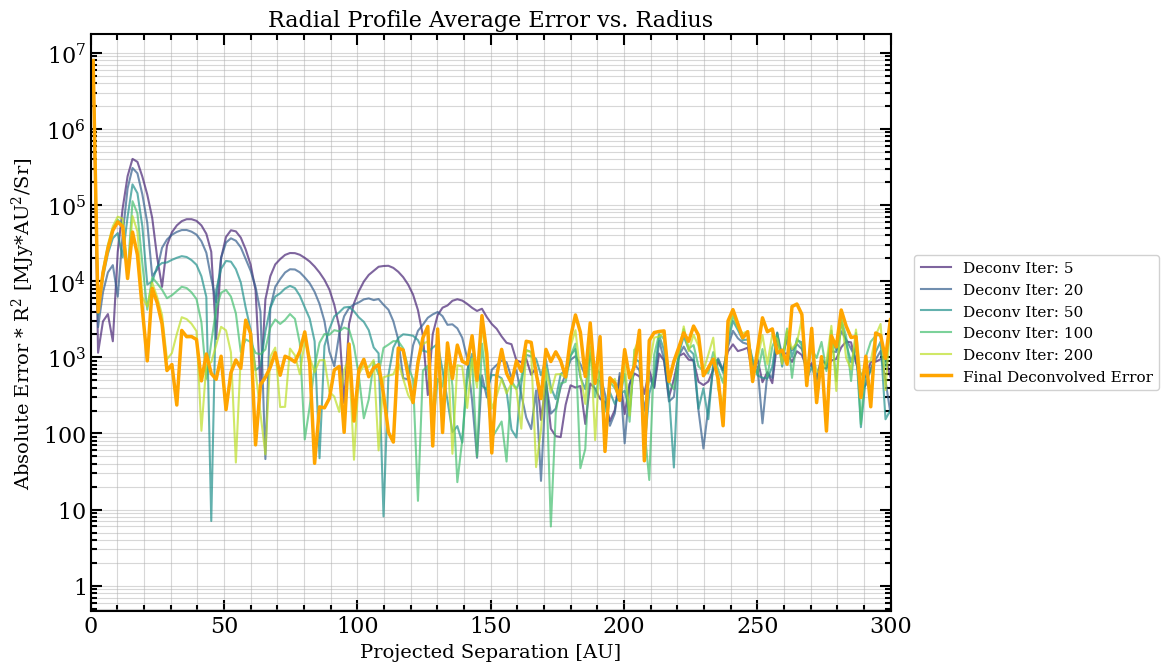

In [48]:
# Calculate radial profiles
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import winnie.utils

def simple_radial_profile(image, center, r_bins_pix):
    """
    Computes azimuthally-averaged radial profile.
    """
    y, x = np.indices(image.shape)
    r_pix = np.hypot(x - center[0], y - center[1])
    
    profile = np.zeros(len(r_bins_pix) - 1)
    for i in range(len(profile)):
        mask = (r_pix >= r_bins_pix[i]) & (r_pix < r_bins_pix[i+1])
        if np.any(mask):
            profile[i] = np.nanmean(image[mask])
        else:
            profile[i] = np.nan
    return profile

# Convert r_bins from pixels to AU for plotting the x-axis
r_bins_pix = np.arange(best_raw_model.shape[0]//2+1) # divide the image into annuli of 1 pixel width
pix_size_in_arcsec = wdb.pxscale.to('arcsec/pixel').value
pix_size_in_au = winnie.utils.ang_size_to_proj_sep(pix_size_in_arcsec, distance).value
r_centers_pix = (r_bins_pix[:-1] + r_bins_pix[1:]) / 2.
r_centers_au = r_centers_pix * pix_size_in_au
r_squared_au = r_centers_au**2

# Generate base profiles
# profile_hpfrdi_model = simple_radial_profile(hpfrdi_model.im, wdb.c_star, r_bins_pix)
profile_deconv = simple_radial_profile(deconv_fm_im, wdb.c_star, r_bins_pix)
profile_raw_model = simple_radial_profile(best_raw_model, wdb.c_star, r_bins_pix)

# Setup figure
plt.figure(figsize=(12, 7)) # slightly wider to fit legend outside

# Plot intermediate radial error profiles from deconvolution
target_iters = [5, 20, 50, 100, 200]  # Shared from your previous block
intermediate_cube = deconv_fm_results[1]
colors = cm.viridis(np.linspace(0.1, 0.9, len(target_iters)))

for i, target in enumerate(target_iters):
    # Find the closest iteration match
    idx = np.argmin(np.abs(np.array(return_iters) - target))
    closest_iter = return_iters[idx]
    
    current_im = intermediate_cube[idx]
    if current_im.ndim == 3:
        current_im = np.nanmean(current_im, axis=0)
        
    # Generate profile for this iteration
    prof = simple_radial_profile(current_im, wdb.c_star, r_bins_pix)
    
    # Calculate absolute error against the original raw model
    error_prof = np.abs(prof - profile_raw_model)
    
    # Plot intermediate error profile
    plt.plot(r_centers_au, error_prof * r_squared_au, 
             color=colors[i], linewidth=1.5, alpha=0.7, 
             label=f'Deconv Iter: {closest_iter}')

# Plot final model error
final_error = np.abs(profile_deconv - profile_raw_model)
plt.plot(r_centers_au, final_error * r_squared_au, label='Final Deconvolved Error', color='orange', linewidth=2.5, alpha=1.0)

plt.xlabel('Projected Separation [AU]', fontsize=14)
plt.ylabel(r'Absolute Error * $R^2$ [MJy*$AU^2$/Sr]', fontsize=14)
plt.title('Radial Profile Average Error vs. Radius', fontsize=16)

# Use logarithmic scale on the y-axis
plt.yscale('log')

# Make legend more prominent and position outside plot box
plt.legend(fontsize=11, loc='center left', bbox_to_anchor=(1.02, 0.5), framealpha=0.9)

plt.xlim(0, 300)
# plt.ylim() can be adjusted manually here if needed for log scale (e.g., plt.ylim(1e2, 1e6))

# Improve grid lines for easier reading
plt.grid(True, which="both", ls="-", alpha=0.5)

plt.tight_layout()
plt.show()

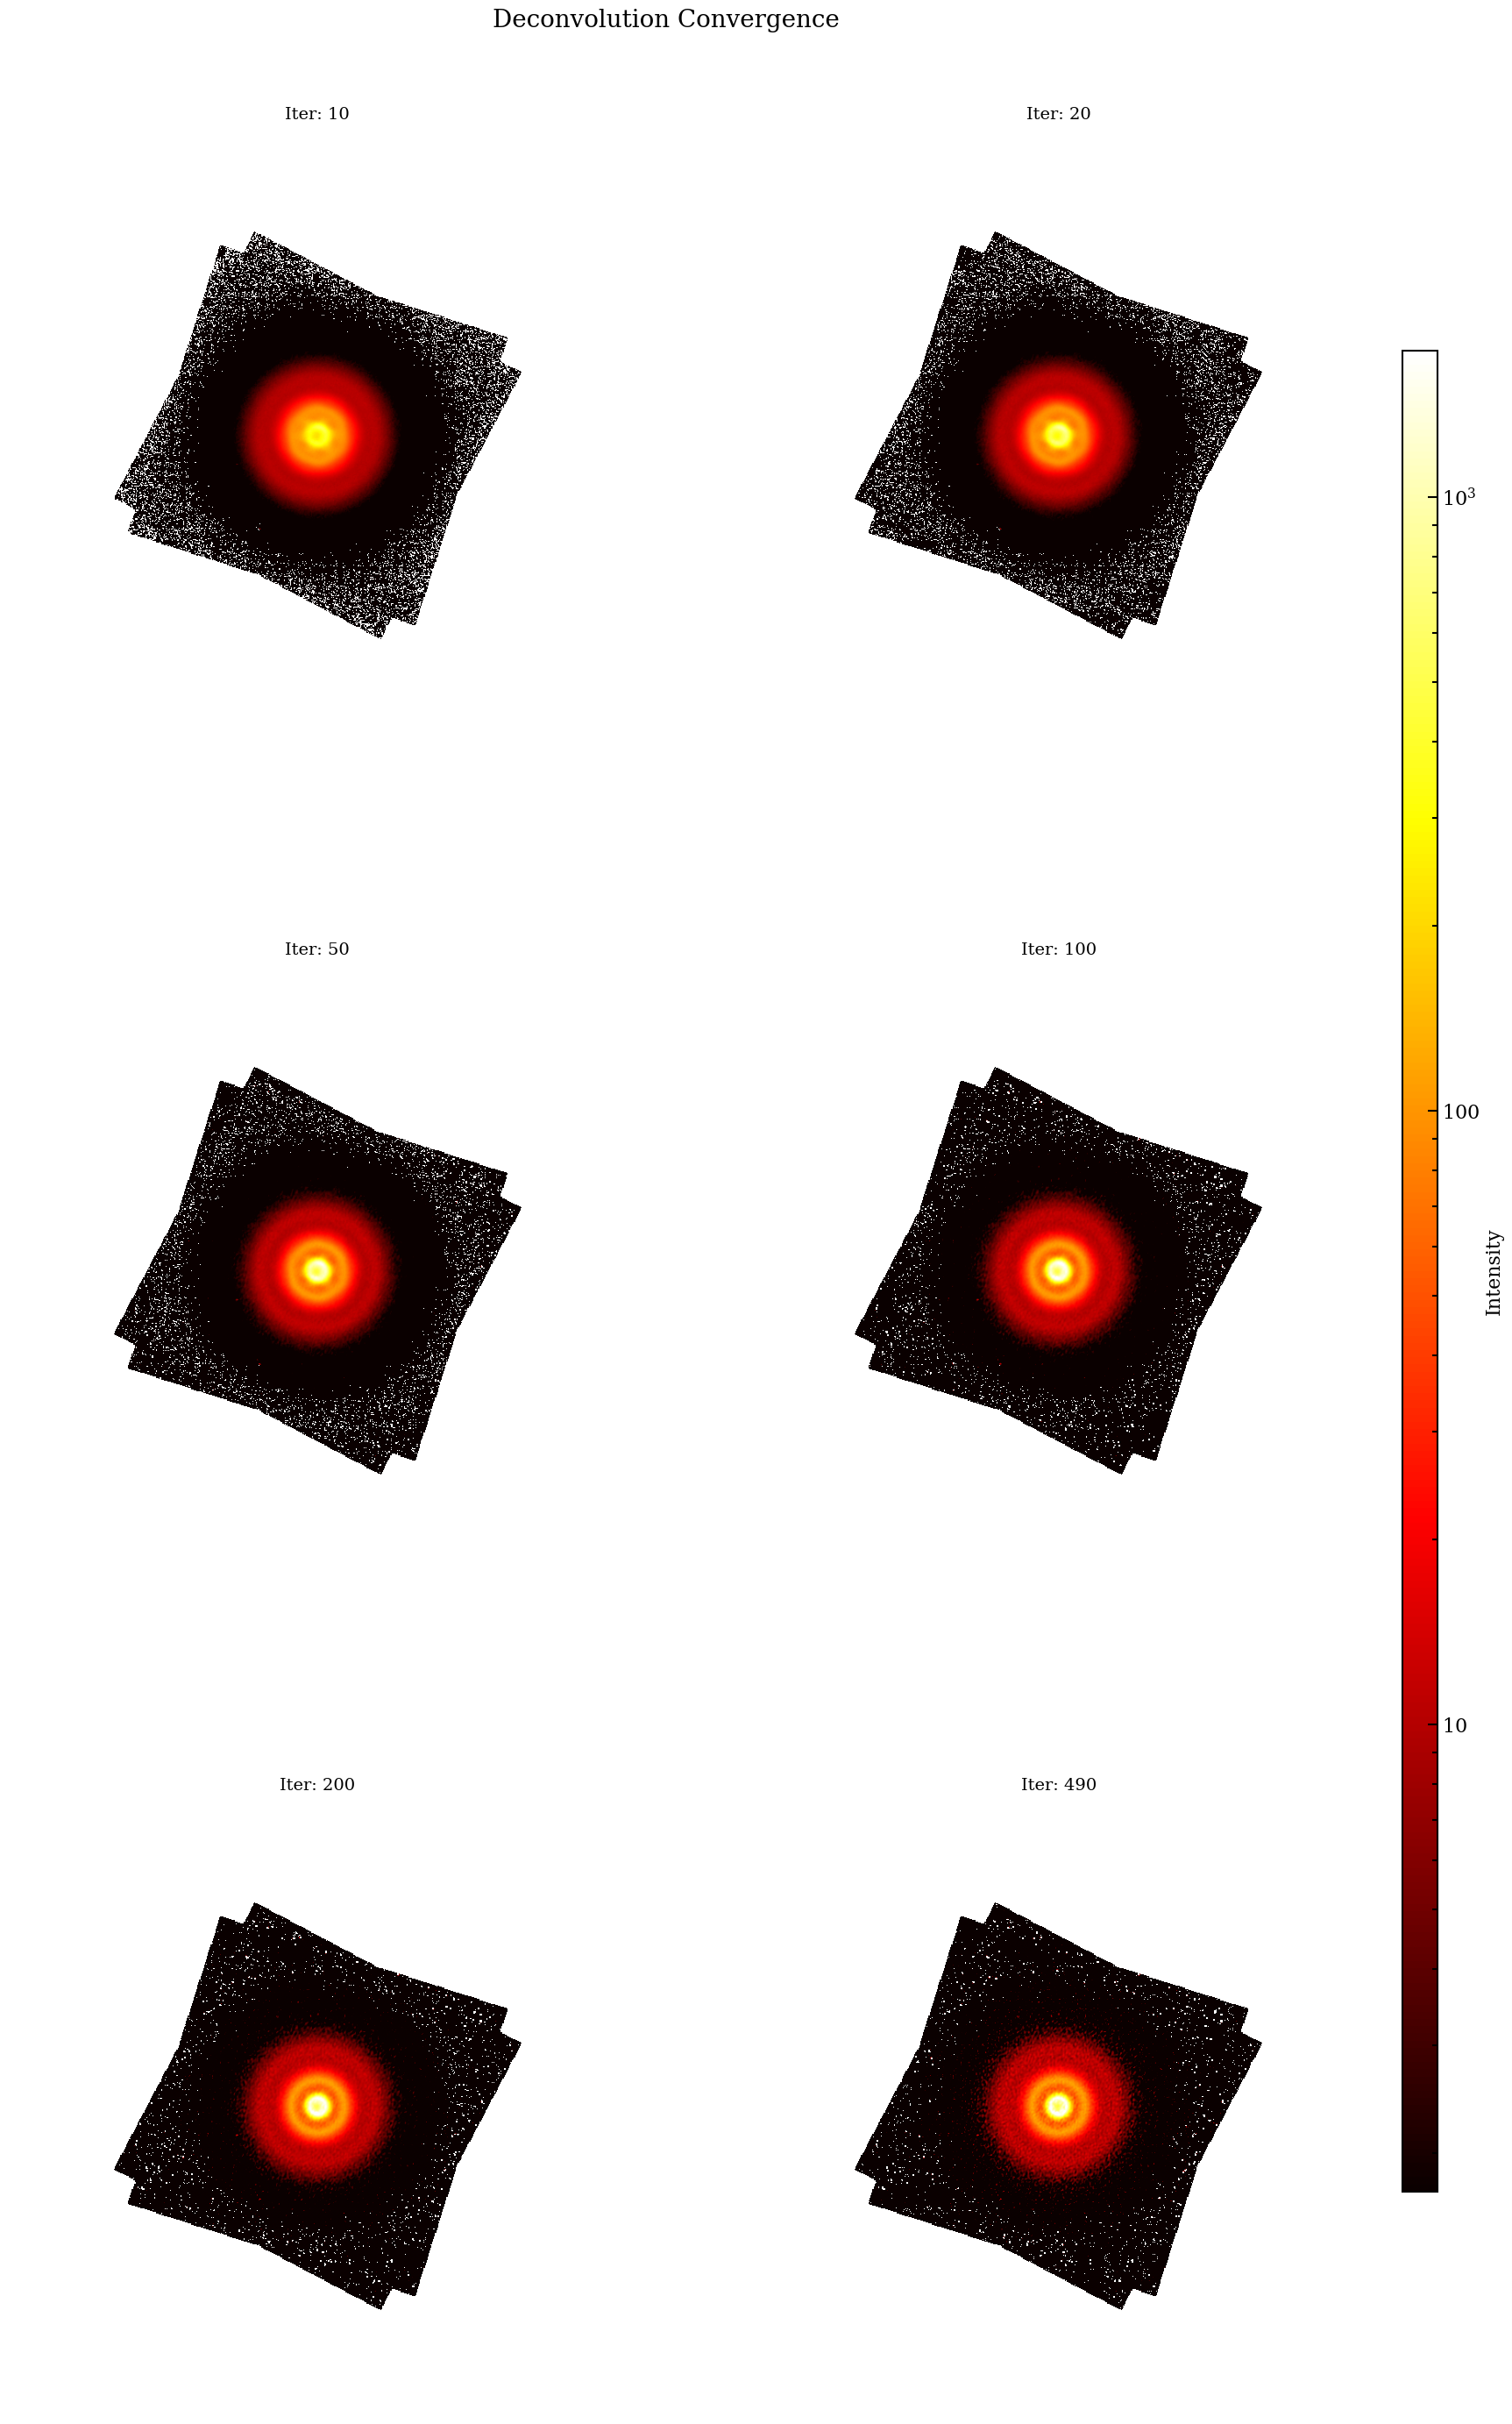

In [49]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# Define the target iterations you want to display (up to 6 for a 3x2 grid)
target_iters = [10, 20, 50, 100, 200, 490]  # Feel free to change these numbers
intermediate_cube = deconv_fm_results[1]

# Pre-gather the images to compute global vmin/vmax
images_to_plot = []
closest_iters = []

for target in target_iters:
    idx = np.argmin(np.abs(np.array(return_iters) - target))
    closest_iters.append(return_iters[idx])
    
    current_im = intermediate_cube[idx]
    if current_im.ndim == 3:
        current_im = np.nanmean(current_im, axis=0)
    images_to_plot.append(current_im)

# Calculate global vmin and vmax for a shared color scale
global_vmax = np.nanpercentile([img for img in images_to_plot], 99.99)
global_vmin = 0.001*global_vmax

fig, axes = plt.subplots(3, 2, figsize=(20, 30))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < len(images_to_plot):
        current_im = images_to_plot[i]
        
        im = ax.imshow(
            current_im, 
            norm=mpl.colors.LogNorm(vmin=global_vmin, vmax=global_vmax), 
            cmap='hot',
            origin='lower'
        )
        ax.set_title(f'Iter: {closest_iters[i]}', fontsize=14)
    
    # Hide axes for all subplots (even the empty ones if target_iters < 6)
    ax.axis('off')

# Add a single shared colorbar for the entire figure
fig.subplots_adjust(bottom=0.05, top=0.95, right=0.9)
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
# The 'im' from the last plotted image is fine to use since they all share the same norm
fig.colorbar(im, cax=cbar_ax, label='Intensity')

plt.suptitle('Deconvolution Convergence', fontsize=20, y=0.98)
plt.show()

The best iteration number is 30 with an MAE of 1.90821e+03


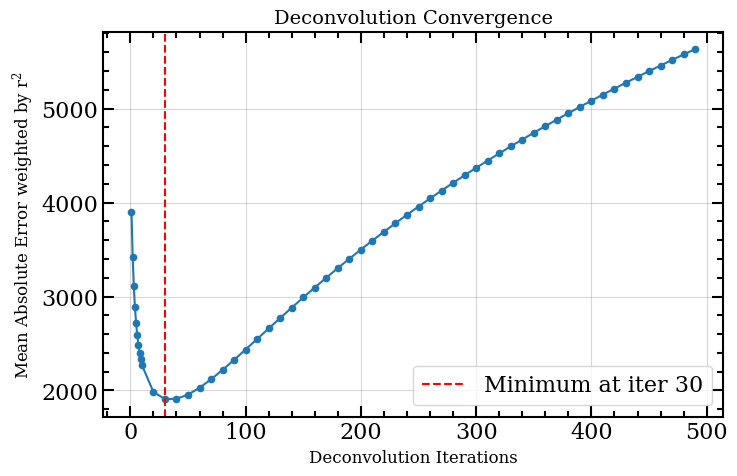

In [50]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define an evaluation mask to focus on the disk region
y, x = np.indices(best_raw_model.shape)
r_pix = np.hypot(x - wdb.c_star[0], y - wdb.c_star[1])
r_au = ang_size_to_proj_sep(px_size_to_ang_size(r_pix, wdb.pxscale), distance).value
eval_mask = (r_au >= r_au_iwa) & (r_au <= 178.88)

# Create an r^2 map in pixels to weight the errors
y_idx, x_idx = np.indices(best_raw_model.shape)
r_pix_sq = (x_idx - wdb.c_star[0])**2 + (y_idx - wdb.c_star[1])**2
errors = []
iterations = return_iters

# The second element contains the numpy array of intermediate images
intermediate_cube = deconv_fm_results[1]

# 2. Iterate through the intermediate results to compute the differences
for i in range(len(iterations)):
    current_im = intermediate_cube[i]
    
    # If the intermediate results returned un-collapsed rolls (e.g. shape (2, 650, 650)), 
    # we need to average them across the first axis to get the 2D combined image.
    if current_im.ndim == 3:
        current_im = np.nanmean(current_im, axis=0)
    
    # Calculate r^2 weighted Mean Absolute Error within the mask
    diff = np.abs(current_im - best_raw_model)
    weighted_sq_err = r_pix_sq * diff
    mae = np.nanmean(weighted_sq_err[eval_mask])
    errors.append(mae)

errors = np.array(errors)

# 3. Find the minimum error
best_idx = np.argmin(errors)
best_iter = iterations[best_idx]
print(f"The best iteration number is {best_iter} with an MAE of {errors[best_idx]:.5e}")

# 4. Plot the error curve to visualize convergence behavior
plt.figure(figsize=(8, 5))
plt.plot(iterations[:-1], errors[:-1], marker='o', markersize=4, linestyle='-')
plt.axvline(best_iter, color='red', linestyle='--', label=f'Minimum at iter {best_iter}')
plt.xlabel("Deconvolution Iterations", fontsize=12)
plt.ylabel(r"Mean Absolute Error weighted by $r^2$", fontsize=12)
plt.title("Deconvolution Convergence", fontsize=14)
#plt.xscale('log') # Log scale often helps if iterations step up exponentially
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

# 5. Extract the formally "best" image
best_deconv_im = intermediate_cube[best_idx]
if best_deconv_im.ndim == 3:
    best_deconv_im = np.nanmean(best_deconv_im, axis=0)

### Now, both noise and bifurcation structure are added to the model. 
Test if the deconvolution process can still recover the input model.

In [69]:
# best 4644 | r01=16.11, r02=51.88, r03=112.82, flux1=1915.32, flux3=9.44, flux2=105.12
h0, ain, aout, g1, g2, wg1 = 0.035, 5, -5, 0.85, -0.2, 0.75
r0_vals = [16.11, 51.88, 112.82]
flux_vals = [1915.32, 105.12, 9.44]
pa_model = 0
incl_model = 0

# generate the raw model for the best-fit parameters
best_raw_model = np.zeros([650, 650])  # Start with an empty model
for i in range(3):
    best_raw_model += grater_2hg_disk_model(
        r0_vals[i],
        h0,
        ain,
        aout,
        pa_model,
        incl_model,
        g1,
        g2,
        wg1,
        cent=wdb.c_star,
        distance=distance,
        nx=wdb.nx,
        ny=wdb.ny,
        pxscale=wdb.pxscale,
        flux_max=flux_vals[i],
    )
    
# star brightness in the central pixel in MJy/sr
pixel_size = wdb.pxscale*u.pixel
pixel_size_sr = (pixel_size.to(u.rad))**2
print(f"Pixel size in steradians: {pixel_size_sr:.3e}")

# star brightness in Jy with given distance and stellar spectrum (see Photometry.ipynb)
# 0.82327 Jy for F200W;0.35116 Jy for F356W; 0.23643 Jy for F444W 
star_brightness_jy = 0.82327 * u.Jy
print(f"Star brightness in Jy: {star_brightness_jy:.3e}")

# Convert star brightness to MJy/sr
model_central_brightness_mjysr = (star_brightness_jy / pixel_size_sr).to(u.MJy/u.sr)
print(f"Central pixel brightness in the model in MJy/sr: {model_central_brightness_mjysr:.3e}")

# Add star brightness to the model, if the star's location is integral, add the value to the stellar pixel; if not, the star's brightness should be added across 4 closest pixels
model_central_brightness = model_central_brightness_mjysr.value
if wdb.c_star[0]%1 == 0 and wdb.c_star[1]%1 == 0:
    best_raw_model[int(wdb.c_star[1]), int(wdb.c_star[0])] += model_central_brightness
else:
    jvals = int(np.floor(wdb.c_star[0])), int(np.ceil(wdb.c_star[0]))
    ivals = int(np.floor(wdb.c_star[1])), int(np.ceil(wdb.c_star[1]))
    for j in jvals:
        for i in ivals:
            # Calculate the fraction of the star's brightness that should be added to this pixel based on the distance from the star's exact location
            j_fraction = 1 - abs(wdb.c_star[0] - j)
            i_fraction = 1 - abs(wdb.c_star[1] - i)
            fraction = j_fraction * i_fraction
            print(f"Adding {fraction:.2f} of the star's brightness to pixel ({i}, {j})")
            best_raw_model[i, j] += model_central_brightness * fraction

Pixel size in steradians: 2.213e-14 rad2
Star brightness in Jy: 8.233e-01 Jy
Central pixel brightness in the model in MJy/sr: 3.720e+07 MJy / sr
Adding 0.25 of the star's brightness to pixel (324, 324)
Adding 0.25 of the star's brightness to pixel (325, 324)
Adding 0.25 of the star's brightness to pixel (324, 325)
Adding 0.25 of the star's brightness to pixel (325, 325)


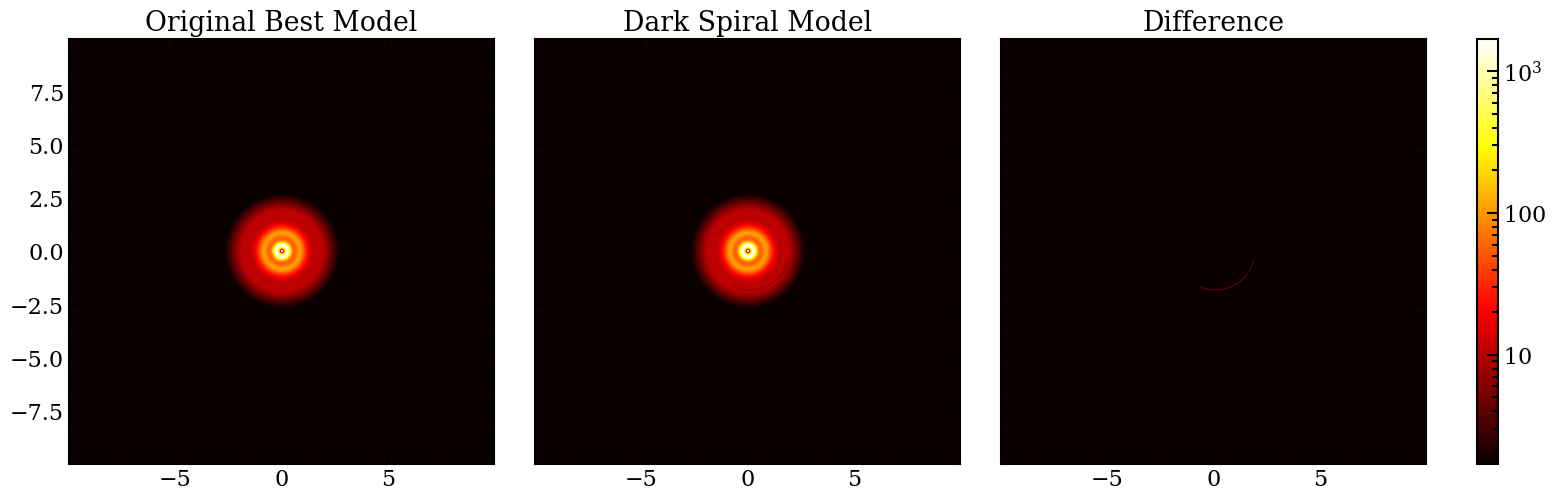

In [70]:
import numpy as np
import winnie.utils
import matplotlib as mpl
import matplotlib.pyplot as plt

# Make a copy of the best raw model to modify
bifurcated_raw_model = best_raw_model.copy()

# Spiral configuration
r_spiral_au = 116.0
pitch_angle_deg = 2.0
width_au = 3.0
darkening_fraction = 0.5 #50% darkening at the spine, tapering off with a Gaussian profile

# 1. Generate the 1D spine of the spiral explicitly bounded in the PA range
theta_spine = np.linspace(np.deg2rad(235), np.deg2rad(360), 1000)
theta_mod = theta_spine - 2 * np.pi
r_spine = r_spiral_au * np.exp(theta_mod * np.tan(np.deg2rad(pitch_angle_deg)))

# Physical coordinates of the isolated spiral spine
spine_x = r_spine * np.cos(theta_spine)
spine_y = r_spine * np.sin(theta_spine)

# 2. Extract physical pixel mapping
ny, nx = bifurcated_raw_model.shape
y, x = np.indices((ny, nx))
dy = y - wdb.c_star[1]
dx = x - wdb.c_star[0]

pix_size_in_arcsec = wdb.pxscale.to('arcsec/pixel').value
pix_size_in_au = winnie.utils.ang_size_to_proj_sep(pix_size_in_arcsec, distance).value

dx_au = dx * pix_size_in_au
dy_au = dy * pix_size_in_au

# 3. Calculate distance AND closest spine index to fade the edges
distances_au = np.zeros((ny, nx))
closest_spine_idx = np.zeros((ny, nx), dtype=int)

for i in range(ny):
    # Retrieve squared distances from row i pixels to all 1000 spiral spine points
    dist_sq = (dx_au[i, :, None] - spine_x[None, :])**2 + (dy_au[i, :, None] - spine_y[None, :])**2
    
    # Store the minimum distance and the index of the closest spine point
    distances_au[i, :] = np.sqrt(np.min(dist_sq, axis=1))
    closest_spine_idx[i, :] = np.argmin(dist_sq, axis=1)

# 4. Generate the continuous dark spiral profile
sigma_au = width_au / 2.355  
radial_profile = np.exp(-0.5 * (distances_au / sigma_au)**2)

# Create a taper along the length of the spine ---
spine_length = len(theta_spine)
taper_fraction = 0.15 # Fade the spiral over the first and last 15% of its length
taper_length = int(spine_length * taper_fraction)

azimuthal_taper = np.ones(spine_length)
# Smoothly fade in (using sine squared for a smooth S-curve)
azimuthal_taper[:taper_length] = np.sin(np.linspace(0, np.pi/2, taper_length))**2
# Smoothly fade out
azimuthal_taper[-taper_length:] = np.cos(np.linspace(0, np.pi/2, taper_length))**2

# Map the 1D taper to the 2D image based on the closest spine point
taper_2d = azimuthal_taper[closest_spine_idx]

# Combine the radial distance profile with the azimuthal boundary taper
spiral_profile = radial_profile * taper_2d

# 5. Apply the subtraction
bifurcated_raw_model -= best_raw_model * spiral_profile * darkening_fraction

# Plot the new model and comparison
fig, axes, cbar = quick_implot(
    [best_raw_model, bifurcated_raw_model, best_raw_model - bifurcated_raw_model], 
    cmap='hot', 
    clim='0.001*99.99%, 99.99%',
    norm=mpl.colors.LogNorm, # Assuming you imported matplotlib as mpl earlier
    norm_kwargs=dict(clip=True),
    show=False, 
    cbar=True, 
    cbar_kwargs=dict(pad=0.03), 
    panelsize=(6, 5), 
    extent=rdi_reduc.extent, 
    show_ticks=True
)

labels = ['Original Best Model', 'Dark Spiral Model', 'Difference']
for i, ax in enumerate(axes):
    ax.set_title(labels[i])
    
plt.show()

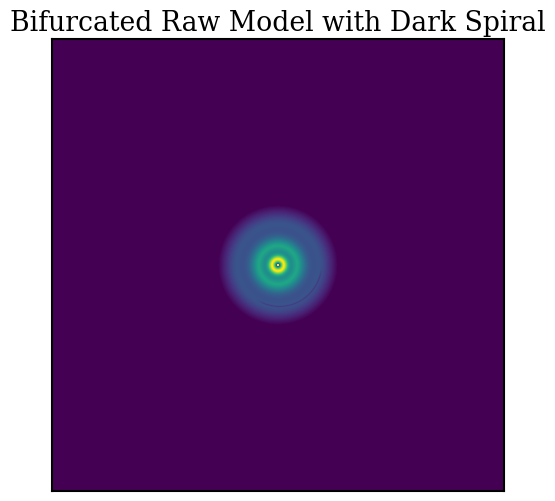

In [71]:
fig, ax = quick_implot(bifurcated_raw_model, norm=mpl.colors.LogNorm, norm_kwargs=dict(clip=True), clim='0.001*99.99%, 99.99%', show=False)
ax.set_title("Bifurcated Raw Model with Dark Spiral")
plt.show()
plt.close()

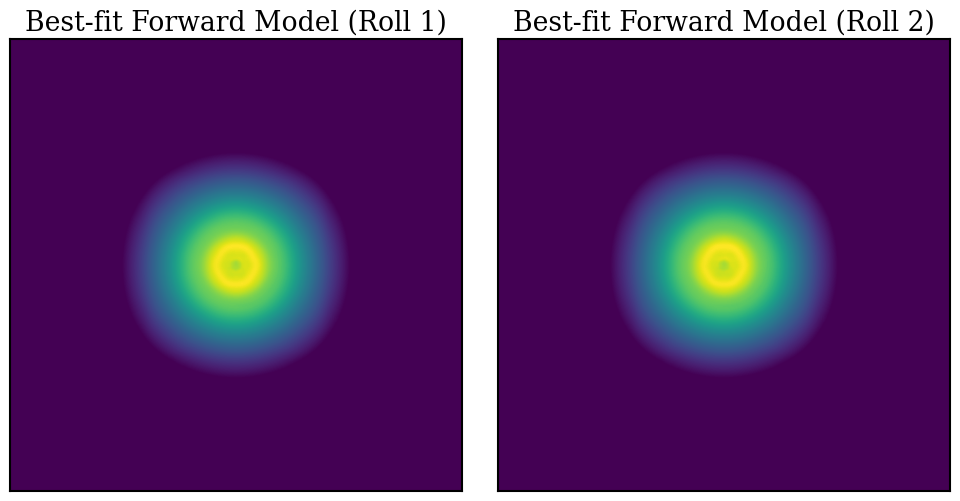

In [72]:
# forward model
forward_bifurcated_model = wdb.convolver.convolve_model(bifurcated_raw_model, wdb.pxscale, wdb.c_star)
fig, axes = quick_implot(forward_bifurcated_model, norm=mpl.colors.LogNorm, norm_kwargs=dict(clip=True), clim='0.001*99.99%, 99.99%', show=False)

# Iterate over the returned axes if there are multiple rolls
for i, ax in enumerate(axes):
    ax.set_title(f"Best-fit Forward Model (Roll {i+1})")
    
plt.show()

In [73]:
# Add noise to the forward model
rng = np.random.default_rng(78)   # Set seed for reproducibility
rand_errs = rng.normal(scale=wdb.errcube_sci)
forward_bifurcated_model_noisy = forward_bifurcated_model + rand_errs

JWST_NIRCAM_NRCA2_F200W_MASKRND_MASK335R_SUB320A335R
Science data:   2 exposures of shape (650,650)
Reference data: 241 exposures of shape (650,650)

RDI Settings:
Mode: HPFRDI (Winnie)
'opt_smoothing_fn': <function high_pass_filter_sequence at 0x7e2beef36520>
'opt_smoothing_kwargs': {'filtersize': 1.0994602853484432}
Extension for output files: 'hpfrdi_psfsub'
1 optimization zone(s)
1 subtraction zone(s)


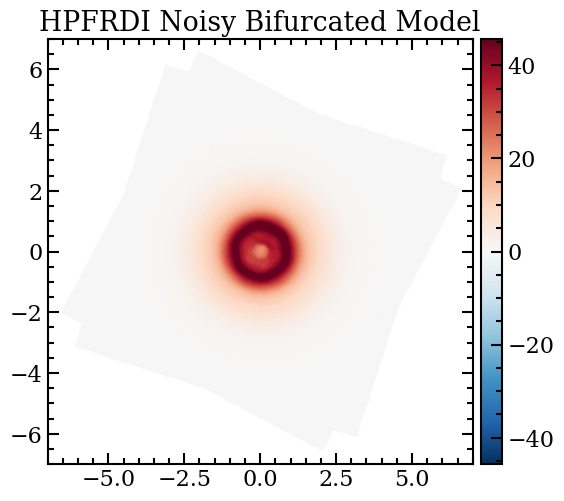

In [74]:
# HPFRDI reduction with the best-fit model
wdb.set_circumstellar_model(model_cube=forward_bifurcated_model_noisy)
wdb.hpfrdi_presets()
hpfrdi_bifurcated_model = wdb.run_rdi(forward_model=True)

# show only the HPFRDI results for the best-fit model
fig, ax, cbar = quick_implot(
    hpfrdi_bifurcated_model.im,
    cmap="RdBu_r",
    clim_perc=99,
    show=False,
    cbar=True,
    cbar_kwargs=dict(pad=0.015),
    panelsize=(6, 5),
    extent=rdi_reduc.extent,
    lims=[-7, 7],
    show_ticks=True,
)
ax.set_title("HPFRDI Noisy Bifurcated Model")
plt.show()


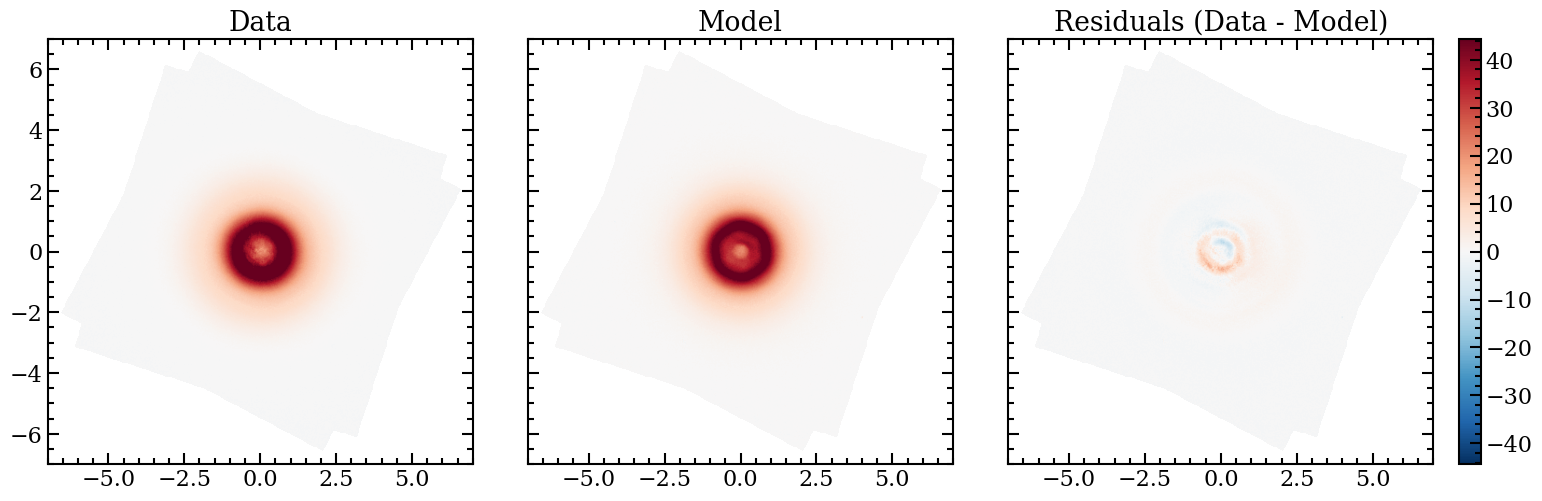

In [75]:
fig, axes, cbar = quick_implot(
    [rdi_reduc.im, hpfrdi_bifurcated_model.im, rdi_reduc.im - hpfrdi_bifurcated_model.im],
    cmap="RdBu_r",
    clim_perc=99,
    show=False,
    cbar=True,
    cbar_kwargs=dict(pad=0.015),
    panelsize=(6, 5),
    extent=rdi_reduc.extent,
    lims=[-7, 7],
    show_ticks=True,
)
for ax, title in zip(axes, ["Data", "Model", "Residuals (Data - Model)"]):
    ax.set_title(title)
plt.show()

In [76]:
import multiprocessing
total_cores = str(multiprocessing.cpu_count())
os.environ["OMP_NUM_THREADS"] = total_cores
os.environ["OPENBLAS_NUM_THREADS"] = total_cores
os.environ["MKL_NUM_THREADS"] = total_cores
os.environ["VECLIB_MAXIMUM_THREADS"] = total_cores
os.environ["NUMEXPR_NUM_THREADS"] = total_cores

# 2. Force Winnie to use all cores for its parallelized convolution mapping
wdb.ncores = -1 
wdb.convolver.ncores = -1 # Ensure the convolver also knows to max out

print(f"Deconvolving Model RDI across {total_cores} cores...")

Deconvolving Model RDI across 64 cores...


In [77]:
num_iter = 500

# Setup intermediate return iterations tracking
#return_iters = np.concatenate([np.array([1]), np.arange(10, 41, 1), np.arange(50, 131, 1), np.arange(140, 161, 1), np.arange(170, num_iter + 1, 10)])
return_iters = np.arange(1, num_iter + 1, 1)

# recreate the exclude mask to prevent central artifacts from dominating
excl_mask = winnie.utils.px_size_to_ang_size(
    winnie.utils.dist_to_pt(wdb.c_star, wdb.nx, wdb.ny),
    wdb.pxscale
).value > 7

# 1. Deconvolve the Forward Modeled RDI image (hpfrdi_model)
print(f"Deconvolving Model RDI with {num_iter} iterations...")
manual_eps = 0.05 * np.nanmedian(np.abs(hpfrdi_bifurcated_model.rolls - np.nanmedian(hpfrdi_bifurcated_model.rolls)))
deconv_bifurcated_results = wdb.run_deconvolution(
    reduc_in=hpfrdi_bifurcated_model, 
    num_iter=num_iter, 
    epsilon=manual_eps, 
    return_iters=return_iters,
    excl_mask_in=excl_mask,
    init_from_reduc=True,
    save_products=True, 
    show_progress=True
)
# Extract the final deconvolved forward-modeled image
deconv_bifurcated_model = deconv_bifurcated_results[0].im

Deconvolving Model RDI with 500 iterations...


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

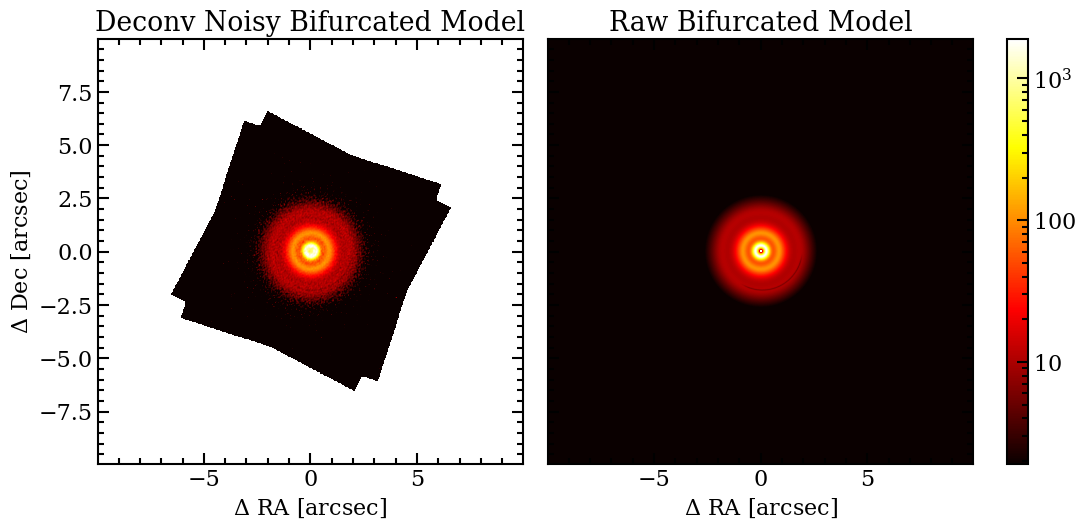

In [78]:
fig, axes, cbar = quick_implot(
    [deconv_bifurcated_model, bifurcated_raw_model], 
    cmap='hot', 
    clim='0.001*99.99%, 99.99%',
    norm=mpl.colors.LogNorm,
    norm_kwargs=dict(clip=True),
    show=False, 
    cbar=True, 
    cbar_kwargs=dict(pad=0.03), 
    panelsize=(6, 5), 
    extent=rdi_reduc.extent, 
    show_ticks=True
)

labels = ['Deconv Noisy Bifurcated Model', 'Raw Bifurcated Model']
for i, ax in enumerate(axes):
    ax.set_title(labels[i])
    ax.set_xlabel(r'$\Delta$ RA [arcsec]')
    if i == 0:
        ax.set_ylabel(r'$\Delta$ Dec [arcsec]')

plt.show()

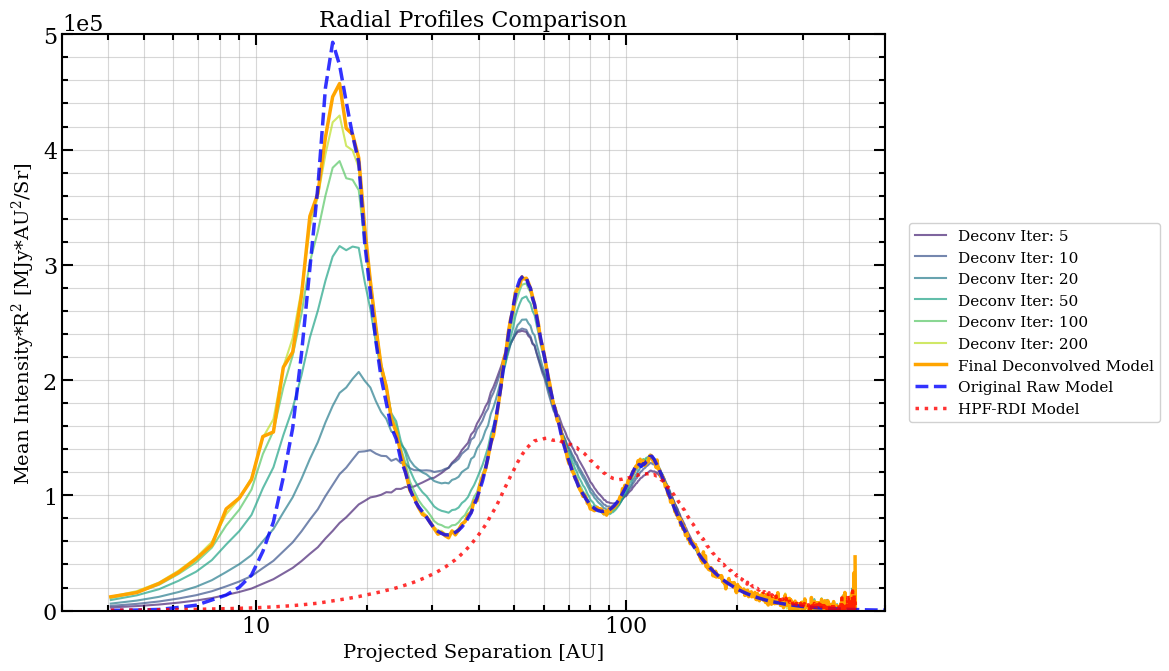

In [79]:
# Calculate radial profiles
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import winnie.utils

def simple_radial_profile(image, center, r_bins_pix):
    """
    Computes azimuthally-averaged radial profile.
    """
    y, x = np.indices(image.shape)
    r_pix = np.hypot(x - center[0], y - center[1])
    
    profile = np.zeros(len(r_bins_pix) - 1)
    for i in range(len(profile)):
        mask = (r_pix >= r_bins_pix[i]) & (r_pix < r_bins_pix[i+1])
        if np.any(mask):
            profile[i] = np.nanmean(image[mask])
        else:
            profile[i] = np.nan
    return profile

# Convert r_bins from AU to pixels to use on the images directly
r_bins_au = np.linspace(3, 500, 700)  

# The size of a single pixel in AU for calculating bin edges
# Extracting the raw `.value` strips the '1/pix' unit so winnie handles it cleanly 
pix_size_in_arcsec = wdb.pxscale.to('arcsec/pixel').value
pix_size_in_au = winnie.utils.ang_size_to_proj_sep(pix_size_in_arcsec, distance).value
r_bins_pix = r_bins_au / pix_size_in_au

# Calculate the centers of the bins in AU for plotting the x-axis
r_centers_au = (r_bins_au[:-1] + r_bins_au[1:]) / 2.
r_squared_au = r_centers_au**2

# Generate base profiles
profile_hpfrdi_model = simple_radial_profile(hpfrdi_bifurcated_model.im, wdb.c_star, r_bins_pix)
profile_deconv_bifurcated = simple_radial_profile(deconv_bifurcated_model, wdb.c_star, r_bins_pix)
profile_raw_model = simple_radial_profile(bifurcated_raw_model, wdb.c_star, r_bins_pix)

# Setup figure
plt.figure(figsize=(12, 7)) # slightly wider to fit legend outside

# Plot intermediate radial profiles from deconvolution
target_iters = [5, 10, 20, 50, 100, 200]  # Shared from your previous block
intermediate_cube = deconv_bifurcated_results[1]
colors = cm.viridis(np.linspace(0.1, 0.9, len(target_iters)))

for i, target in enumerate(target_iters):
    # Find the closest iteration match
    idx = np.argmin(np.abs(np.array(return_iters) - target))
    closest_iter = return_iters[idx]
    
    current_im = intermediate_cube[idx]
    if current_im.ndim == 3:
        current_im = np.nanmean(current_im, axis=0)
        
    # Generate profile for this iteration
    prof = simple_radial_profile(current_im, wdb.c_star, r_bins_pix)
    
    # Plot intermediate profile
    plt.plot(r_centers_au, prof * r_squared_au, 
             color=colors[i], linewidth=1.5, alpha=0.7, 
             label=f'Deconv Iter: {closest_iter}')

# Plot final models
plt.plot(r_centers_au, profile_deconv_bifurcated*r_squared_au, label='Final Deconvolved Model', color='orange', linewidth=2.5, alpha=1.0)
plt.plot(r_centers_au, profile_raw_model*r_squared_au, label='Original Raw Model', color='blue', linestyle='--', linewidth=2.5, alpha=0.8)
plt.plot(r_centers_au, profile_hpfrdi_model*r_squared_au, label='HPF-RDI Model', color='red', linestyle=':', linewidth=2.5, alpha=0.8)

plt.xlabel('Projected Separation [AU]', fontsize=14)
plt.ylabel(r'Mean Intensity*$R^2$ [MJy*$AU^2$/Sr]', fontsize=14)
plt.title('Radial Profiles Comparison', fontsize=16)

# Make legend more prominent and position outside plot box
plt.legend(fontsize=11, loc='center left', bbox_to_anchor=(1.02, 0.5), framealpha=0.9)

plt.xlim(3, 500)
plt.ylim(0, 5e5)  # Adjusted for better visibility of features
plt.xscale('log') # Log scale often helps if the range of separations is large

# Make y axis ticks in scientific notation for clarity
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

# Improve grid lines for easier reading
plt.grid(True, which="both", ls="-", alpha=0.5)

plt.tight_layout()
plt.show()

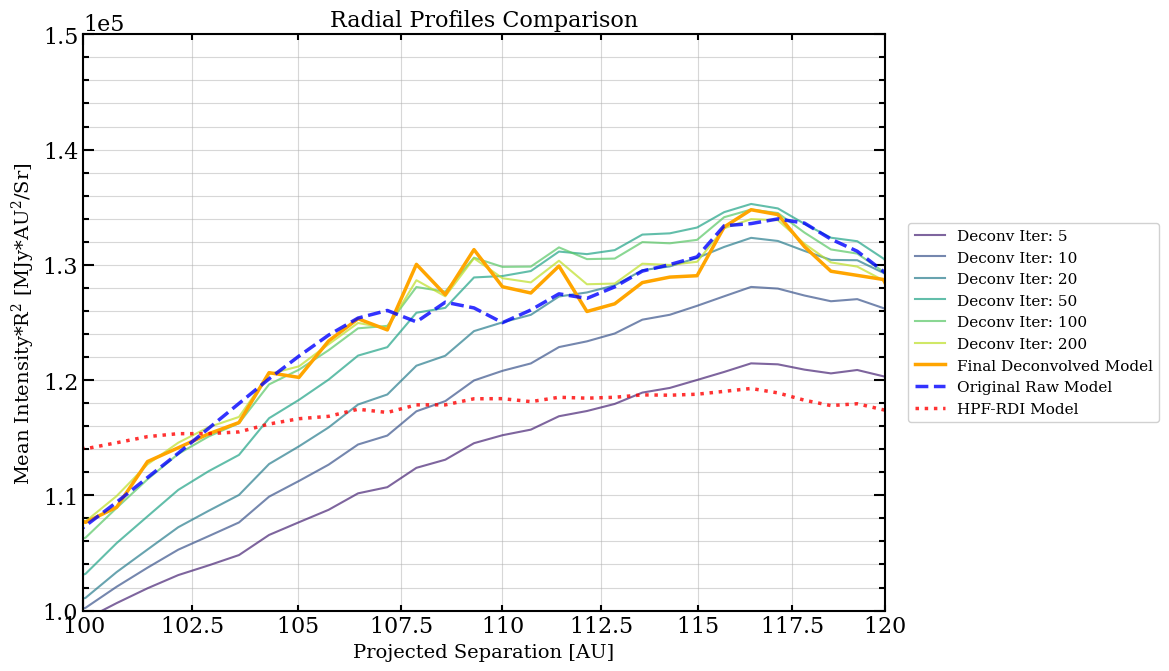

In [80]:
# Zoom in to the bifurcation region for better visibility of the differences
# Calculate radial profiles
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import winnie.utils

def simple_radial_profile(image, center, r_bins_pix):
    """
    Computes azimuthally-averaged radial profile.
    """
    y, x = np.indices(image.shape)
    r_pix = np.hypot(x - center[0], y - center[1])
    
    profile = np.zeros(len(r_bins_pix) - 1)
    for i in range(len(profile)):
        mask = (r_pix >= r_bins_pix[i]) & (r_pix < r_bins_pix[i+1])
        if np.any(mask):
            profile[i] = np.nanmean(image[mask])
        else:
            profile[i] = np.nan
    return profile

# Convert r_bins from AU to pixels to use on the images directly
r_bins_au = np.linspace(3, 500, 700)  

# The size of a single pixel in AU for calculating bin edges
# Extracting the raw `.value` strips the '1/pix' unit so winnie handles it cleanly 
pix_size_in_arcsec = wdb.pxscale.to('arcsec/pixel').value
pix_size_in_au = winnie.utils.ang_size_to_proj_sep(pix_size_in_arcsec, distance).value
r_bins_pix = r_bins_au / pix_size_in_au

# Calculate the centers of the bins in AU for plotting the x-axis
r_centers_au = (r_bins_au[:-1] + r_bins_au[1:]) / 2.
r_squared_au = r_centers_au**2

# Generate base profiles
profile_hpfrdi_model = simple_radial_profile(hpfrdi_bifurcated_model.im, wdb.c_star, r_bins_pix)
profile_deconv_bifurcated = simple_radial_profile(deconv_bifurcated_model, wdb.c_star, r_bins_pix)
profile_raw_model = simple_radial_profile(bifurcated_raw_model, wdb.c_star, r_bins_pix)

# Setup figure
plt.figure(figsize=(12, 7)) # slightly wider to fit legend outside

# Plot intermediate radial profiles from deconvolution
target_iters = [5, 10, 20, 50, 100, 200]  # Shared from your previous block
intermediate_cube = deconv_bifurcated_results[1]
colors = cm.viridis(np.linspace(0.1, 0.9, len(target_iters)))

for i, target in enumerate(target_iters):
    # Find the closest iteration match
    idx = np.argmin(np.abs(np.array(return_iters) - target))
    closest_iter = return_iters[idx]
    
    current_im = intermediate_cube[idx]
    if current_im.ndim == 3:
        current_im = np.nanmean(current_im, axis=0)
        
    # Generate profile for this iteration
    prof = simple_radial_profile(current_im, wdb.c_star, r_bins_pix)
    
    # Plot intermediate profile
    plt.plot(r_centers_au, prof * r_squared_au, 
             color=colors[i], linewidth=1.5, alpha=0.7, 
             label=f'Deconv Iter: {closest_iter}')

# Plot final models
plt.plot(r_centers_au, profile_deconv_bifurcated*r_squared_au, label='Final Deconvolved Model', color='orange', linewidth=2.5, alpha=1.0)
plt.plot(r_centers_au, profile_raw_model*r_squared_au, label='Original Raw Model', color='blue', linestyle='--', linewidth=2.5, alpha=0.8)
plt.plot(r_centers_au, profile_hpfrdi_model*r_squared_au, label='HPF-RDI Model', color='red', linestyle=':', linewidth=2.5, alpha=0.8)

plt.xlabel('Projected Separation [AU]', fontsize=14)
plt.ylabel(r'Mean Intensity*$R^2$ [MJy*$AU^2$/Sr]', fontsize=14)
plt.title('Radial Profiles Comparison', fontsize=16)

# Make legend more prominent and position outside plot box
plt.legend(fontsize=11, loc='center left', bbox_to_anchor=(1.02, 0.5), framealpha=0.9)

plt.xlim(100, 120)
plt.ylim(1e5, 1.5e5)  # Adjusted for better visibility of features
plt.xscale('log') # Log scale often helps if the range of separations is large

# Make y axis ticks in scientific notation for clarity
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

# Improve grid lines for easier reading
plt.grid(True, which="both", ls="-", alpha=0.5)

plt.tight_layout()
plt.show()

Optimal iteration found: 200 (Mean Fractional Error: 0.011207000076051)


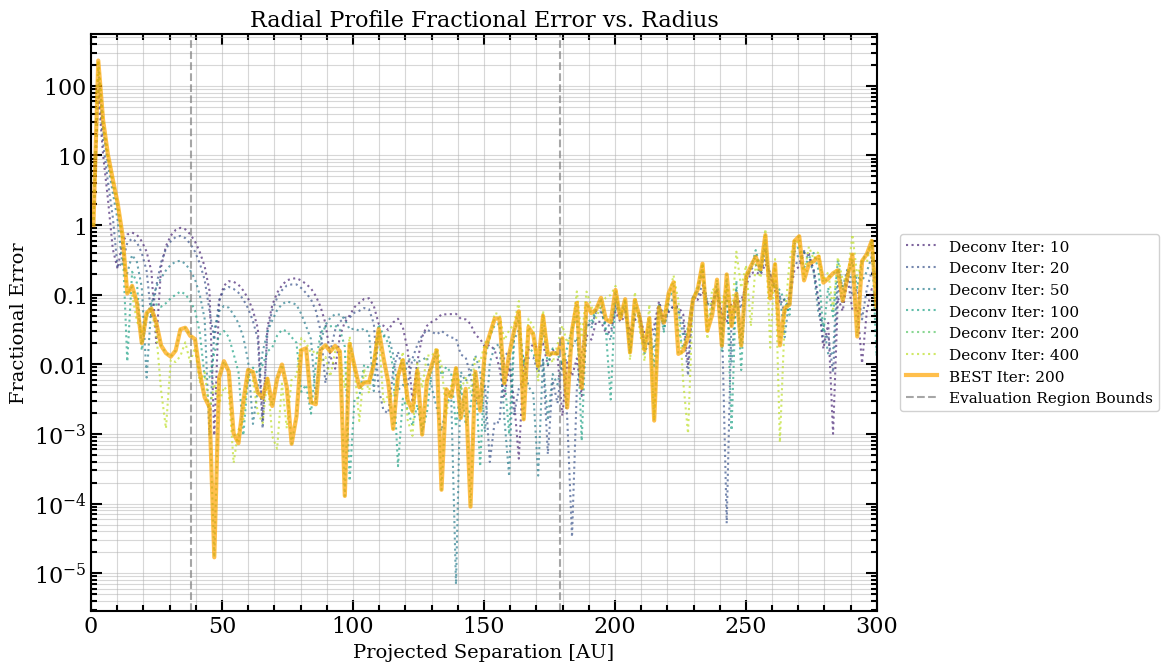

In [81]:
# Calculate radial profiles
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import winnie.utils

def convert_radial_profile(image, r_pix, r_bins_pix):
    """
    Computes azimuthally-averaged radial profile.
    Inputs:
    - image: 2D array of the image to profile
    - r_pix: 2D array of pixel radii from the star center (same shape as image)
    - r_bins_pix: 1D array of bin edges in pixels
    Output:
    - profile: 1D array of mean values in each radial bin
    """
    flat_img = image.ravel()
    flat_r = r_pix.ravel()
    
    # Handle NaNs in the image before binning
    nan_mask = np.isnan(flat_img)
    if np.any(nan_mask):
        flat_img = flat_img[~nan_mask]
        flat_r = flat_r[~nan_mask]
        
    # Map pixel radii to bin indices: bins[i-1] <= x < bins[i]
    bin_assignments = np.digitize(flat_r, r_bins_pix) - 1
    
    # Keep only the assignments that fall within our valid bin ranges
    valid = (bin_assignments >= 0) & (bin_assignments < len(r_bins_pix) - 1)
    flat_img = flat_img[valid]
    bin_assignments = bin_assignments[valid]
    
    # Calculate sums and counts per bin using bincount
    bin_sums = np.bincount(bin_assignments, weights=flat_img, minlength=len(r_bins_pix) - 1)
    bin_counts = np.bincount(bin_assignments, minlength=len(r_bins_pix) - 1)
    
    # Compute mean safely avoiding divide-by-zero warnings
    with np.errstate(divide='ignore', invalid='ignore'):
        profile = bin_sums / bin_counts
    profile[bin_counts == 0] = np.nan
    
    return profile

# Convert r_bins from pixels to AU for plotting the x-axis
r_bins_pix = np.arange(bifurcated_raw_model.shape[0]//2+1) # divide the image into annuli of 1 pixel width
pix_size_in_arcsec = wdb.pxscale.to('arcsec/pixel').value
pix_size_in_au = winnie.utils.ang_size_to_proj_sep(pix_size_in_arcsec, distance).value
r_centers_pix = (r_bins_pix[:-1] + r_bins_pix[1:]) / 2.
r_centers_au = r_centers_pix * pix_size_in_au

# =====================================================================
# PRE-COMPUTE COORDINATE GRID ONCE
# =====================================================================
y, x = np.indices(bifurcated_raw_model.shape)
r_pix = np.hypot(x - wdb.c_star[0], y - wdb.c_star[1])

# Generate base raw model profile using the new fast function
profile_raw_model = convert_radial_profile(bifurcated_raw_model, r_pix, r_bins_pix)

# =====================================================================
# Evaluate ALL iterations and CACHE profiles for plotting
# =====================================================================
intermediate_cube = deconv_bifurcated_results[1]
mean_fractional_errors = []
all_profiles = []  # Cache to store profiles and avoid recalculating for plots

# Define a radial mask to ignore the inner working angle and extreme outer empty space.
r_min_au = r_au_iwa  
r_max_au = 178.88
eval_mask = (r_centers_au > r_min_au) & (r_centers_au < r_max_au) 

for idx, iter_num in enumerate(return_iters):
    current_im = intermediate_cube[idx]
    if current_im.ndim == 3:
        current_im = np.nanmean(current_im, axis=0)
        
    # Calculate profile using the fast method
    prof = convert_radial_profile(current_im, r_pix, r_bins_pix)
    all_profiles.append(prof)
    
    # Calculate Fractional Error
    error_prof = np.abs(prof - profile_raw_model) / (np.abs(profile_raw_model) + 1e-12)
    
    # Calculate the mean fractional error ONLY across the valid disk region
    global_error = np.nanmean(error_prof[eval_mask])
    mean_fractional_errors.append(global_error)

mean_fractional_errors = np.array(mean_fractional_errors)

# Find the best iteration index
best_idx = np.nanargmin(mean_fractional_errors)
best_iter = return_iters[best_idx]
best_error = mean_fractional_errors[best_idx]

print(f"Optimal iteration found: {best_iter} (Mean Fractional Error: {best_error:.15f})")

# =====================================================================
# Plotting
# =====================================================================
plt.figure(figsize=(12, 7)) 

target_iters = [10, 20, 50, 100, 200, 400]
colors = cm.viridis(np.linspace(0.1, 0.9, len(target_iters)))

# Plot intermediate radial error profiles from cache
for i, target in enumerate(target_iters):
    idx = np.argmin(np.abs(np.array(return_iters) - target))
    closest_iter = return_iters[idx]
    
    # Zero computation here—just pulling data out of our cache list
    prof = all_profiles[idx]
    error_prof = np.abs(prof - profile_raw_model) / (np.abs(profile_raw_model) + 1e-12)
    
    plt.plot(r_centers_au, error_prof, color=colors[i], linewidth=1.5, alpha=0.7, linestyle=':', label=f'Deconv Iter: {closest_iter}')

# Plot the BEST iteration distinctly from cache
best_prof = all_profiles[best_idx]
best_error_prof = np.abs(best_prof - profile_raw_model) / (np.abs(profile_raw_model) + 1e-12)

plt.plot(r_centers_au, best_error_prof, color='orange', linewidth=3, alpha=0.7, linestyle='-', label=f'BEST Iter: {best_iter}')

# Mark the evaluation region used for the mean math
plt.axvline(r_min_au, color='gray', linestyle='--', alpha=0.7, label='Evaluation Region Bounds')
plt.axvline(r_max_au, color='gray', linestyle='--', alpha=0.7)

plt.xlabel('Projected Separation [AU]', fontsize=14)
plt.ylabel('Fractional Error', fontsize=14)
plt.title('Radial Profile Fractional Error vs. Radius', fontsize=16)

plt.yscale('log')
plt.legend(fontsize=11, loc='center left', bbox_to_anchor=(1.02, 0.5), framealpha=0.9)
plt.xlim(0, 300)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.tight_layout()
plt.show()

In [85]:
# Export the r_bin_pix and best_profile in best_fractional_error.npz for later use
print("Exporting best profile and corresponding r_bins for saving...")
np.savez("F200W_best_fractional_error.npz", r_centers_pix=r_centers_pix, r_centers_au=r_centers_au, best_error_prof=best_error_prof)

Exporting best profile and corresponding r_bins for saving...


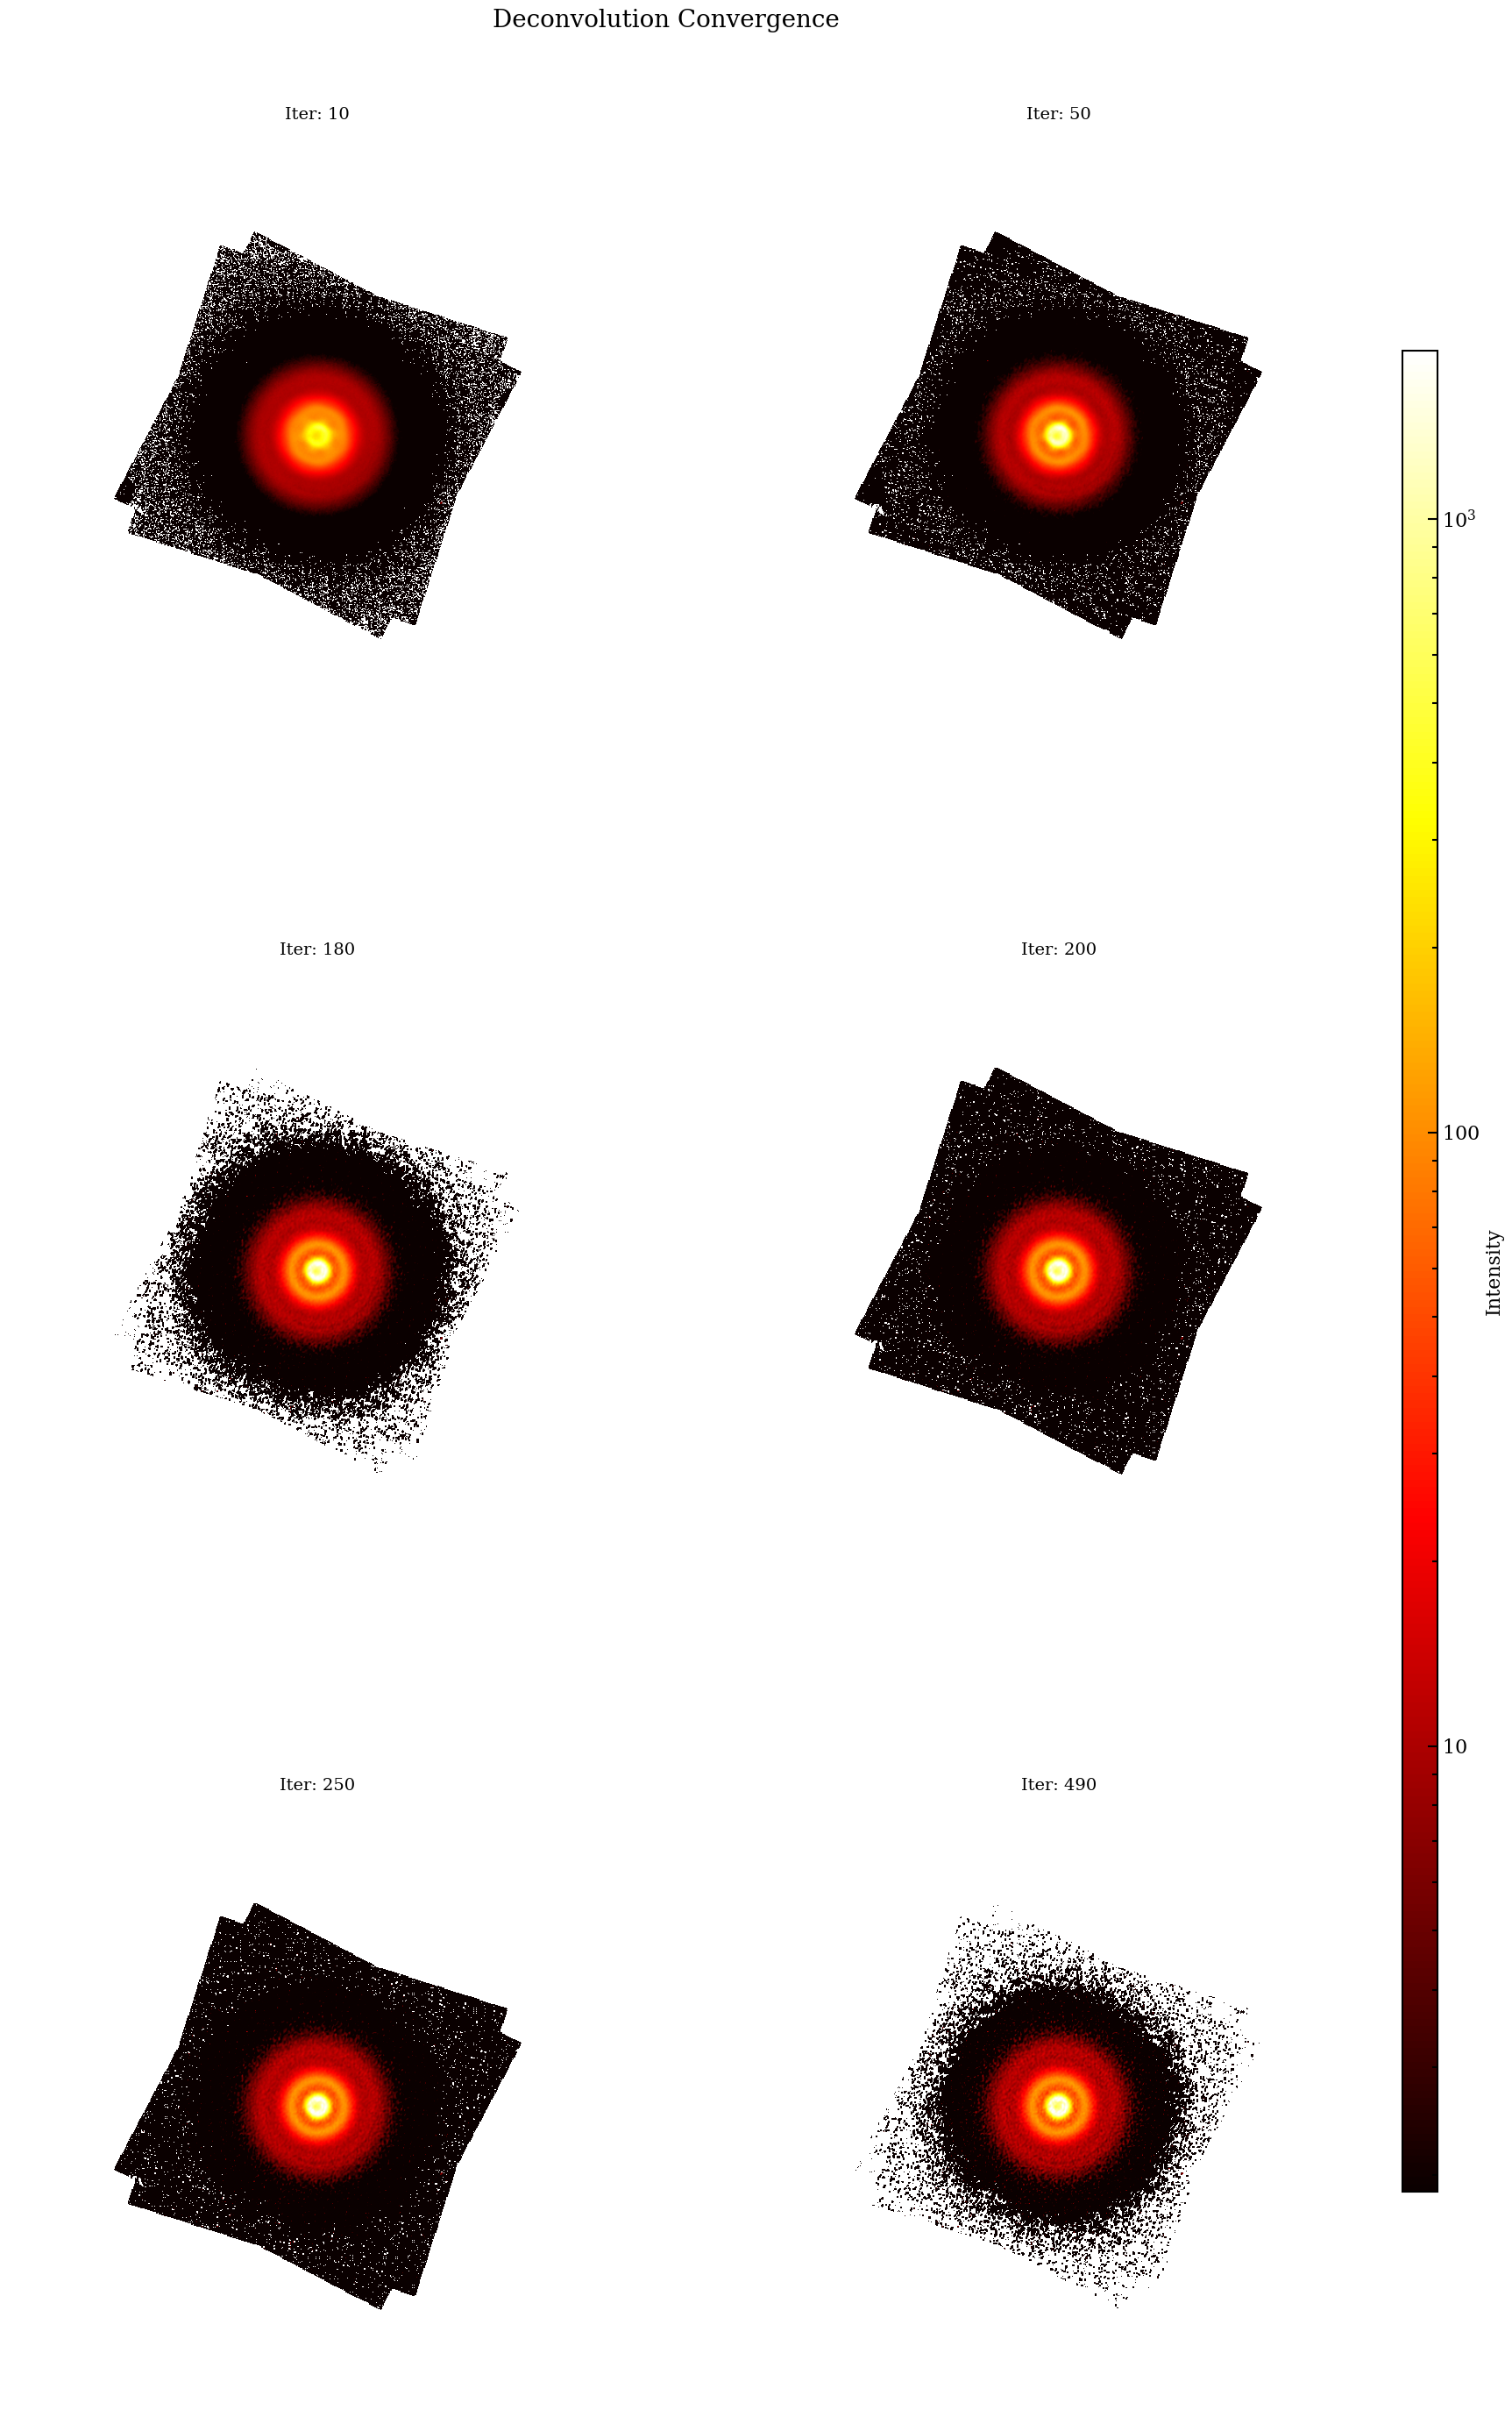

In [83]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# Define the target iterations you want to display (up to 6 for a 3x2 grid)
target_iters = [10, 50, 180, 200, 250, 490]  # Feel free to change these numbers
intermediate_cube = deconv_bifurcated_results[1]

# Pre-gather the images to compute global vmin/vmax
images_to_plot = []
closest_iters = []

for target in target_iters:
    idx = np.argmin(np.abs(np.array(return_iters) - target))
    closest_iters.append(return_iters[idx])
    
    current_im = intermediate_cube[idx]
    if current_im.ndim == 3:
        current_im = np.nanmean(current_im, axis=0)
    images_to_plot.append(current_im)

# Calculate global vmin and vmax for a shared color scale
global_vmax = np.nanpercentile([img for img in images_to_plot], 99.99)
global_vmin = 0.001*global_vmax

fig, axes = plt.subplots(3, 2, figsize=(20, 30))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < len(images_to_plot):
        current_im = images_to_plot[i]
        
        im = ax.imshow(
            current_im, 
            norm=mpl.colors.LogNorm(vmin=global_vmin, vmax=global_vmax), 
            cmap='hot',
            origin='lower'
        )
        ax.set_title(f'Iter: {closest_iters[i]}', fontsize=14)
    
    # Hide axes for all subplots (even the empty ones if target_iters < 6)
    ax.axis('off')

# Add a single shared colorbar for the entire figure
fig.subplots_adjust(bottom=0.05, top=0.95, right=0.9)
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
# The 'im' from the last plotted image is fine to use since they all share the same norm
fig.colorbar(im, cax=cbar_ax, label='Intensity')

plt.suptitle('Deconvolution Convergence', fontsize=20, y=0.98)
plt.show()

The best iteration number is 37 with an MSE of 1.99962e+03


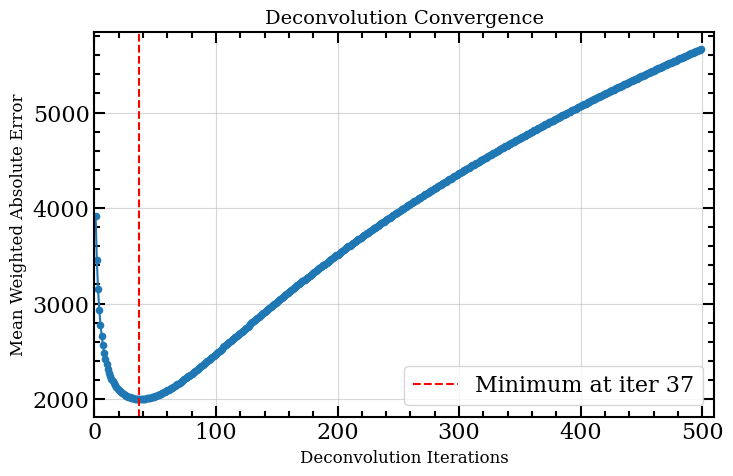

In [84]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define an evaluation mask to focus on the disk region
y, x = np.indices(best_raw_model.shape)
r_pix = np.hypot(x - wdb.c_star[0], y - wdb.c_star[1])
r_au = ang_size_to_proj_sep(px_size_to_ang_size(r_pix, wdb.pxscale), distance).value
eval_mask = (r_au >= r_au_iwa) & (r_au <= 178.88)

# Create an r^2 map in pixels to weight the errors
y_idx, x_idx = np.indices(best_raw_model.shape)
r_pix_sq = (x_idx - wdb.c_star[0])**2 + (y_idx - wdb.c_star[1])**2
errors = []
iterations = return_iters

# The second element contains the numpy array of intermediate images
intermediate_cube = deconv_bifurcated_results[1]

# 2. Iterate through the intermediate results to compute the differences
for i in range(len(iterations)):
    current_im = intermediate_cube[i]
    
    # If the intermediate results returned un-collapsed rolls (e.g. shape (2, 650, 650)), 
    # we need to average them across the first axis to get the 2D combined image.
    if current_im.ndim == 3:
        current_im = np.nanmean(current_im, axis=0)
    
    # Calculate fractional differences within the maks
    abs_diff = np.abs(current_im - bifurcated_raw_model)
    weighted_sq_err = r_pix_sq * abs_diff
    
    mse = np.nanmean(weighted_sq_err[eval_mask])
    errors.append(mse)

errors = np.array(errors)

# 3. Find the minimum error
best_idx = np.argmin(errors)
best_iter = iterations[best_idx]
print(f"The best iteration number is {best_iter} with an MSE of {errors[best_idx]:.5e}")

# 4. Plot the error curve to visualize convergence behavior
plt.figure(figsize=(8, 5))
plt.plot(iterations[:-1], errors[:-1], marker='o', markersize=4, linestyle='-')
plt.axvline(best_iter, color='red', linestyle='--', label=f'Minimum at iter {best_iter}')
plt.xlabel("Deconvolution Iterations", fontsize=12)
plt.xlim(0, iterations[-1]+10)
plt.ylabel(r"Mean Weighted Absolute Error", fontsize=12)
plt.title("Deconvolution Convergence", fontsize=14)
#plt.xscale('log') # Log scale often helps if iterations step up exponentially
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

# 5. Extract the formally "best" image
best_deconv_im = intermediate_cube[best_idx]
if best_deconv_im.ndim == 3:
    best_deconv_im = np.nanmean(best_deconv_im, axis=0)

### Best iteration and error profile vs random seed

In [67]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import winnie.utils

best_iters = []
best_errors = []
for random_seed in range(280):
    # Add noise to the forward model
    rng = np.random.default_rng(random_seed)   # Set seed for reproducibility
    rand_errs = rng.normal(scale=wdb.errcube_sci)
    forward_bifurcated_model_noisy = forward_bifurcated_model + rand_errs
    
    # HPFRDI reduction with the best-fit model
    wdb.set_circumstellar_model(model_cube=forward_bifurcated_model_noisy)
    wdb.hpfrdi_presets()
    hpfrdi_bifurcated_model = wdb.run_rdi(forward_model=True)
    
    # Deconvolution process
    num_iter = 280

    # Setup intermediate return iterations tracking
    #return_iters = np.concatenate([np.array([1]), np.arange(10, 41, 1), np.arange(50, 131, 1), np.arange(140, 161, 1), np.arange(170, num_iter + 1, 10)])
    return_iters = np.arange(1, num_iter + 1, 1)

    # recreate the exclude mask to prevent central artifacts from dominating
    excl_mask = winnie.utils.px_size_to_ang_size(
        winnie.utils.dist_to_pt(wdb.c_star, wdb.nx, wdb.ny),
        wdb.pxscale
    ).value > 7

    # 1. Deconvolve the Forward Modeled RDI image (hpfrdi_model)
    manual_eps = 0.05 * np.nanmedian(np.abs(hpfrdi_bifurcated_model.rolls - np.nanmedian(hpfrdi_bifurcated_model.rolls)))
    deconv_bifurcated_results = wdb.run_deconvolution(
        reduc_in=hpfrdi_bifurcated_model, 
        num_iter=num_iter, 
        epsilon=manual_eps, 
        return_iters=return_iters,
        excl_mask_in=excl_mask,
        init_from_reduc=True,
        save_products=True, 
        show_progress=False
    )
    
    # Calculate radial profiles
    def convert_radial_profile(image, r_pix, r_bins_pix):
        """
        Computes azimuthally-averaged radial profile.
        """
        flat_img = image.ravel()
        flat_r = r_pix.ravel()
        
        # Handle NaNs in the image before binning
        nan_mask = np.isnan(flat_img)
        if np.any(nan_mask):
            flat_img = flat_img[~nan_mask]
            flat_r = flat_r[~nan_mask]
            
        # Map pixel radii to bin indices: bins[i-1] <= x < bins[i]
        bin_assignments = np.digitize(flat_r, r_bins_pix) - 1
        
        # Keep only the assignments that fall within our valid bin ranges
        valid = (bin_assignments >= 0) & (bin_assignments < len(r_bins_pix) - 1)
        flat_img = flat_img[valid]
        bin_assignments = bin_assignments[valid]
        
        # Calculate sums and counts per bin using bincount
        bin_sums = np.bincount(bin_assignments, weights=flat_img, minlength=len(r_bins_pix) - 1)
        bin_counts = np.bincount(bin_assignments, minlength=len(r_bins_pix) - 1)
        
        # Compute mean safely avoiding divide-by-zero warnings
        with np.errstate(divide='ignore', invalid='ignore'):
            profile = bin_sums / bin_counts
        profile[bin_counts == 0] = np.nan
        
        return profile

    # Convert r_bins from pixels to AU for plotting the x-axis
    r_bins_pix = np.arange(bifurcated_raw_model.shape[0]//2+1) # divide the image into annuli of 1 pixel width
    pix_size_in_arcsec = wdb.pxscale.to('arcsec/pixel').value
    pix_size_in_au = winnie.utils.ang_size_to_proj_sep(pix_size_in_arcsec, distance).value
    r_bins_au = r_bins_pix * pix_size_in_au
    r_centers_au = (r_bins_au[:-1] + r_bins_au[1:]) / 2.

    # =====================================================================
    # PRE-COMPUTE COORDINATE GRID ONCE
    # =====================================================================
    y, x = np.indices(bifurcated_raw_model.shape)
    r_pix = np.hypot(x - wdb.c_star[0], y - wdb.c_star[1])

    # Generate base raw model profile using the new fast function
    profile_raw_model = convert_radial_profile(bifurcated_raw_model, r_pix, r_bins_pix)

    # =====================================================================
    # Evaluate ALL iterations and CACHE profiles for plotting
    # =====================================================================
    intermediate_cube = deconv_bifurcated_results[1]
    mean_fractional_errors = []

    # Define a radial mask to ignore the inner working angle and extreme outer empty space.
    r_min_au = r_au_iwa  
    r_max_au = 178.88 
    eval_mask = (r_centers_au > r_min_au) & (r_centers_au < r_max_au) 

    for idx, iter_num in enumerate(return_iters):
        current_im = intermediate_cube[idx]
        if current_im.ndim == 3:
            current_im = np.nanmean(current_im, axis=0)
            
        # Calculate profile using the fast method
        prof = convert_radial_profile(current_im, r_pix, r_bins_pix)
        
        # Calculate Fractional Error
        error_prof = np.abs(prof - profile_raw_model) / (np.abs(profile_raw_model) + 1e-12)
        
        # Calculate the mean fractional error ONLY across the valid disk region
        global_error = np.nanmean(error_prof[eval_mask])
        mean_fractional_errors.append(global_error)

    mean_fractional_errors = np.array(mean_fractional_errors)

    # Find the best iteration index
    best_idx = np.nanargmin(mean_fractional_errors)
    best_iter = return_iters[best_idx]
    best_error = mean_fractional_errors[best_idx]

    print(f"Optimal iteration found: {best_iter} (Mean Fractional Error: {best_error:.15f}) for random seed {random_seed}")
    best_iters.append(best_iter)
    best_errors.append(best_error)

JWST_NIRCAM_NRCA2_F200W_MASKRND_MASK335R_SUB320A335R
Science data:   2 exposures of shape (650,650)
Reference data: 241 exposures of shape (650,650)

RDI Settings:
Mode: HPFRDI (Winnie)
'opt_smoothing_fn': <function high_pass_filter_sequence at 0x7e2beef36520>
'opt_smoothing_kwargs': {'filtersize': 1.0994602853484432}
Extension for output files: 'hpfrdi_psfsub'
1 optimization zone(s)
1 subtraction zone(s)
Optimal iteration found: 183 (Mean Fractional Error: 0.012721724187859) for random seed 0
JWST_NIRCAM_NRCA2_F200W_MASKRND_MASK335R_SUB320A335R
Science data:   2 exposures of shape (650,650)
Reference data: 241 exposures of shape (650,650)

RDI Settings:
Mode: HPFRDI (Winnie)
'opt_smoothing_fn': <function high_pass_filter_sequence at 0x7e2beef36520>
'opt_smoothing_kwargs': {'filtersize': 1.0994602853484432}
Extension for output files: 'hpfrdi_psfsub'
1 optimization zone(s)
1 subtraction zone(s)
Optimal iteration found: 179 (Mean Fractional Error: 0.011870050370485) for random seed 1
JW

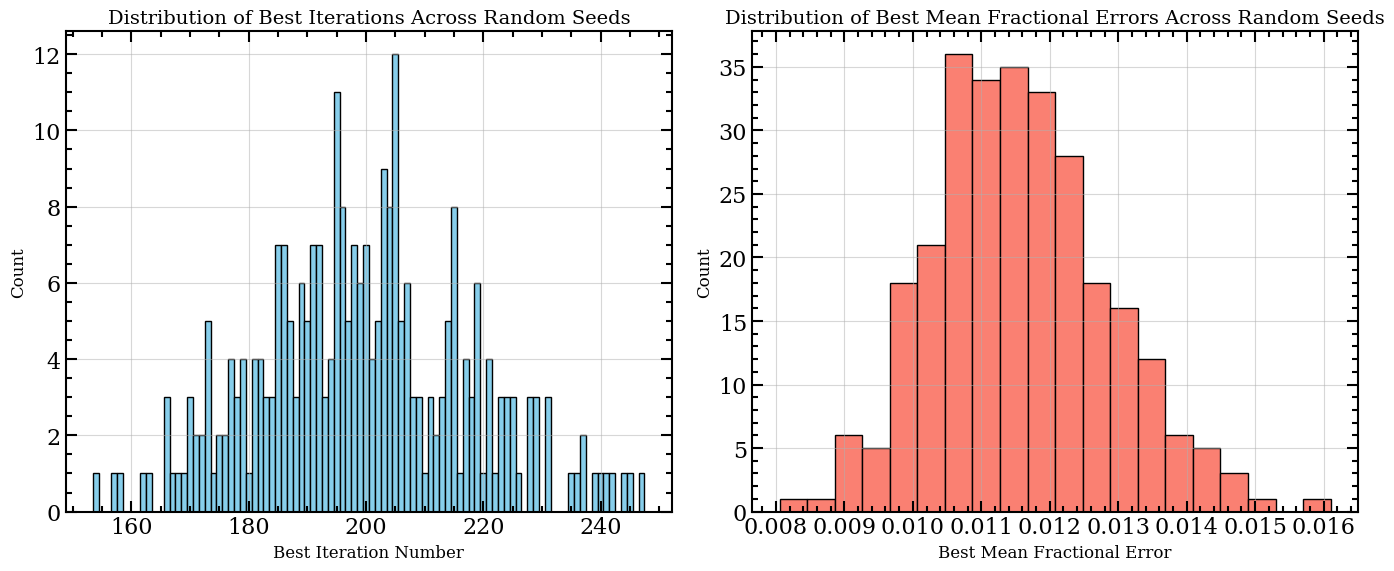

In [68]:
# Plot the distribution of best iterations and their corresponding errors across all random seeds in two subplots
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.hist(best_iters, bins=np.arange(min(best_iters)-0.5, max(best_iters)+0.5, 1), color='skyblue', edgecolor='black')
plt.xlabel('Best Iteration Number', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of Best Iterations Across Random Seeds', fontsize=14)
plt.grid(True, alpha=0.5)
plt.subplot(1, 2, 2)
plt.hist(best_errors, bins=20, color='salmon', edgecolor='black')
plt.xlabel('Best Mean Fractional Error', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of Best Mean Fractional Errors Across Random Seeds', fontsize=14)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

### Appendix (for internal testing))

In [66]:
# Read the ERR from fits file at padded/jw01179005001_03107_00001_nrca2_calints.fits
from astropy.io import fits
err_fits_path = "data_nircam_twhya/padded/jw01179005001_03107_00001_nrca2_calints.fits"
with fits.open(err_fits_path) as hdul:
    err_data = hdul[1].data  # Assuming the ERR cube is in the first extension
    err_header = hdul[1].header
    print(f"ERR cube shape: {err_data.shape}")

ERR cube shape: (16, 480, 480)


In [67]:
# Inspect HDUs to verify where SCI/ERR/DQ live in this calints file
from pathlib import Path
from astropy.io import fits

candidate_paths = [
    Path('data_nircam_twhya/padded/jw01179005001_03107_00001_nrca2_calints.fits'),
    Path('data_twhya_winnie/padded/jw01179005001_03107_00001_nrca2_calints.fits'),
]

err_fits_path = next((str(p) for p in candidate_paths if p.exists()), None)
if err_fits_path is None:
    raise FileNotFoundError('Could not find jw01179005001_03107_00001_nrca2_calints.fits in expected folders.')

print(f'Using file: {err_fits_path}')
with fits.open(err_fits_path) as hdul:
    hdul.info()
    print('\nExtension summary:')
    for i, hdu in enumerate(hdul):
        extname = hdu.header.get('EXTNAME', 'PRIMARY')
        shape = None if hdu.data is None else hdu.data.shape
        print(f'  [{i:2d}] {extname:>8s} shape={shape}')

Using file: data_nircam_twhya/padded/jw01179005001_03107_00001_nrca2_calints.fits
Filename: data_nircam_twhya/padded/jw01179005001_03107_00001_nrca2_calints.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     342   ()      
  1  SCI           1 ImageHDU       113   (480, 480, 16)   float32   
  2  ERR           1 ImageHDU        11   (480, 480, 16)   float32   
  3  DQ            1 ImageHDU        12   (480, 480, 16)   int32 (rescales to uint32)   
  4  AREA          1 ImageHDU         9   (320, 320)   float32   
  5  INT_TIMES     1 BinTableHDU     24   16R x 7C   [J, D, D, D, D, D, D]   
  6  VAR_POISSON    1 ImageHDU        10   (320, 320, 16)   float32   
  7  VAR_RNOISE    1 ImageHDU        10   (320, 320, 16)   float32   
  8  VAR_FLAT      1 ImageHDU        10   (320, 320, 16)   float32   
  9  ASDF          1 BinTableHDU     11   1R x 1C   [6580827B]   
 10  IMSHIFTS      1 ImageHDU         8   (2, 16)   float64   
 11  MASKOFF


Extension summary:
  [ 0]  PRIMARY shape=None
  [ 1]      SCI shape=(16, 480, 480)
  [ 2]      ERR shape=(16, 480, 480)
  [ 3]       DQ shape=(16, 480, 480)
  [ 4]     AREA shape=(320, 320)
  [ 5] INT_TIMES shape=(16,)
  [ 6] VAR_POISSON shape=(16, 320, 320)
  [ 7] VAR_RNOISE shape=(16, 320, 320)
  [ 8] VAR_FLAT shape=(16, 320, 320)
  [ 9]     ASDF shape=(1,)
  [10] IMSHIFTS shape=(16, 2)
  [11] MASKOFFS shape=(16, 2)


Per-integration ERR quality:
  int  0: median(ERR)=0.812606, good_fraction=0.440
  int  1: median(ERR)=0.813174, good_fraction=0.439
  int  2: median(ERR)=0.813712, good_fraction=0.438
  int  3: median(ERR)=0.812538, good_fraction=0.441
  int  4: median(ERR)=0.813704, good_fraction=0.439
  int  5: median(ERR)=0.81319, good_fraction=0.439
  int  6: median(ERR)=0.813013, good_fraction=0.439
  int  7: median(ERR)=0.813907, good_fraction=0.437
  int  8: median(ERR)=0.813079, good_fraction=0.439
  int  9: median(ERR)=0.813305, good_fraction=0.439
  int 10: median(ERR)=0.813003, good_fraction=0.440
  int 11: median(ERR)=0.813021, good_fraction=0.439
  int 12: median(ERR)=0.812464, good_fraction=0.440
  int 13: median(ERR)=0.812946, good_fraction=0.440
  int 14: median(ERR)=0.813332, good_fraction=0.439
  int 15: median(ERR)=0.813495, good_fraction=0.439

Lowest-median-ERR integration: 12

Global summary (finite pixels only):
  ERR[best_idx]        median=0.812464, p16=0.776143, p84=1.09767
 

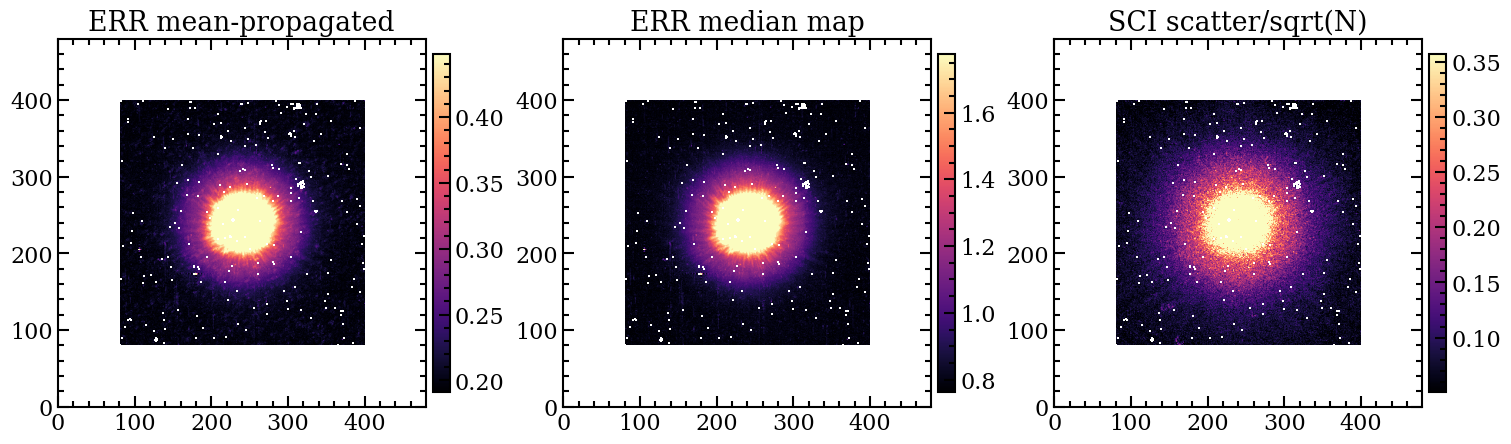


Set err_for_model = ERR mean-propagated (sqrt(sum(err^2))/N over good DQ pixels).


In [68]:
# Diagnose ERR cube quality and build model-ready 2D uncertainty maps
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

with fits.open(err_fits_path) as hdul:
    sci_cube = np.array(hdul['SCI'].data, dtype=float)
    err_cube = np.array(hdul['ERR'].data, dtype=float)
    dq_cube = np.array(hdul['DQ'].data, dtype=np.uint32)

nint = err_cube.shape[0]
good = (dq_cube == 0) & np.isfinite(err_cube) & (err_cube > 0)

# Per-integration quality metrics
med_err = np.array([np.nanmedian(np.where(good[i], err_cube[i], np.nan)) for i in range(nint)])
good_frac = np.array([np.nanmean(good[i]) for i in range(nint)])

best_idx = int(np.nanargmin(med_err))
print('Per-integration ERR quality:')
for i in range(nint):
    print(f'  int {i:2d}: median(ERR)={med_err[i]:.6g}, good_fraction={good_frac[i]:.3f}')
print(f'\nLowest-median-ERR integration: {best_idx}')

# Candidate 2D uncertainty maps from cube
n_good = np.sum(good, axis=0)
err_mean_propagated = np.sqrt(np.nansum(np.where(good, err_cube**2, np.nan), axis=0)) / np.clip(n_good, 1, None)
err_median_map = np.nanmedian(np.where(good, err_cube, np.nan), axis=0)
err_std_from_sci = np.nanstd(np.where(good, sci_cube, np.nan), axis=0) / np.sqrt(np.clip(n_good, 1, None))

# Keep only pixels with at least one valid integration
for m in (err_mean_propagated, err_median_map, err_std_from_sci):
    m[n_good == 0] = np.nan

print('\nGlobal summary (finite pixels only):')
for name, m in [
    ('ERR[best_idx]', np.where(good[best_idx], err_cube[best_idx], np.nan)),
    ('ERR mean-propagated', err_mean_propagated),
    ('ERR median map', err_median_map),
    ('SCI scatter/sqrt(N)', err_std_from_sci),
]:
    vals = m[np.isfinite(m)]
    print(f'  {name:20s} median={np.nanmedian(vals):.6g}, p16={np.nanpercentile(vals,16):.6g}, p84={np.nanpercentile(vals,84):.6g}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
for ax, data, title in zip(
    axes,
    [err_mean_propagated, err_median_map, err_std_from_sci],
    ['ERR mean-propagated', 'ERR median map', 'SCI scatter/sqrt(N)']
):
    vmin, vmax = np.nanpercentile(data, [5, 95])
    im = ax.imshow(data, origin='lower', vmin=vmin, vmax=vmax, cmap='magma')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
plt.show()

# Recommendation handle:
# Use this when your model image is an average/stack over integrations in detector space.
err_for_model = err_mean_propagated
print('\nSet err_for_model = ERR mean-propagated (sqrt(sum(err^2))/N over good DQ pixels).')

In [69]:
# Check compatibility with current model products and derive a fit-ready error array
print('Shapes:')
if 'rdi_reduc' in globals() and hasattr(rdi_reduc, 'im'):
    print('  rdi_reduc.im:', np.shape(rdi_reduc.im))
if 'eval_mask' in globals():
    print('  eval_mask   :', np.shape(eval_mask))
print('  err_for_model:', np.shape(err_for_model))

if 'eval_mask' in globals() and np.shape(eval_mask) == np.shape(err_for_model):
    err_for_fit = np.where(eval_mask, err_for_model, np.nan)
    print('Created err_for_fit using eval_mask.')
    print('  median(err_for_fit over eval_mask) =', np.nanmedian(err_for_fit))
else:
    err_for_fit = err_for_model
    print('Using full-frame err_for_model as err_for_fit (no shape-matched eval_mask).')

Shapes:
  rdi_reduc.im: (650, 650)
  eval_mask   : (650, 650)
  err_for_model: (480, 480)
Using full-frame err_for_model as err_for_fit (no shape-matched eval_mask).


In [70]:
# Compare with existing model-space error term (if already computed in notebook)
if 'errors' in globals():
    print('errors shape:', np.shape(errors))
    finite = np.isfinite(errors)
    if np.any(finite):
        vals = np.array(errors)[finite]
        print('errors stats: median=', np.nanmedian(vals), ' p16=', np.nanpercentile(vals, 16), ' p84=', np.nanpercentile(vals, 84))
else:
    print('No variable named errors in the current kernel.')

errors shape: (500,)
errors stats: median= 4010.174550921458  p16= 2380.7493436699133  p84= 5241.713686677527


Created err_for_fit in model space with eval_mask applied.
err_for_fit shape: (650, 650)
err_for_fit finite fraction: 0.06659408284023668


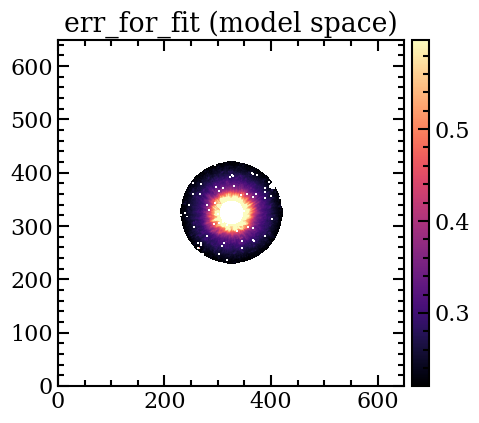

In [71]:
# Optional: center-embed detector-space ERR map into model image size
if 'rdi_reduc' in globals() and hasattr(rdi_reduc, 'im'):
    target_shape = np.shape(rdi_reduc.im)
else:
    target_shape = None

if target_shape is not None and len(target_shape) == 2:
    ty, tx = target_shape
    sy, sx = err_for_model.shape

    if ty >= sy and tx >= sx:
        err_for_model_650 = np.full(target_shape, np.nan, dtype=float)
        y0 = (ty - sy) // 2
        x0 = (tx - sx) // 2
        err_for_model_650[y0:y0+sy, x0:x0+sx] = err_for_model

        if 'eval_mask' in globals() and np.shape(eval_mask) == target_shape:
            err_for_fit = np.where(eval_mask, err_for_model_650, np.nan)
            print('Created err_for_fit in model space with eval_mask applied.')
        else:
            err_for_fit = err_for_model_650
            print('Created err_for_fit in model space (no eval_mask applied).')

        print('err_for_fit shape:', err_for_fit.shape)
        print('err_for_fit finite fraction:', np.mean(np.isfinite(err_for_fit)))

        plt.figure(figsize=(5, 4.5))
        vmin, vmax = np.nanpercentile(err_for_fit, [5, 95])
        plt.imshow(err_for_fit, origin='lower', cmap='magma', vmin=vmin, vmax=vmax)
        plt.title('err_for_fit (model space)')
        plt.colorbar(fraction=0.046, pad=0.02)
        plt.show()
    else:
        print('Target shape is smaller than err_for_model; cannot center-embed.')
else:
    print('No valid model image shape found from rdi_reduc.im.')

In [72]:
# Identify TW Hya program files, wavelength, and roll angle metadata
from pathlib import Path
from astropy.io import fits
import pandas as pd

search_dirs = [
    Path('data_nircam_twhya/padded'),
    Path('data_twhya_winnie/padded'),
]

rows = []
for d in search_dirs:
    if not d.exists():
        continue
    for p in sorted(d.glob('jw011790*_nrca2_calints.fits')):
        with fits.open(p, memmap=False) as hdul:
            h0 = hdul[0].header
            rows.append({
                'path': str(p),
                'filename': p.name,
                'filter': h0.get('FILTER', ''),
                'pupil': h0.get('PUPIL', ''),
                'roll_ref': h0.get('ROLL_REF', np.nan),
                'pa_v3': h0.get('PA_V3', np.nan),
                'v3i_yang': h0.get('V3I_YANG', np.nan),
                'nints': hdul['SCI'].data.shape[0],
            })

meta_df = pd.DataFrame(rows).drop_duplicates(subset=['filename', 'path']).sort_values(['filter', 'roll_ref', 'filename'])
print(meta_df[['filename', 'filter', 'pupil', 'roll_ref', 'pa_v3', 'nints']].to_string(index=False))

f200w_df = meta_df[meta_df['filter'] == 'F200W'].copy()
print('\nF200W files:')
print(f200w_df[['filename', 'roll_ref', 'pa_v3', 'path']].to_string(index=False))

                                    filename filter   pupil  roll_ref  pa_v3  nints
jw01179005001_03107_00001_nrca2_calints.fits  F200W MASKRND       NaN    NaN     16
jw01179005001_03107_00001_nrca2_calints.fits  F200W MASKRND       NaN    NaN     16
jw01179008001_03107_00001_nrca2_calints.fits  F200W MASKRND       NaN    NaN     16
jw01179008001_03107_00001_nrca2_calints.fits  F200W MASKRND       NaN    NaN     16

F200W files:
                                    filename  roll_ref  pa_v3                                                                  path
jw01179005001_03107_00001_nrca2_calints.fits       NaN    NaN data_nircam_twhya/padded/jw01179005001_03107_00001_nrca2_calints.fits
jw01179005001_03107_00001_nrca2_calints.fits       NaN    NaN data_twhya_winnie/padded/jw01179005001_03107_00001_nrca2_calints.fits
jw01179008001_03107_00001_nrca2_calints.fits       NaN    NaN data_nircam_twhya/padded/jw01179008001_03107_00001_nrca2_calints.fits
jw01179008001_03107_00001_nrca2_calint

In [73]:
# Probe angle-related header keywords in PRIMARY/SCI for each F200W file
angle_keys = [
    'ROLL_REF', 'PA_V3', 'V3I_YANG', 'VPARITY', 'PAV3', 'PA_APER', 'APER_PA',
    'TARG_RA', 'TARG_DEC', 'RA_V1', 'DEC_V1'
]

for p in sorted(Path('data_nircam_twhya/padded').glob('jw011790*_nrca2_calints.fits')):
    with fits.open(p, memmap=False) as hdul:
        h0 = hdul[0].header
        h1 = hdul['SCI'].header
        print(f'\n{p.name}')
        for k in angle_keys:
            v0 = h0.get(k, None)
            v1 = h1.get(k, None)
            if v0 is not None or v1 is not None:
                print(f'  {k:8s}  PRIMARY={v0}   SCI={v1}')


jw01179005001_03107_00001_nrca2_calints.fits
  ROLL_REF  PRIMARY=None   SCI=332.00023250053727
  PA_V3     PRIMARY=None   SCI=332.05491140336653
  V3I_YANG  PRIMARY=None   SCI=0.15197216
  VPARITY   PRIMARY=None   SCI=-1
  PA_APER   PRIMARY=None   SCI=332.1522046605373
  TARG_RA   PRIMARY=165.46571509846348   SCI=None
  TARG_DEC  PRIMARY=-34.704824469283324   SCI=None
  RA_V1     PRIMARY=None   SCI=165.36952742212472
  DEC_V1    PRIMARY=None   SCI=-34.61945248623537

jw01179008001_03107_00001_nrca2_calints.fits
  ROLL_REF  PRIMARY=None   SCI=341.9996596994371
  PA_V3     PRIMARY=None   SCI=342.0432517918284
  V3I_YANG  PRIMARY=None   SCI=0.15197216
  VPARITY   PRIMARY=None   SCI=-1
  PA_APER   PRIMARY=None   SCI=342.1516318594371
  TARG_RA   PRIMARY=165.46571509384043   SCI=None
  TARG_DEC  PRIMARY=-34.704824470062235   SCI=None
  RA_V1     PRIMARY=None   SCI=165.38901188953278
  DEC_V1    PRIMARY=None   SCI=-34.60702149972946


F200W files used:
  1. jw01179005001_03107_00001_nrca2_calints.fits  PA_APER=332.152205  ROLL_REF=332.000233
  2. jw01179008001_03107_00001_nrca2_calints.fits  PA_APER=342.151632  ROLL_REF=341.999660

Roll groups (PA_APER): [332.152, 342.152]
err_f200w_rollaware shape: (480, 480)
median(err_f200w_rollaware)= 0.14875242691778376
err_for_fit_f200w shape: (650, 650)


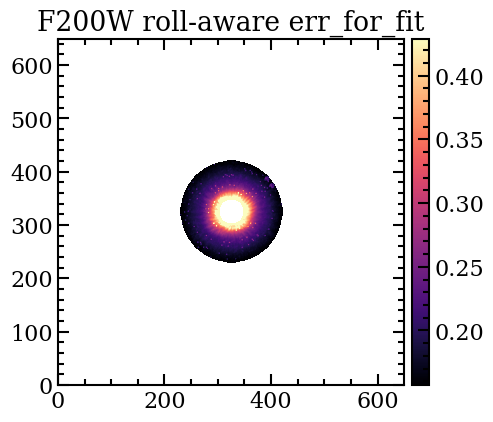

In [74]:
# Build F200W-only, roll-aware ERR map (using data_nircam_twhya/padded)
from scipy.ndimage import rotate

f200w_files = sorted(Path('data_nircam_twhya/padded').glob('jw011790*_nrca2_calints.fits'))
if len(f200w_files) == 0:
    raise FileNotFoundError('No jw011790*_nrca2_calints.fits files found in data_nircam_twhya/padded')

per_file = []
for p in f200w_files:
    with fits.open(p, memmap=False) as hdul:
        if hdul[0].header.get('FILTER', '') != 'F200W':
            continue

        err_cube = np.array(hdul['ERR'].data, dtype=float)
        dq_cube = np.array(hdul['DQ'].data, dtype=np.uint32)
        good = (dq_cube == 0) & np.isfinite(err_cube) & (err_cube > 0)
        n_good = np.sum(good, axis=0)

        # Integration-combined per-file uncertainty in detector frame
        err2d = np.sqrt(np.nansum(np.where(good, err_cube**2, np.nan), axis=0)) / np.clip(n_good, 1, None)
        err2d[n_good == 0] = np.nan

        pa_aper = float(hdul['SCI'].header.get('PA_APER', np.nan))
        roll_ref = float(hdul['SCI'].header.get('ROLL_REF', np.nan))
        per_file.append({'path': str(p), 'err2d': err2d, 'pa_aper': pa_aper, 'roll_ref': roll_ref})

if len(per_file) == 0:
    raise RuntimeError('No F200W files available after filtering.')

print('F200W files used:')
for i, item in enumerate(per_file):
    print(f"  {i+1}. {Path(item['path']).name}  PA_APER={item['pa_aper']:.6f}  ROLL_REF={item['roll_ref']:.6f}")

# Group by roll using rounded PA_APER (robust for near-identical files in same orientation)
roll_groups = {}
for item in per_file:
    key = round(item['pa_aper'], 3)
    roll_groups.setdefault(key, []).append(item)

# Within each roll group, combine files by inverse variance in detector frame
roll_maps = {}
for key, items in roll_groups.items():
    wsum = None
    for it in items:
        e = it['err2d']
        w = np.where(np.isfinite(e) & (e > 0), 1.0 / (e**2), 0.0)
        wsum = w if wsum is None else (wsum + w)
    with np.errstate(divide='ignore', invalid='ignore'):
        roll_err = np.sqrt(1.0 / wsum)
    roll_err[~np.isfinite(roll_err)] = np.nan
    roll_maps[key] = roll_err

print('\nRoll groups (PA_APER):', sorted(roll_maps.keys()))

# Rotate each roll map to a common orientation before final combination
ref_pa = sorted(roll_maps.keys())[0]
aligned_roll_maps = []
for pa, m in sorted(roll_maps.items()):
    dtheta = pa - ref_pa
    # rotate image by -dtheta so all maps align to ref_pa orientation
    m_rot = rotate(m, angle=-dtheta, reshape=False, order=1, mode='constant', cval=np.nan)
    aligned_roll_maps.append(m_rot)

# Inverse-variance combination across roll angles in common frame
wsum = None
for m in aligned_roll_maps:
    w = np.where(np.isfinite(m) & (m > 0), 1.0 / (m**2), 0.0)
    wsum = w if wsum is None else (wsum + w)
with np.errstate(divide='ignore', invalid='ignore'):
    err_f200w_rollaware = np.sqrt(1.0 / wsum)
err_f200w_rollaware[~np.isfinite(err_f200w_rollaware)] = np.nan

print('err_f200w_rollaware shape:', err_f200w_rollaware.shape)
print('median(err_f200w_rollaware)=', np.nanmedian(err_f200w_rollaware))

# Pad to model space and apply eval_mask if available
if 'rdi_reduc' in globals() and hasattr(rdi_reduc, 'im') and np.ndim(rdi_reduc.im) == 2:
    ty, tx = rdi_reduc.im.shape
    sy, sx = err_f200w_rollaware.shape
    if ty >= sy and tx >= sx:
        err_for_fit_f200w = np.full((ty, tx), np.nan, dtype=float)
        y0 = (ty - sy) // 2
        x0 = (tx - sx) // 2
        err_for_fit_f200w[y0:y0+sy, x0:x0+sx] = err_f200w_rollaware
        if 'eval_mask' in globals() and eval_mask.shape == err_for_fit_f200w.shape:
            err_for_fit_f200w = np.where(eval_mask, err_for_fit_f200w, np.nan)
        print('err_for_fit_f200w shape:', err_for_fit_f200w.shape)

        plt.figure(figsize=(5, 4.5))
        vmin, vmax = np.nanpercentile(err_for_fit_f200w, [5, 95])
        plt.imshow(err_for_fit_f200w, origin='lower', cmap='magma', vmin=vmin, vmax=vmax)
        plt.title('F200W roll-aware err_for_fit')
        plt.colorbar(fraction=0.046, pad=0.02)
        plt.show()
    else:
        print('Model image shape is smaller than ERR map; skipping embedding.')

In [98]:
best_iters

[181,
 181,
 206,
 197,
 211,
 212,
 219,
 223,
 204,
 192,
 175,
 185,
 213,
 229,
 193,
 207,
 182,
 186,
 196,
 193,
 178,
 175,
 194,
 174,
 189,
 207,
 208,
 205,
 181,
 202,
 218,
 184,
 203,
 182,
 191,
 183,
 204,
 242,
 187,
 221,
 203,
 213,
 183,
 179,
 179,
 213,
 197,
 237,
 210,
 207,
 197,
 181,
 155,
 178,
 231,
 195,
 167,
 190,
 235,
 187,
 196,
 177,
 193,
 193,
 185,
 202,
 181,
 176,
 184,
 199,
 167,
 199,
 173,
 193,
 238,
 187,
 163,
 181,
 202,
 195,
 186,
 219,
 196,
 216,
 181,
 202,
 187,
 205,
 183,
 198,
 210,
 197,
 210,
 219,
 171,
 175,
 211,
 195,
 195,
 167,
 147,
 192,
 176,
 200,
 200,
 189,
 184,
 163,
 215,
 214,
 203,
 198,
 207,
 216,
 209,
 203,
 205,
 204,
 198,
 214,
 191,
 201,
 173,
 199,
 180,
 185,
 209,
 186,
 216,
 238,
 184,
 232,
 184,
 178,
 216,
 174,
 205,
 167,
 225,
 164,
 187,
 193,
 209,
 192,
 176,
 202,
 195,
 207,
 215,
 238,
 173,
 199,
 226,
 182,
 234,
 192,
 201,
 197,
 174,
 248,
 169,
 164,
 228,
 216,
 199,
 217,
 177